In [131]:
# ---------- imports + global settings ----------

import numpy as np
import pandas as pd
import scipy
import scipy.stats
import scipy.optimize
import matplotlib.pyplot as plt
from IPython.display import display

seed = 42
rng = np.random.default_rng(seed)

Rmax = 1.0
response_sd_default = 0.18

num_x_default = 301
num_r_default = 251

n_starts_default = 12
maxiter_default = 150

n_steps_main = 5000
burn_in_main = 500

gamma_grid = np.linspace(0.0, 1.0, 9)

p_switch_main = 0.01
seed_list = [0, 1, 2, 3]

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [132]:
# ---------- default contexts ----------

contexts_mean_default = {
    0: {"name": "low-mean",  "mu": -2.0, "sigma": 1.0},
    1: {"name": "high-mean", "mu":  2.0, "sigma": 1.0},
}

contexts_var_default = {
    0: {"name": "low-var",  "mu": 0.0, "sigma": 0.7},
    1: {"name": "high-var", "mu": 0.0, "sigma": 1.8},
}

In [133]:
# ---------- environment constructors ----------

def make_mean_contexts(delta, sigma=1.0):
    half = delta / 2.0
    return {
        0: {"name": "low-mean",  "mu": -half, "sigma": sigma},
        1: {"name": "high-mean", "mu":  half, "sigma": sigma},
    }


def make_variance_contexts(sigma_low, sigma_high, mu=0.0):
    return {
        0: {"name": "low-var",  "mu": mu, "sigma": sigma_low},
        1: {"name": "high-var", "mu": mu, "sigma": sigma_high},
    }

In [134]:
# ---------- encoding and grid helpers ----------

def logistic(x, a, b, Rmax=Rmax):
    return Rmax / (1.0 + np.exp(-a * (x - b)))


def logistic_derivative(x, a, b, Rmax=Rmax):
    y = logistic(x, a, b, Rmax=Rmax)
    return a * y * (1 - y / Rmax)


def make_x_grid(contexts, n_std=5, num_x=num_x_default):
    mus = [c["mu"] for c in contexts.values()]
    sigmas = [c["sigma"] for c in contexts.values()]

    x_min = min(mu - n_std * sigma for mu, sigma in zip(mus, sigmas))
    x_max = max(mu + n_std * sigma for mu, sigma in zip(mus, sigmas))

    pad = 0.5
    return np.linspace(x_min - pad, x_max + pad, num_x)


def normal_pmf_on_grid(x_grid, mu, sigma):
    px = scipy.stats.norm.pdf(x_grid, loc=mu, scale=sigma)
    px = np.maximum(px, 1e-300)
    px /= px.sum()
    return px


def mixture_prior_pmf(contexts, x_grid, weights=None):
    keys = list(contexts.keys())

    if weights is None:
        weights = {k: 1.0 / len(keys) for k in keys}

    px = np.zeros_like(x_grid, dtype=float)

    for k in keys:
        px += weights[k] * normal_pmf_on_grid(
            x_grid,
            contexts[k]["mu"],
            contexts[k]["sigma"],
        )

    px = np.maximum(px, 1e-300)
    px /= px.sum()
    return px

In [135]:
# ---------- posterior and decoding helpers ----------

def posterior_stats_from_prior_one_neuron(
    x_grid,
    px,
    a,
    b,
    response_sd=response_sd_default,
    Rmax=Rmax,
    num_r=num_r_default,
):
    mean_responses = logistic(x_grid, a, b, Rmax=Rmax)

    r_min = mean_responses.min() - 4 * response_sd
    r_max = mean_responses.max() + 4 * response_sd
    r_grid = np.linspace(r_min, r_max, num_r)

    pr_given_x_density = scipy.stats.norm.pdf(
        r_grid[None, :],
        loc=mean_responses[:, None],
        scale=response_sd,
    )
    pr_given_x_density = np.maximum(pr_given_x_density, 1e-300)

    pr_given_x = pr_given_x_density / pr_given_x_density.sum(axis=1, keepdims=True)

    p_r = np.sum(px[:, None] * pr_given_x, axis=0)
    p_r = np.maximum(p_r, 1e-300)
    p_r /= p_r.sum()

    posterior = (pr_given_x * px[:, None]) / p_r[None, :]
    posterior = np.maximum(posterior, 1e-300)
    posterior /= posterior.sum(axis=0, keepdims=True)

    posterior_mean = np.sum(posterior * x_grid[:, None], axis=0)

    bayes_mse = np.sum(
        px[:, None] * pr_given_x * (posterior_mean[None, :] - x_grid[:, None]) ** 2
    )

    return {
        "x_grid": x_grid,
        "px": px,
        "a": a,
        "b": b,
        "mean_responses": mean_responses,
        "r_grid": r_grid,
        "pr_given_x_density": pr_given_x_density,
        "pr_given_x": pr_given_x,
        "p_r": p_r,
        "posterior": posterior,
        "posterior_mean": posterior_mean,
        "bayes_mse": bayes_mse,
    }


def posterior_stats_one_neuron(
    context,
    a,
    b,
    x_grid,
    response_sd=response_sd_default,
    Rmax=Rmax,
    num_r=num_r_default,
):
    px = normal_pmf_on_grid(x_grid, context["mu"], context["sigma"])
    return posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px,
        a=a,
        b=b,
        response_sd=response_sd,
        Rmax=Rmax,
        num_r=num_r,
    )


def decoded_mean_given_x_from_stats(stats):
    x_grid = stats["x_grid"]
    pr_given_x = stats["pr_given_x"]
    xhat_r = stats["posterior_mean"]

    decoded_mean_given_x = np.sum(pr_given_x * xhat_r[None, :], axis=1)
    bias_given_x = decoded_mean_given_x - x_grid
    local_mse_given_x = np.sum(
        pr_given_x * (xhat_r[None, :] - x_grid[:, None]) ** 2,
        axis=1,
    )

    return {
        "x_grid": x_grid,
        "decoded_mean_given_x": decoded_mean_given_x,
        "bias_given_x": bias_given_x,
        "local_mse_given_x": local_mse_given_x,
    }


def interp_from_package(r, package, field):
    vals = package[field]
    grid = package["r_grid"]
    return np.interp(r, grid, vals, left=vals[0], right=vals[-1])


def predictive_density(r, package, response_sd=response_sd_default):
    density = np.sum(
        package["px"] * scipy.stats.norm.pdf(
            r,
            loc=package["mean_responses"],
            scale=response_sd,
        )
    )
    return max(float(density), 1e-300)

In [136]:
# ---------- objectives ----------

def specialized_mse_objective(params, context, x_grid, response_sd=response_sd_default):
    a, b = params

    if a <= 0:
        return np.inf

    stats = posterior_stats_one_neuron(
        context=context,
        a=a,
        b=b,
        x_grid=x_grid,
        response_sd=response_sd,
    )
    return stats["bayes_mse"]


def static_mse_objective(params, contexts, x_grid, response_sd=response_sd_default):
    a, b = params

    if a <= 0:
        return np.inf

    px_mix = mixture_prior_pmf(contexts, x_grid)
    stats = posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px_mix,
        a=a,
        b=b,
        response_sd=response_sd,
    )
    return stats["bayes_mse"]


def context_inference_metrics(
    params,
    contexts,
    x_grid,
    response_sd=response_sd_default,
    context_weights=None,
):
    a, b = params

    if a <= 0:
        return {
            "conditional_entropy": np.inf,
            "map_accuracy": -np.inf,
        }

    mean_responses = logistic(x_grid, a, b, Rmax=Rmax)

    r_min = mean_responses.min() - 4 * response_sd
    r_max = mean_responses.max() + 4 * response_sd
    r_grid = np.linspace(r_min, r_max, num_r_default)

    pr_given_x_density = scipy.stats.norm.pdf(
        r_grid[None, :],
        loc=mean_responses[:, None],
        scale=response_sd,
    )
    pr_given_x_density = np.maximum(pr_given_x_density, 1e-300)
    pr_given_x = pr_given_x_density / pr_given_x_density.sum(axis=1, keepdims=True)

    keys = list(contexts.keys())

    if context_weights is None:
        p_context = {k: 1.0 / len(keys) for k in keys}
    else:
        p_context = {k: float(context_weights[k]) for k in keys}
        z = sum(p_context.values())
        p_context = {k: p_context[k] / z for k in keys}

    p_r_given_context = {}
    for k, context in contexts.items():
        px = normal_pmf_on_grid(x_grid, context["mu"], context["sigma"])
        p_r = np.sum(px[:, None] * pr_given_x, axis=0)
        p_r = np.maximum(p_r, 1e-300)
        p_r /= p_r.sum()
        p_r_given_context[k] = p_r

    p_r_total = np.zeros_like(r_grid, dtype=float)
    for k in keys:
        p_r_total += p_context[k] * p_r_given_context[k]
    p_r_total = np.maximum(p_r_total, 1e-300)
    p_r_total /= p_r_total.sum()

    posterior_mat = []
    conditional_entropy = 0.0

    for k in keys:
        p_c_given_r = (p_context[k] * p_r_given_context[k]) / p_r_total
        p_c_given_r = np.maximum(p_c_given_r, 1e-300)
        posterior_mat.append(p_c_given_r)

        conditional_entropy += -p_context[k] * np.sum(
            p_r_given_context[k] * np.log(p_c_given_r)
        )

    posterior_mat = np.vstack(posterior_mat)
    map_accuracy = float(np.sum(p_r_total * np.max(posterior_mat, axis=0)))

    return {
        "conditional_entropy": float(conditional_entropy),
        "map_accuracy": map_accuracy,
    }


def context_accuracy_objective(
    params,
    contexts,
    x_grid,
    response_sd=response_sd_default,
    context_weights=None,
):
    metrics = context_inference_metrics(
        params=params,
        contexts=contexts,
        x_grid=x_grid,
        response_sd=response_sd,
        context_weights=context_weights,
    )
    return -metrics["map_accuracy"]

In [137]:
# ---------- optimizer helper ----------

def fit_multistart(
    obj,
    bounds,
    n_starts=n_starts_default,
    seed=0,
    maxiter=maxiter_default,
):
    rng_local = np.random.default_rng(seed)
    best_res = None

    for _ in range(n_starts):
        x0 = np.array([rng_local.uniform(lo, hi) for lo, hi in bounds])

        res = scipy.optimize.minimize(
            obj,
            x0=x0,
            method="Powell",
            bounds=bounds,
            options={
                "maxiter": maxiter,
                "xtol": 1e-3,
                "ftol": 1e-4,
                "disp": False,
            },
        )

        if (best_res is None) or (res.fun < best_res.fun):
            best_res = res

    return best_res

In [138]:
# ---------- fit codebook for arbitrary contexts ----------

def fit_codebook_for_contexts(
    contexts,
    seed_offset=0,
    response_sd=response_sd_default,
):
    x_grid = make_x_grid(contexts)
    bounds = [(0.25, 8.0), (x_grid.min(), x_grid.max())]

    fit_local = {}
    local_params = {}

    keys = list(contexts.keys())
    for idx, k in enumerate(keys):
        res = fit_multistart(
            lambda p, ck=k: specialized_mse_objective(
                p, contexts[ck], x_grid, response_sd=response_sd
            ),
            bounds=bounds,
            seed=1000 + seed_offset + idx,
        )
        fit_local[k] = res
        local_params[k] = res.x

    fit_static = fit_multistart(
        lambda p: static_mse_objective(p, contexts, x_grid, response_sd=response_sd),
        bounds=bounds,
        seed=1100 + seed_offset,
    )

    fit_infer_acc = fit_multistart(
        lambda p: context_accuracy_objective(
            p, contexts, x_grid, response_sd=response_sd
        ),
        bounds=bounds,
        seed=1200 + seed_offset,
    )

    static_params = fit_static.x
    infer_acc_params = fit_infer_acc.x

    nonlocal_target_params = {
        0: np.array(local_params[1], dtype=float),
        1: np.array(local_params[0], dtype=float),
    }

    return {
        "contexts": contexts,
        "x_grid": x_grid,
        "bounds": bounds,
        "local_params": local_params,
        "static_params": static_params,
        "infer_acc_params": infer_acc_params,
        "nonlocal_target_params": nonlocal_target_params,
        "fit_local": fit_local,
        "fit_static": fit_static,
        "fit_infer_acc": fit_infer_acc,
    }

In [139]:
# ---------- adaptive family helpers ----------

def blend_params(local_params, target_params, gamma):
    a_local, b_local = local_params
    a_target, b_target = target_params
    return np.array([
        (1 - gamma) * a_local + gamma * a_target,
        (1 - gamma) * b_local + gamma * b_target,
    ])


def target_for_context(target_params, context_key):
    if isinstance(target_params, dict):
        return np.asarray(target_params[context_key], dtype=float)
    return np.asarray(target_params, dtype=float)


def make_family_params(local_params, target_params, gamma):
    out = {}
    for k in local_params:
        out[k] = blend_params(
            np.asarray(local_params[k], dtype=float),
            target_for_context(target_params, k),
            gamma,
        )
    return out


def make_context_package(context, params, x_grid, response_sd=response_sd_default):
    a, b = params
    stats = posterior_stats_one_neuron(
        context=context,
        a=a,
        b=b,
        x_grid=x_grid,
        response_sd=response_sd,
    )
    return stats


def make_family_packages(contexts, family_params, x_grid, response_sd=response_sd_default):
    packages = {}
    for k in contexts:
        packages[k] = make_context_package(
            contexts[k],
            family_params[k],
            x_grid,
            response_sd=response_sd,
        )
    return packages

In [140]:
# ---------- online simulation helpers ----------

def sample_context_sequence(n_steps, p_switch, seed=0):
    rng_local = np.random.default_rng(seed)
    c = np.zeros(n_steps, dtype=int)
    c[0] = rng_local.integers(0, 2)

    for t in range(1, n_steps):
        if rng_local.random() < p_switch:
            c[t] = 1 - c[t - 1]
        else:
            c[t] = c[t - 1]
    return c

def make_likelihood_package(
    true_context,
    used_params,
    x_grid,
    response_sd=response_sd_default,
):
    a, b = used_params
    px = normal_pmf_on_grid(x_grid, true_context["mu"], true_context["sigma"])
    return posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px,
        a=a,
        b=b,
        response_sd=response_sd,
    )

def transition_matrix_from_switch_prob(p_switch):
    return np.array([
        [1 - p_switch, p_switch],
        [p_switch, 1 - p_switch],
    ])


def choose_context_with_hysteresis(prob_context_1, prev_estimated_context, tau_low, tau_high):
    """
    Hysteresis switching rule using P(context=1).

    If currently in context 0:
        switch to 1 only if P(1) > tau_high
    If currently in context 1:
        switch to 0 only if P(1) < tau_low
    Otherwise keep previous estimate.

    Requires tau_low <= tau_high.
    """
    if tau_low > tau_high:
        raise ValueError(f"Need tau_low <= tau_high, got tau_low={tau_low}, tau_high={tau_high}")

    if prev_estimated_context == 0:
        if prob_context_1 > tau_high:
            return 1
        return 0
    else:
        if prob_context_1 < tau_low:
            return 0
        return 1


def run_strategy_one_neuron(
    strategy_name,
    contexts,
    x_grid,
    local_params,
    static_params,
    target_params,
    gamma=0.0,
    p_switch=p_switch_main,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
    seed=0,
    adaptation_mode="instant",      # "instant", "hysteresis", "refractory", "both"
    tau_low=0.35,                   # hysteresis lower threshold on P(context=1)
    tau_high=0.65,                  # hysteresis upper threshold on P(context=1)
    refractory_length=0,            # lockout length after a switch
):
    rng_local = np.random.default_rng(seed)
    transition_matrix = transition_matrix_from_switch_prob(p_switch)
    true_contexts = sample_context_sequence(n_steps, p_switch, seed=seed + 100)

    static_package = posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=mixture_prior_pmf(contexts, x_grid),
        a=static_params[0],
        b=static_params[1],
        response_sd=response_sd,
    )

    family_params = make_family_params(local_params, target_params, gamma)
    family_packages = make_family_packages(
        contexts, family_params, x_grid, response_sd=response_sd
    )
    local_packages = make_family_packages(
        contexts, local_params, x_grid, response_sd=response_sd
    )

    # likelihood packages indexed by:
    #   used encoder context -> hypothesized true context
    context_likelihood_packages = {}
    for used_k in contexts:
        context_likelihood_packages[used_k] = {}
        used_params_k = family_params[used_k]

        for true_k in contexts:
            context_likelihood_packages[used_k][true_k] = make_likelihood_package(
                true_context=contexts[true_k],
                used_params=used_params_k,
                x_grid=x_grid,
                response_sd=response_sd,
            )

    rows = []
    belief = np.array([0.5, 0.5], dtype=float)

    prev_estimated_context = 0
    refractory_timer = 0

    for t in range(n_steps):
        true_c = int(true_contexts[t])
        context = contexts[true_c]
        x_t = rng_local.normal(loc=context["mu"], scale=context["sigma"])

        if strategy_name == "static":
            used_params = np.asarray(static_params, dtype=float)
            used_package = static_package
            estimated_context = np.nan
            desired_context = np.nan
            desired_params = np.asarray(static_params, dtype=float)
            mismatch = False
            switch_locked = False

        elif strategy_name == "oracle":
            used_params = np.asarray(local_params[true_c], dtype=float)
            used_package = local_packages[true_c]
            estimated_context = true_c
            desired_context = true_c
            desired_params = np.asarray(local_params[true_c], dtype=float)
            mismatch = False
            switch_locked = False

        elif strategy_name == "adaptive":
            belief_pred = transition_matrix.T @ belief
            belief_pred /= belief_pred.sum()

            p_context_1 = float(belief_pred[1])

            uses_refractory = adaptation_mode in ["refractory", "both"]
            uses_hysteresis = adaptation_mode in ["hysteresis", "both"]

            switch_locked = uses_refractory and (refractory_timer > 0)

            if switch_locked:
                estimated_context = prev_estimated_context
                refractory_timer -= 1
            else:
                if uses_hysteresis:
                    estimated_context = choose_context_with_hysteresis(
                        prob_context_1=p_context_1,
                        prev_estimated_context=prev_estimated_context,
                        tau_low=tau_low,
                        tau_high=tau_high,
                    )
                else:
                    estimated_context = int(np.argmax(belief_pred))

                if uses_refractory:
                    if estimated_context != prev_estimated_context:
                        refractory_timer = refractory_length
                    else:
                        refractory_timer = 0

            desired_context = estimated_context
            desired_params = np.asarray(family_params[desired_context], dtype=float)

            used_params = desired_params.copy()
            used_package = family_packages[desired_context]
            mismatch = (estimated_context != true_c)

            prev_estimated_context = estimated_context

        else:
            raise ValueError(f"Unknown strategy_name: {strategy_name}")

        mean_r = logistic(x_t, used_params[0], used_params[1], Rmax=Rmax)
        r_t = rng_local.normal(loc=mean_r, scale=response_sd)

        xhat_t = interp_from_package(r_t, used_package, "posterior_mean")
        sq_error = (x_t - xhat_t) ** 2

        if strategy_name == "adaptive":
            used_encoder_context = desired_context

            likelihoods = np.array([
                predictive_density(
                    r_t,
                    context_likelihood_packages[used_encoder_context][0],
                    response_sd=response_sd,
                ),
                predictive_density(
                    r_t,
                    context_likelihood_packages[used_encoder_context][1],
                    response_sd=response_sd,
                ),
            ])

            belief = likelihoods * belief_pred
            belief_sum = belief.sum()
            if belief_sum <= 0:
                belief = np.array([0.5, 0.5], dtype=float)
            else:
                belief /= belief_sum

        rows.append({
            "t": t,
            "true_context": true_c,
            "estimated_context": estimated_context,
            "desired_context": desired_context,
            "x": x_t,
            "r": r_t,
            "xhat": xhat_t,
            "sq_error": sq_error,
            "mismatch": mismatch,
            "used_a": used_params[0],
            "used_b": used_params[1],
            "desired_a": desired_params[0] if strategy_name != "static" else np.nan,
            "desired_b": desired_params[1] if strategy_name != "static" else np.nan,
            "belief_context_1": belief[1] if strategy_name == "adaptive" else np.nan,
            "refractory_timer": refractory_timer if strategy_name == "adaptive" else np.nan,
            "switch_locked": switch_locked if strategy_name == "adaptive" else np.nan,
        })

    df = pd.DataFrame(rows)
    df_eval = df.iloc[burn_in:].copy()

    out = {
        "df": df,
        "global_mse": df_eval["sq_error"].mean(),
    }

    if strategy_name == "adaptive":
        mismatch_mask = df_eval["mismatch"].astype(bool).values
        matched = df_eval.loc[~df_eval["mismatch"], "sq_error"].values
        mismatched = df_eval.loc[df_eval["mismatch"], "sq_error"].values

        mismatch_lengths = []
        run_len = 0
        for m in mismatch_mask:
            if m:
                run_len += 1
            elif run_len > 0:
                mismatch_lengths.append(run_len)
                run_len = 0
        if run_len > 0:
            mismatch_lengths.append(run_len)

        out["mismatch_rate"] = df_eval["mismatch"].mean()
        out["matched_mse"] = matched.mean() if len(matched) > 0 else np.nan
        out["mismatched_mse"] = mismatched.mean() if len(mismatched) > 0 else np.nan
        out["mean_mismatch_duration"] = (
            np.mean(mismatch_lengths) if len(mismatch_lengths) > 0 else 0.0
        )

    return out

In [141]:
# ---------- sweep helpers ----------

def sweep_gamma_one_neuron(
    contexts,
    x_grid,
    local_params,
    static_params,
    target_params,
    family_name,
    gamma_grid,
    p_switch=p_switch_main,
    seeds=seed_list,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
    adaptation_mode="instant",
    tau_low=0.35,
    tau_high=0.65,
    refractory_length=0,
):
    rows = []

    for gamma in gamma_grid:
        for seed_now in seeds:
            out = run_strategy_one_neuron(
                strategy_name="adaptive",
                contexts=contexts,
                x_grid=x_grid,
                local_params=local_params,
                static_params=static_params,
                target_params=target_params,
                gamma=gamma,
                p_switch=p_switch,
                n_steps=n_steps,
                burn_in=burn_in,
                response_sd=response_sd,
                seed=seed_now,
                adaptation_mode=adaptation_mode,
                tau_low=tau_low,
                tau_high=tau_high,
                refractory_length=refractory_length,
            )

            rows.append({
                "family": family_name,
                "gamma": gamma,
                "seed": seed_now,
                "global_mse": out["global_mse"],
                "mismatch_rate": out["mismatch_rate"],
                "matched_mse": out["matched_mse"],
                "mismatched_mse": out["mismatched_mse"],
                "mean_mismatch_duration": out["mean_mismatch_duration"],
            })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby(["family", "gamma"], as_index=False)
        .agg(
            global_mse_mean=("global_mse", "mean"),
            global_mse_std=("global_mse", "std"),
            mismatch_rate_mean=("mismatch_rate", "mean"),
            matched_mse_mean=("matched_mse", "mean"),
            mismatched_mse_mean=("mismatched_mse", "mean"),
            mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
        )
        .sort_values(["family", "gamma"])
        .reset_index(drop=True)
    )

    return df, summary


def evaluate_strategy_set_one_neuron(
    contexts,
    x_grid,
    local_params,
    static_params,
    infer_acc_params,
    best_gamma_static,
    best_gamma_infer_acc,
    nonlocal_params,
    best_gamma_nonlocal,
    p_switch=p_switch_main,
    seeds=seed_list,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
    adaptation_mode="instant",
    tau_low=0.35,
    tau_high=0.65,
    refractory_length=0,
):
    rows = []

    strategy_specs = [
        ("static", None, None),
        ("oracle", None, None),
        ("adaptive_local", static_params, 0.0),
        ("adaptive_best_static", static_params, best_gamma_static),
        ("adaptive_best_infer_accuracy", infer_acc_params, best_gamma_infer_acc),
        ("adaptive_best_nonlocal", nonlocal_params, best_gamma_nonlocal),
    ]

    for seed_now in seeds:
        for label, target_params, gamma in strategy_specs:
            if label == "static":
                out = run_strategy_one_neuron(
                    strategy_name="static",
                    contexts=contexts,
                    x_grid=x_grid,
                    local_params=local_params,
                    static_params=static_params,
                    target_params=static_params,
                    gamma=0.0,
                    p_switch=p_switch,
                    n_steps=n_steps,
                    burn_in=burn_in,
                    response_sd=response_sd,
                    seed=seed_now,
                )
            elif label == "oracle":
                out = run_strategy_one_neuron(
                    strategy_name="oracle",
                    contexts=contexts,
                    x_grid=x_grid,
                    local_params=local_params,
                    static_params=static_params,
                    target_params=static_params,
                    gamma=0.0,
                    p_switch=p_switch,
                    n_steps=n_steps,
                    burn_in=burn_in,
                    response_sd=response_sd,
                    seed=seed_now,
                )
            else:
                out = run_strategy_one_neuron(
                    strategy_name="adaptive",
                    contexts=contexts,
                    x_grid=x_grid,
                    local_params=local_params,
                    static_params=static_params,
                    target_params=target_params,
                    gamma=gamma,
                    p_switch=p_switch,
                    n_steps=n_steps,
                    burn_in=burn_in,
                    response_sd=response_sd,
                    seed=seed_now,
                    adaptation_mode=adaptation_mode,
                    tau_low=tau_low,
                    tau_high=tau_high,
                    refractory_length=refractory_length,
                )

            rows.append({
                "strategy": label,
                "seed": seed_now,
                "global_mse": out["global_mse"],
                "mismatch_rate": out.get("mismatch_rate", np.nan),
                "matched_mse": out.get("matched_mse", np.nan),
                "mismatched_mse": out.get("mismatched_mse", np.nan),
                "mean_mismatch_duration": out.get("mean_mismatch_duration", np.nan),
            })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby("strategy", as_index=False)
        .agg(
            global_mse_mean=("global_mse", "mean"),
            global_mse_std=("global_mse", "std"),
            mismatch_rate_mean=("mismatch_rate", "mean"),
            matched_mse_mean=("matched_mse", "mean"),
            mismatched_mse_mean=("mismatched_mse", "mean"),
            mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
        )
        .sort_values("global_mse_mean")
        .reset_index(drop=True)
    )

    return df, summary


def sweep_switch_prob_one_neuron(
    contexts,
    x_grid,
    local_params,
    static_params,
    infer_acc_params,
    best_gamma_static,
    best_gamma_infer_acc,
    nonlocal_params,
    best_gamma_nonlocal,
    p_switch_grid,
    seeds=seed_list,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
    adaptation_mode="instant",
    tau_low=0.35,
    tau_high=0.65,
    refractory_length=0,
):
    rows = []

    strategy_specs = [
        ("static", None, None),
        ("oracle", None, None),
        ("adaptive_local", static_params, 0.0),
        ("adaptive_best_static", static_params, best_gamma_static),
        ("adaptive_best_infer_accuracy", infer_acc_params, best_gamma_infer_acc),
        ("adaptive_best_nonlocal", nonlocal_params, best_gamma_nonlocal),
    ]

    for p_switch in p_switch_grid:
        for seed_now in seeds:
            for label, target_params, gamma in strategy_specs:
                if label == "static":
                    out = run_strategy_one_neuron(
                        strategy_name="static",
                        contexts=contexts,
                        x_grid=x_grid,
                        local_params=local_params,
                        static_params=static_params,
                        target_params=static_params,
                        gamma=0.0,
                        p_switch=p_switch,
                        n_steps=n_steps,
                        burn_in=burn_in,
                        response_sd=response_sd,
                        seed=seed_now,
                    )
                elif label == "oracle":
                    out = run_strategy_one_neuron(
                        strategy_name="oracle",
                        contexts=contexts,
                        x_grid=x_grid,
                        local_params=local_params,
                        static_params=static_params,
                        target_params=static_params,
                        gamma=0.0,
                        p_switch=p_switch,
                        n_steps=n_steps,
                        burn_in=burn_in,
                        response_sd=response_sd,
                        seed=seed_now,
                    )
                else:
                    out = run_strategy_one_neuron(
                        strategy_name="adaptive",
                        contexts=contexts,
                        x_grid=x_grid,
                        local_params=local_params,
                        static_params=static_params,
                        target_params=target_params,
                        gamma=gamma,
                        p_switch=p_switch,
                        n_steps=n_steps,
                        burn_in=burn_in,
                        response_sd=response_sd,
                        seed=seed_now,
                        adaptation_mode=adaptation_mode,
                        tau_low=tau_low,
                        tau_high=tau_high,
                        refractory_length=refractory_length,
                    )

                rows.append({
                    "p_switch": p_switch,
                    "strategy": label,
                    "seed": seed_now,
                    "global_mse": out["global_mse"],
                    "mismatch_rate": out.get("mismatch_rate", np.nan),
                    "matched_mse": out.get("matched_mse", np.nan),
                    "mismatched_mse": out.get("mismatched_mse", np.nan),
                    "mean_mismatch_duration": out.get("mean_mismatch_duration", np.nan),
                })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby(["p_switch", "strategy"], as_index=False)
        .agg(
            global_mse_mean=("global_mse", "mean"),
            global_mse_std=("global_mse", "std"),
            mismatch_rate_mean=("mismatch_rate", "mean"),
            matched_mse_mean=("matched_mse", "mean"),
            mismatched_mse_mean=("mismatched_mse", "mean"),
            mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
        )
        .sort_values(["p_switch", "strategy"])
        .reset_index(drop=True)
    )

    return df, summary

In [142]:
# ---------- default codebook fits ----------

fit_mean = fit_codebook_for_contexts(contexts_mean_default, seed_offset=0)
fit_var = fit_codebook_for_contexts(contexts_var_default, seed_offset=500)

x_grid_mean = fit_mean["x_grid"]
local_params_mean = fit_mean["local_params"]
static_params_mean = fit_mean["static_params"]
infer_acc_params_mean = fit_mean["infer_acc_params"]
nonlocal_target_params_mean = fit_mean["nonlocal_target_params"]

x_grid_var = fit_var["x_grid"]
local_params_var = fit_var["local_params"]
static_params_var = fit_var["static_params"]
infer_acc_params_var = fit_var["infer_acc_params"]
nonlocal_target_params_var = fit_var["nonlocal_target_params"]

print("mean-switching")
print("local_params:", local_params_mean)
print("static_params:", static_params_mean)
print("infer_acc_params:", infer_acc_params_mean)
print("nonlocal_target_params:", nonlocal_target_params_mean)

print("\nvariance-switching")
print("local_params:", local_params_var)
print("static_params:", static_params_var)
print("infer_acc_params:", infer_acc_params_var)
print("nonlocal_target_params:", nonlocal_target_params_var)

mean-switching
local_params: {0: array([ 2.79465863, -1.99998365]), 1: array([2.79468967, 2.00000014])}
static_params: [1.53077275e+00 2.22077206e-16]
infer_acc_params: [ 7.99999865e+00 -2.78117821e-03]
nonlocal_target_params: {0: array([2.79468967, 2.00000014]), 1: array([ 2.79465863, -1.99998365])}

variance-switching
local_params: {0: array([3.99244523e+00, 6.30609024e-14]), 1: array([1.55261971e+00, 4.44469702e-16])}
static_params: [1.81639393e+00 8.88219258e-16]
infer_acc_params: [1.53959386e+00 3.55270595e-15]
nonlocal_target_params: {0: array([1.55261971e+00, 4.44469702e-16]), 1: array([3.99244523e+00, 6.30609024e-14])}


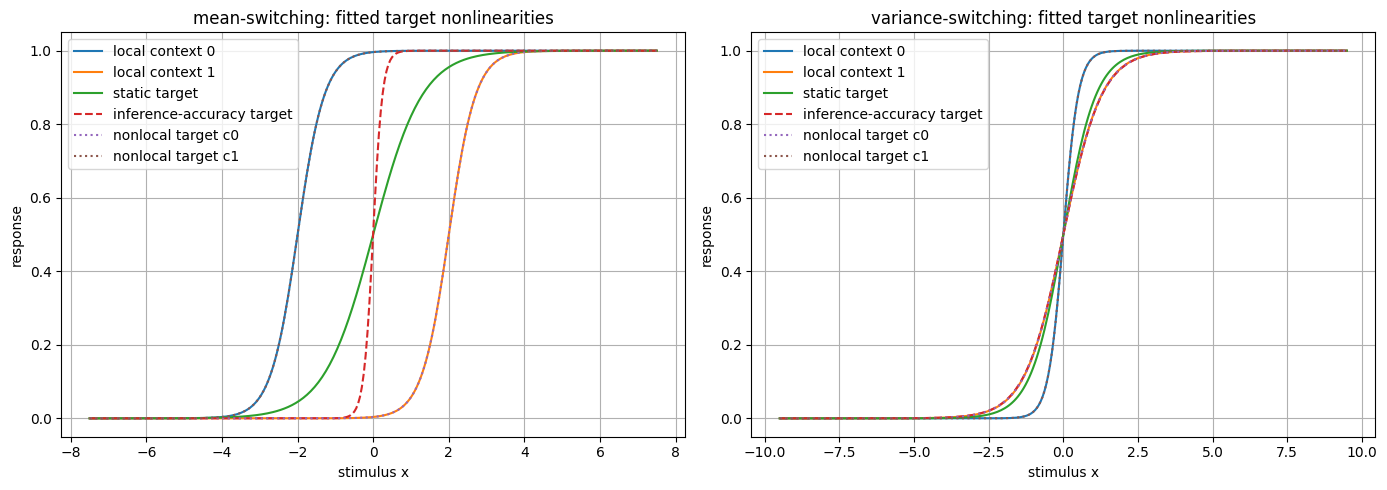

In [ ]:
# ---------- fitted nonlinearities ----------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, local_params_mean[0][0], local_params_mean[0][1]),
    label="local context 0",
)
axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, local_params_mean[1][0], local_params_mean[1][1]),
    label="local context 1",
)
axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, static_params_mean[0], static_params_mean[1]),
    label="static target",
)
axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, infer_acc_params_mean[0], infer_acc_params_mean[1]),
    linestyle="--",
    label="inference-accuracy target",
)
axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, nonlocal_target_params_mean[0][0], nonlocal_target_params_mean[0][1]),
    linestyle=":",
    label="nonlocal target c0",
)
axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, nonlocal_target_params_mean[1][0], nonlocal_target_params_mean[1][1]),
    linestyle=":",
    label="nonlocal target c1",
)
axes[0].set_title("mean-switching: fitted target nonlinearities")
axes[0].set_xlabel("stimulus x")
axes[0].set_ylabel("response")
axes[0].legend()

axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, local_params_var[0][0], local_params_var[0][1]),
    label="local context 0",
)
axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, local_params_var[1][0], local_params_var[1][1]),
    label="local context 1",
)
axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, static_params_var[0], static_params_var[1]),
    label="static target",
)
axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, infer_acc_params_var[0], infer_acc_params_var[1]),
    linestyle="--",
    label="inference-accuracy target",
)
axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, nonlocal_target_params_var[0][0], nonlocal_target_params_var[0][1]),
    linestyle=":",
    label="nonlocal target c0",
)
axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, nonlocal_target_params_var[1][0], nonlocal_target_params_var[1][1]),
    linestyle=":",
    label="nonlocal target c1",
)
axes[1].set_title("variance-switching: fitted target nonlinearities")
axes[1].set_xlabel("stimulus x")
axes[1].set_ylabel("response")
axes[1].legend()

plt.tight_layout()
plt.show()

In [144]:
# ---------- gamma sweeps in default environments ----------

gamma_mean_static_df, gamma_summary_mean_static = sweep_gamma_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    family_name="toward static",
    gamma_grid=gamma_grid,
)

gamma_mean_infer_acc_df, gamma_summary_mean_infer_acc = sweep_gamma_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=infer_acc_params_mean,
    family_name="toward accuracy",
    gamma_grid=gamma_grid,
)

gamma_mean_nonlocal_df, gamma_summary_mean_nonlocal = sweep_gamma_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=nonlocal_target_params_mean,
    family_name="toward nonlocal",
    gamma_grid=gamma_grid,
)

gamma_var_static_df, gamma_summary_var_static = sweep_gamma_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    family_name="toward static",
    gamma_grid=gamma_grid,
)

gamma_var_infer_acc_df, gamma_summary_var_infer_acc = sweep_gamma_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=infer_acc_params_var,
    family_name="toward accuracy",
    gamma_grid=gamma_grid,
)

gamma_var_nonlocal_df, gamma_summary_var_nonlocal = sweep_gamma_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=nonlocal_target_params_var,
    family_name="toward nonlocal",
    gamma_grid=gamma_grid,
)

In [145]:
# ---------- best gamma extraction ----------

def best_gamma_from_summary(summary_df):
    row = summary_df.sort_values("global_mse_mean").iloc[0]
    return float(row["gamma"]), float(row["global_mse_mean"])

best_gamma_mean_static, best_mse_mean_static = best_gamma_from_summary(gamma_summary_mean_static)
best_gamma_mean_infer_acc, best_mse_mean_infer_acc = best_gamma_from_summary(gamma_summary_mean_infer_acc)
best_gamma_mean_nonlocal, best_mse_mean_nonlocal = best_gamma_from_summary(gamma_summary_mean_nonlocal)

best_gamma_var_static, best_mse_var_static = best_gamma_from_summary(gamma_summary_var_static)
best_gamma_var_infer_acc, best_mse_var_infer_acc = best_gamma_from_summary(gamma_summary_var_infer_acc)
best_gamma_var_nonlocal, best_mse_var_nonlocal = best_gamma_from_summary(gamma_summary_var_nonlocal)

print("best mean gammas:")
print("static   :", best_gamma_mean_static, best_mse_mean_static)
print("accuracy :", best_gamma_mean_infer_acc, best_mse_mean_infer_acc)
print("nonlocal :", best_gamma_mean_nonlocal, best_mse_mean_nonlocal)

print("\nbest variance gammas:")
print("static   :", best_gamma_var_static, best_mse_var_static)
print("accuracy :", best_gamma_var_infer_acc, best_mse_var_infer_acc)
print("nonlocal :", best_gamma_var_nonlocal, best_mse_var_nonlocal)

best mean gammas:
static   : 0.375 0.5960206938052945
accuracy : 0.25 0.6777682191903185
nonlocal : 0.125 0.6238166146072738

best variance gammas:
static   : 0.625 0.6311201207792133
accuracy : 0.75 0.6286675071729747
nonlocal : 0.0 0.651978709662552


In [146]:
# ---------- hysteresis + refractory settings ----------

# refractory:
# number of time steps after a switch during which another switch is forbidden
refractory_default = 5
refractory_grid = [0, 2, 5, 10, 20]

# hysteresis:
# switch to context 1 only if P(1) > tau_high
# switch to context 0 only if P(1) < tau_low
tau_low_default = 0.35
tau_high_default = 0.65

hysteresis_grid = [
    (0.50, 0.50),   # effectively no hysteresis / plain threshold at 0.5
    (0.40, 0.60),
    (0.35, 0.65),
    (0.30, 0.70),
]

# combined sweep grid for "both"
combined_grid = [
    (0.50, 0.50, 0),
    (0.40, 0.60, 2),
    (0.35, 0.65, 5),
    (0.30, 0.70, 10),
]

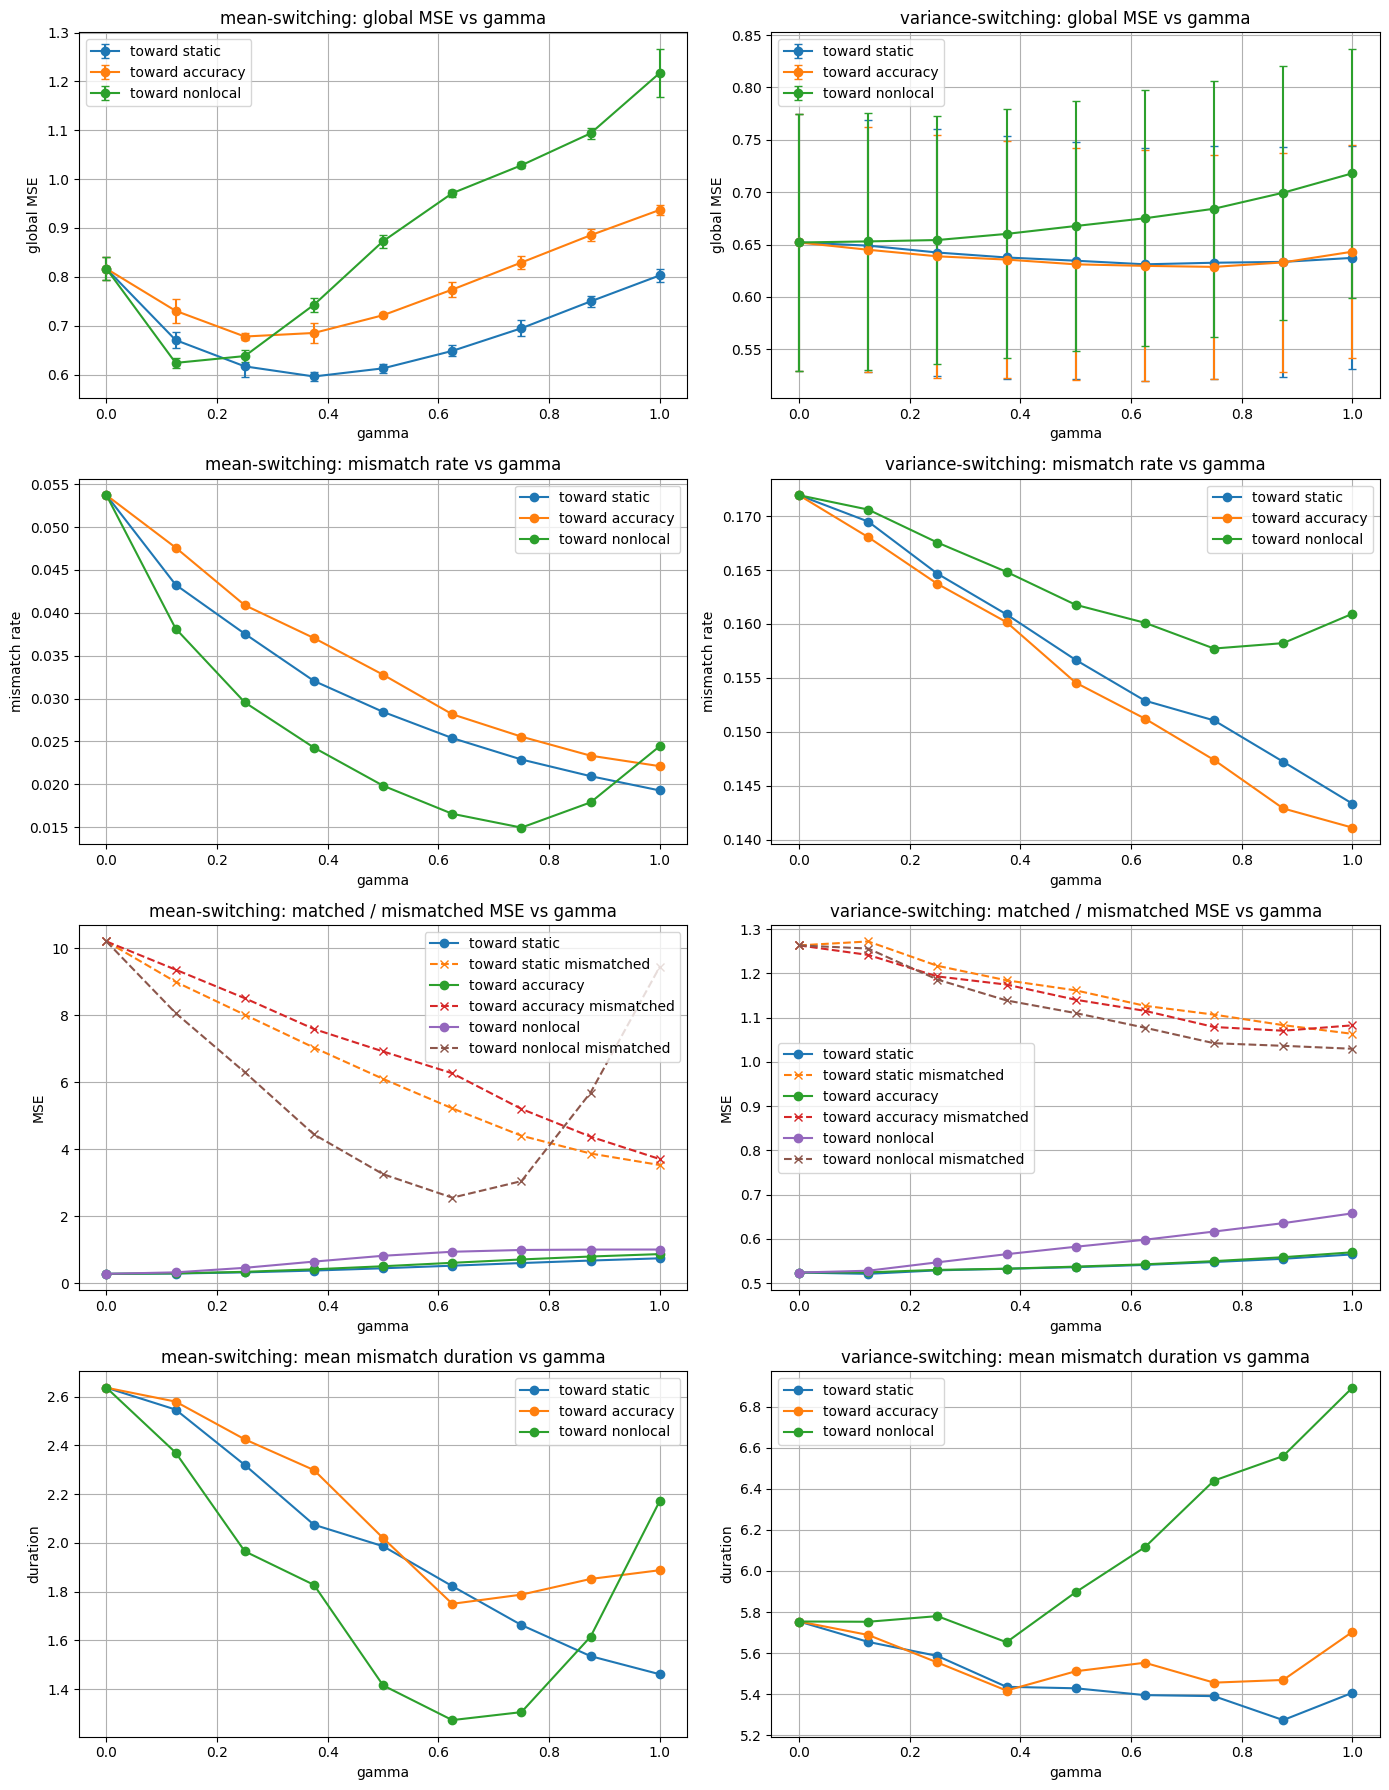

In [ ]:
# ---------- gamma sweep plots ----------

plot_specs = [
    ("toward static",   gamma_summary_mean_static,    gamma_summary_var_static),
    ("toward accuracy", gamma_summary_mean_infer_acc, gamma_summary_var_infer_acc),
    ("toward nonlocal", gamma_summary_mean_nonlocal,  gamma_summary_var_nonlocal),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for label, mean_summary, _ in plot_specs:
    axes[0, 0].errorbar(
        mean_summary["gamma"],
        mean_summary["global_mse_mean"],
        yerr=mean_summary["global_mse_std"],
        marker="o",
        capsize=3,
        label=label,
    )
axes[0, 0].set_title("mean-switching: global MSE vs gamma")
axes[0, 0].set_xlabel("gamma")
axes[0, 0].set_ylabel("global MSE")
axes[0, 0].legend()

for label, _, var_summary in plot_specs:
    axes[0, 1].errorbar(
        var_summary["gamma"],
        var_summary["global_mse_mean"],
        yerr=var_summary["global_mse_std"],
        marker="o",
        capsize=3,
        label=label,
    )
axes[0, 1].set_title("variance-switching: global MSE vs gamma")
axes[0, 1].set_xlabel("gamma")
axes[0, 1].set_ylabel("global MSE")
axes[0, 1].legend()

for label, mean_summary, _ in plot_specs:
    axes[1, 0].plot(mean_summary["gamma"], mean_summary["mismatch_rate_mean"], marker="o", label=label)
axes[1, 0].set_title("mean-switching: mismatch rate vs gamma")
axes[1, 0].set_xlabel("gamma")
axes[1, 0].set_ylabel("mismatch rate")
axes[1, 0].legend()

for label, _, var_summary in plot_specs:
    axes[1, 1].plot(var_summary["gamma"], var_summary["mismatch_rate_mean"], marker="o", label=label)
axes[1, 1].set_title("variance-switching: mismatch rate vs gamma")
axes[1, 1].set_xlabel("gamma")
axes[1, 1].set_ylabel("mismatch rate")
axes[1, 1].legend()

for label, mean_summary, _ in plot_specs:
    axes[2, 0].plot(mean_summary["gamma"], mean_summary["matched_mse_mean"], marker="o", label=label)
    axes[2, 0].plot(mean_summary["gamma"], mean_summary["mismatched_mse_mean"], marker="x", linestyle="--", label=f"{label} mismatched")
axes[2, 0].set_title("mean-switching: matched / mismatched MSE vs gamma")
axes[2, 0].set_xlabel("gamma")
axes[2, 0].set_ylabel("MSE")
axes[2, 0].legend()

for label, _, var_summary in plot_specs:
    axes[2, 1].plot(var_summary["gamma"], var_summary["matched_mse_mean"], marker="o", label=label)
    axes[2, 1].plot(var_summary["gamma"], var_summary["mismatched_mse_mean"], marker="x", linestyle="--", label=f"{label} mismatched")
axes[2, 1].set_title("variance-switching: matched / mismatched MSE vs gamma")
axes[2, 1].set_xlabel("gamma")
axes[2, 1].set_ylabel("MSE")
axes[2, 1].legend()

for label, mean_summary, _ in plot_specs:
    axes[3, 0].plot(mean_summary["gamma"], mean_summary["mean_mismatch_duration_mean"], marker="o", label=label)
axes[3, 0].set_title("mean-switching: mean mismatch duration vs gamma")
axes[3, 0].set_xlabel("gamma")
axes[3, 0].set_ylabel("duration")
axes[3, 0].legend()

for label, _, var_summary in plot_specs:
    axes[3, 1].plot(var_summary["gamma"], var_summary["mean_mismatch_duration_mean"], marker="o", label=label)
axes[3, 1].set_title("variance-switching: mean mismatch duration vs gamma")
axes[3, 1].set_xlabel("gamma")
axes[3, 1].set_ylabel("duration")
axes[3, 1].legend()

plt.tight_layout()
plt.show()

In [148]:
# ---------- main strategy comparison in default environments ----------

_, strategy_summary_mean = evaluate_strategy_set_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    infer_acc_params=infer_acc_params_mean,
    best_gamma_static=best_gamma_mean_static,
    best_gamma_infer_acc=best_gamma_mean_infer_acc,
    nonlocal_params=nonlocal_target_params_mean,
    best_gamma_nonlocal=best_gamma_mean_nonlocal,
)

_, strategy_summary_var = evaluate_strategy_set_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    infer_acc_params=infer_acc_params_var,
    best_gamma_static=best_gamma_var_static,
    best_gamma_infer_acc=best_gamma_var_infer_acc,
    nonlocal_params=nonlocal_target_params_var,
    best_gamma_nonlocal=best_gamma_var_nonlocal,
)

display(strategy_summary_mean)
display(strategy_summary_var)

,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.286008,0.006979,NaN,NaN,NaN,NaN
1,adaptive_best_static,0.596021,0.009993,0.032056,0.383966,7.033174,2.074824
2,adaptive_best_nonlocal,0.623817,0.010244,0.038167,0.330836,8.064405,2.370876
3,adaptive_best_infer_accuracy,0.677768,0.007374,0.040889,0.346532,8.506414,2.425278
4,adaptive_local,0.816511,0.023477,0.053722,0.286037,10.199162,2.637157
5,static,0.839311,0.011422,NaN,NaN,NaN,NaN


,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.538827,0.113480,NaN,NaN,NaN,NaN
1,adaptive_best_infer_accuracy,0.628668,0.107250,0.147389,0.549698,1.079044,5.455694
2,adaptive_best_static,0.631120,0.111423,0.152889,0.541146,1.126974,5.394854
3,adaptive_best_nonlocal,0.651979,0.122299,0.171944,0.523905,1.263547,5.753751
4,adaptive_local,0.651979,0.122299,0.171944,0.523905,1.263547,5.753751
5,static,0.685614,0.102621,NaN,NaN,NaN,NaN


In [149]:
# ---------- hysteresis and refractory: default-environment strategy comparisons ----------

# mean-switching
_, strategy_summary_mean_hysteresis = evaluate_strategy_set_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    infer_acc_params=infer_acc_params_mean,
    best_gamma_static=best_gamma_mean_static,
    best_gamma_infer_acc=best_gamma_mean_infer_acc,
    nonlocal_params=nonlocal_target_params_mean,
    best_gamma_nonlocal=best_gamma_mean_nonlocal,
    adaptation_mode="hysteresis",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
)

_, strategy_summary_mean_refractory = evaluate_strategy_set_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    infer_acc_params=infer_acc_params_mean,
    best_gamma_static=best_gamma_mean_static,
    best_gamma_infer_acc=best_gamma_mean_infer_acc,
    nonlocal_params=nonlocal_target_params_mean,
    best_gamma_nonlocal=best_gamma_mean_nonlocal,
    adaptation_mode="refractory",
    refractory_length=refractory_default,
)

_, strategy_summary_mean_both = evaluate_strategy_set_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    infer_acc_params=infer_acc_params_mean,
    best_gamma_static=best_gamma_mean_static,
    best_gamma_infer_acc=best_gamma_mean_infer_acc,
    nonlocal_params=nonlocal_target_params_mean,
    best_gamma_nonlocal=best_gamma_mean_nonlocal,
    adaptation_mode="both",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
    refractory_length=refractory_default,
)

# variance-switching
_, strategy_summary_var_hysteresis = evaluate_strategy_set_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    infer_acc_params=infer_acc_params_var,
    best_gamma_static=best_gamma_var_static,
    best_gamma_infer_acc=best_gamma_var_infer_acc,
    nonlocal_params=nonlocal_target_params_var,
    best_gamma_nonlocal=best_gamma_var_nonlocal,
    adaptation_mode="hysteresis",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
)

_, strategy_summary_var_refractory = evaluate_strategy_set_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    infer_acc_params=infer_acc_params_var,
    best_gamma_static=best_gamma_var_static,
    best_gamma_infer_acc=best_gamma_var_infer_acc,
    nonlocal_params=nonlocal_target_params_var,
    best_gamma_nonlocal=best_gamma_var_nonlocal,
    adaptation_mode="refractory",
    refractory_length=refractory_default,
)

_, strategy_summary_var_both = evaluate_strategy_set_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    infer_acc_params=infer_acc_params_var,
    best_gamma_static=best_gamma_var_static,
    best_gamma_infer_acc=best_gamma_var_infer_acc,
    nonlocal_params=nonlocal_target_params_var,
    best_gamma_nonlocal=best_gamma_var_nonlocal,
    adaptation_mode="both",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
    refractory_length=refractory_default,
)

display(strategy_summary_mean_hysteresis)
display(strategy_summary_mean_refractory)
display(strategy_summary_mean_both)

display(strategy_summary_var_hysteresis)
display(strategy_summary_var_refractory)
display(strategy_summary_var_both)

,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.286008,0.006979,NaN,NaN,NaN,NaN
1,adaptive_best_static,0.602572,0.018509,0.033278,0.383728,6.993276,2.585102
2,adaptive_best_nonlocal,0.628417,0.018983,0.039167,0.331460,7.957557,2.995384
3,adaptive_best_infer_accuracy,0.672248,0.010307,0.041167,0.347402,8.279102,3.203066
4,adaptive_local,0.805652,0.023604,0.053833,0.285313,9.989200,4.149864
5,static,0.839311,0.011422,NaN,NaN,NaN,NaN


,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.286008,0.006979,NaN,NaN,NaN,NaN
1,adaptive_best_static,0.716701,0.023661,0.051333,0.384572,6.858768,3.580480
2,adaptive_best_nonlocal,0.727987,0.016854,0.052667,0.331536,7.883075,3.844044
3,adaptive_best_infer_accuracy,0.804290,0.019979,0.057333,0.347042,8.343825,4.099739
4,static,0.839311,0.011422,NaN,NaN,NaN,NaN
5,adaptive_local,0.927327,0.048460,0.066444,0.286136,9.969866,4.680088


,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.286008,0.006979,NaN,NaN,NaN,NaN
1,adaptive_best_static,0.664035,0.028327,0.042778,0.384650,6.934518,3.451948
2,adaptive_best_nonlocal,0.675280,0.024228,0.045111,0.331601,7.970840,3.808150
3,adaptive_best_infer_accuracy,0.724712,0.018678,0.047611,0.347833,8.278502,4.016819
4,static,0.839311,0.011422,NaN,NaN,NaN,NaN
5,adaptive_local,0.854315,0.026786,0.059722,0.285114,9.843549,4.899513


,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.538827,0.113480,NaN,NaN,NaN,NaN
1,adaptive_best_infer_accuracy,0.630875,0.105614,0.150833,0.552136,1.068697,11.261822
2,adaptive_best_static,0.635717,0.110960,0.160389,0.543829,1.115525,11.762730
3,adaptive_best_nonlocal,0.655215,0.118908,0.174944,0.520692,1.286346,13.678285
4,adaptive_local,0.655215,0.118908,0.174944,0.520692,1.286346,13.678285
5,static,0.685614,0.102621,NaN,NaN,NaN,NaN


,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.538827,0.113480,NaN,NaN,NaN,NaN
1,adaptive_best_infer_accuracy,0.637919,0.106207,0.159500,0.547823,1.111505,8.687268
2,adaptive_best_static,0.641208,0.112192,0.167167,0.540421,1.141701,8.809704
3,adaptive_best_nonlocal,0.656676,0.112278,0.181722,0.527110,1.240511,9.324535
4,adaptive_local,0.656676,0.112278,0.181722,0.527110,1.240511,9.324535
5,static,0.685614,0.102621,NaN,NaN,NaN,NaN


,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,matched_mse_mean,mismatched_mse_mean,mean_mismatch_duration_mean
0,oracle,0.538827,0.113480,NaN,NaN,NaN,NaN
1,adaptive_best_infer_accuracy,0.631012,0.108611,0.152333,0.552678,1.063553,11.788760
2,adaptive_best_static,0.635372,0.112759,0.161389,0.543033,1.116814,12.355886
3,adaptive_best_nonlocal,0.654334,0.118924,0.176833,0.522531,1.264924,14.070858
4,adaptive_local,0.654334,0.118924,0.176833,0.522531,1.264924,14.070858
5,static,0.685614,0.102621,NaN,NaN,NaN,NaN


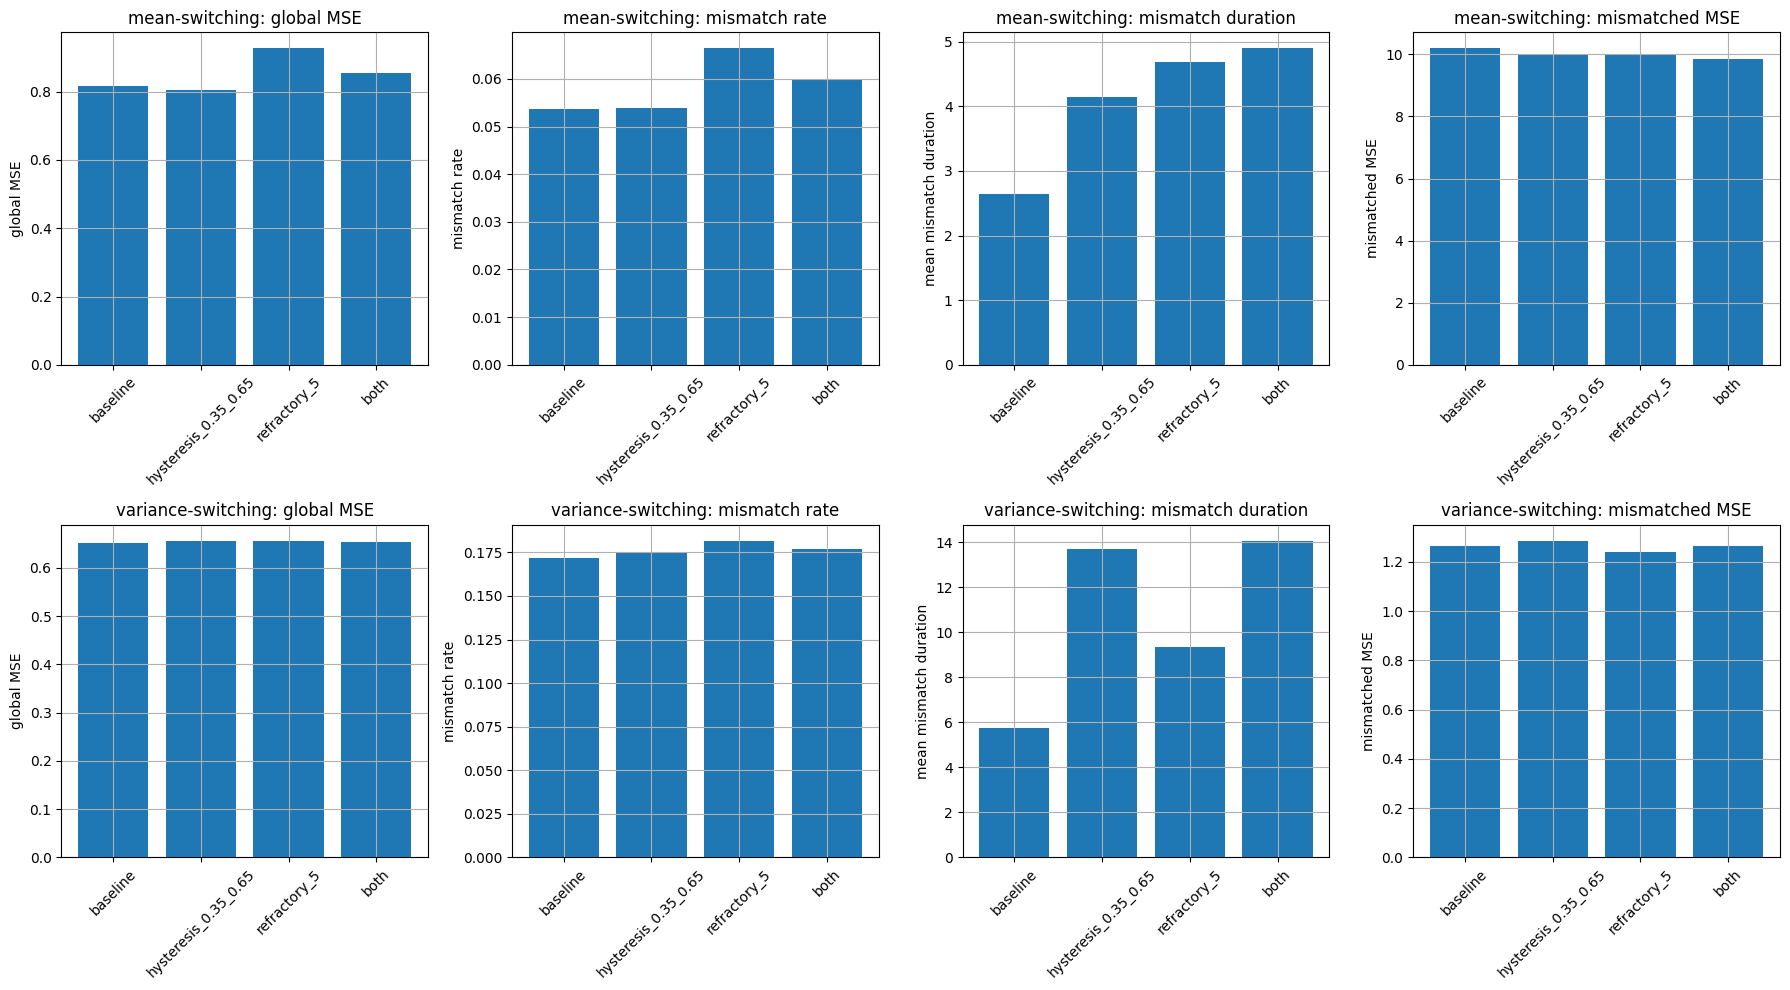

In [150]:
# ---------- baseline vs hysteresis vs refractory vs both comparison plots ----------

def extract_local_row(summary_df):
    return summary_df[summary_df["strategy"] == "adaptive_local"].copy()

mean_compare_df = pd.concat([
    extract_local_row(strategy_summary_mean).assign(mode="baseline"),
    extract_local_row(strategy_summary_mean_hysteresis).assign(mode=f"hysteresis_{tau_low_default}_{tau_high_default}"),
    extract_local_row(strategy_summary_mean_refractory).assign(mode=f"refractory_{refractory_default}"),
    extract_local_row(strategy_summary_mean_both).assign(mode="both"),
], ignore_index=True)

var_compare_df = pd.concat([
    extract_local_row(strategy_summary_var).assign(mode="baseline"),
    extract_local_row(strategy_summary_var_hysteresis).assign(mode=f"hysteresis_{tau_low_default}_{tau_high_default}"),
    extract_local_row(strategy_summary_var_refractory).assign(mode=f"refractory_{refractory_default}"),
    extract_local_row(strategy_summary_var_both).assign(mode="both"),
], ignore_index=True)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

axes[0, 0].bar(mean_compare_df["mode"], mean_compare_df["global_mse_mean"])
axes[0, 0].set_title("mean-switching: global MSE")
axes[0, 0].set_ylabel("global MSE")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(mean_compare_df["mode"], mean_compare_df["mismatch_rate_mean"])
axes[0, 1].set_title("mean-switching: mismatch rate")
axes[0, 1].set_ylabel("mismatch rate")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[0, 2].bar(mean_compare_df["mode"], mean_compare_df["mean_mismatch_duration_mean"])
axes[0, 2].set_title("mean-switching: mismatch duration")
axes[0, 2].set_ylabel("mean mismatch duration")
axes[0, 2].tick_params(axis="x", rotation=45)

axes[0, 3].bar(mean_compare_df["mode"], mean_compare_df["mismatched_mse_mean"])
axes[0, 3].set_title("mean-switching: mismatched MSE")
axes[0, 3].set_ylabel("mismatched MSE")
axes[0, 3].tick_params(axis="x", rotation=45)

axes[1, 0].bar(var_compare_df["mode"], var_compare_df["global_mse_mean"])
axes[1, 0].set_title("variance-switching: global MSE")
axes[1, 0].set_ylabel("global MSE")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].bar(var_compare_df["mode"], var_compare_df["mismatch_rate_mean"])
axes[1, 1].set_title("variance-switching: mismatch rate")
axes[1, 1].set_ylabel("mismatch rate")
axes[1, 1].tick_params(axis="x", rotation=45)

axes[1, 2].bar(var_compare_df["mode"], var_compare_df["mean_mismatch_duration_mean"])
axes[1, 2].set_title("variance-switching: mismatch duration")
axes[1, 2].set_ylabel("mean mismatch duration")
axes[1, 2].tick_params(axis="x", rotation=45)

axes[1, 3].bar(var_compare_df["mode"], var_compare_df["mismatched_mse_mean"])
axes[1, 3].set_title("variance-switching: mismatched MSE")
axes[1, 3].set_ylabel("mismatched MSE")
axes[1, 3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [151]:
# ---------- sweep hysteresis strength ----------

rows = []

for tau_low_now, tau_high_now in hysteresis_grid:
    _, mean_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        infer_acc_params=infer_acc_params_mean,
        best_gamma_static=best_gamma_mean_static,
        best_gamma_infer_acc=best_gamma_mean_infer_acc,
        nonlocal_params=nonlocal_target_params_mean,
        best_gamma_nonlocal=best_gamma_mean_nonlocal,
        adaptation_mode="hysteresis",
        tau_low=tau_low_now,
        tau_high=tau_high_now,
    )

    _, var_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        infer_acc_params=infer_acc_params_var,
        best_gamma_static=best_gamma_var_static,
        best_gamma_infer_acc=best_gamma_var_infer_acc,
        nonlocal_params=nonlocal_target_params_var,
        best_gamma_nonlocal=best_gamma_var_nonlocal,
        adaptation_mode="hysteresis",
        tau_low=tau_low_now,
        tau_high=tau_high_now,
    )

    mean_local_row = mean_summary_now[mean_summary_now["strategy"] == "adaptive_local"].iloc[0]
    var_local_row = var_summary_now[var_summary_now["strategy"] == "adaptive_local"].iloc[0]

    label_now = f"({tau_low_now:.2f},{tau_high_now:.2f})"

    rows.append({
        "env": "mean-switching",
        "threshold_pair": label_now,
        "tau_low": tau_low_now,
        "tau_high": tau_high_now,
        "global_mse": mean_local_row["global_mse_mean"],
        "mismatch_rate": mean_local_row["mismatch_rate_mean"],
        "mean_mismatch_duration": mean_local_row["mean_mismatch_duration_mean"],
        "mismatched_mse": mean_local_row["mismatched_mse_mean"],
    })
    rows.append({
        "env": "variance-switching",
        "threshold_pair": label_now,
        "tau_low": tau_low_now,
        "tau_high": tau_high_now,
        "global_mse": var_local_row["global_mse_mean"],
        "mismatch_rate": var_local_row["mismatch_rate_mean"],
        "mean_mismatch_duration": var_local_row["mean_mismatch_duration_mean"],
        "mismatched_mse": var_local_row["mismatched_mse_mean"],
    })

hysteresis_sweep_df = pd.DataFrame(rows)
display(hysteresis_sweep_df)

,env,threshold_pair,tau_low,tau_high,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean-switching,"(0.50,0.50)",0.50,0.50,0.816511,0.053722,2.637157,10.199162
1,variance-switching,"(0.50,0.50)",0.50,0.50,0.651979,0.171944,5.753751,1.263547
2,mean-switching,"(0.40,0.60)",0.40,0.60,0.815126,0.054778,3.538620,9.973956
3,variance-switching,"(0.40,0.60)",0.40,0.60,0.657836,0.178556,11.230390,1.282632
4,mean-switching,"(0.35,0.65)",0.35,0.65,0.805652,0.053833,4.149864,9.989200
5,variance-switching,"(0.35,0.65)",0.35,0.65,0.655215,0.174944,13.678285,1.286346
6,mean-switching,"(0.30,0.70)",0.30,0.70,0.812224,0.055000,4.523266,9.903926
7,variance-switching,"(0.30,0.70)",0.30,0.70,0.654712,0.178389,15.767627,1.245028


In [152]:
# ---------- sweep refractory strength ----------

rows = []

for refractory_now in refractory_grid:
    _, mean_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        infer_acc_params=infer_acc_params_mean,
        best_gamma_static=best_gamma_mean_static,
        best_gamma_infer_acc=best_gamma_mean_infer_acc,
        nonlocal_params=nonlocal_target_params_mean,
        best_gamma_nonlocal=best_gamma_mean_nonlocal,
        adaptation_mode="refractory",
        refractory_length=refractory_now,
    )

    _, var_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        infer_acc_params=infer_acc_params_var,
        best_gamma_static=best_gamma_var_static,
        best_gamma_infer_acc=best_gamma_var_infer_acc,
        nonlocal_params=nonlocal_target_params_var,
        best_gamma_nonlocal=best_gamma_var_nonlocal,
        adaptation_mode="refractory",
        refractory_length=refractory_now,
    )

    mean_local_row = mean_summary_now[mean_summary_now["strategy"] == "adaptive_local"].iloc[0]
    var_local_row = var_summary_now[var_summary_now["strategy"] == "adaptive_local"].iloc[0]

    rows.append({
        "env": "mean-switching",
        "refractory_length": refractory_now,
        "global_mse": mean_local_row["global_mse_mean"],
        "mismatch_rate": mean_local_row["mismatch_rate_mean"],
        "mean_mismatch_duration": mean_local_row["mean_mismatch_duration_mean"],
        "mismatched_mse": mean_local_row["mismatched_mse_mean"],
    })
    rows.append({
        "env": "variance-switching",
        "refractory_length": refractory_now,
        "global_mse": var_local_row["global_mse_mean"],
        "mismatch_rate": var_local_row["mismatch_rate_mean"],
        "mean_mismatch_duration": var_local_row["mean_mismatch_duration_mean"],
        "mismatched_mse": var_local_row["mismatched_mse_mean"],
    })

refractory_sweep_df = pd.DataFrame(rows)
display(refractory_sweep_df)

,env,refractory_length,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean-switching,0,0.816511,0.053722,2.637157,10.199162
1,variance-switching,0,0.651979,0.171944,5.753751,1.263547
2,mean-switching,2,0.837350,0.056667,3.736035,10.049352
3,variance-switching,2,0.657275,0.176833,7.709810,1.257395
4,mean-switching,5,0.927327,0.066444,4.680088,9.969866
5,variance-switching,5,0.656676,0.181722,9.324535,1.240511
6,mean-switching,10,1.076604,0.083833,6.148171,9.749853
7,variance-switching,10,0.664125,0.199000,11.749300,1.190515
8,mean-switching,20,1.443072,0.119667,9.510314,9.986631
9,variance-switching,20,0.688655,0.235611,15.941747,1.183334


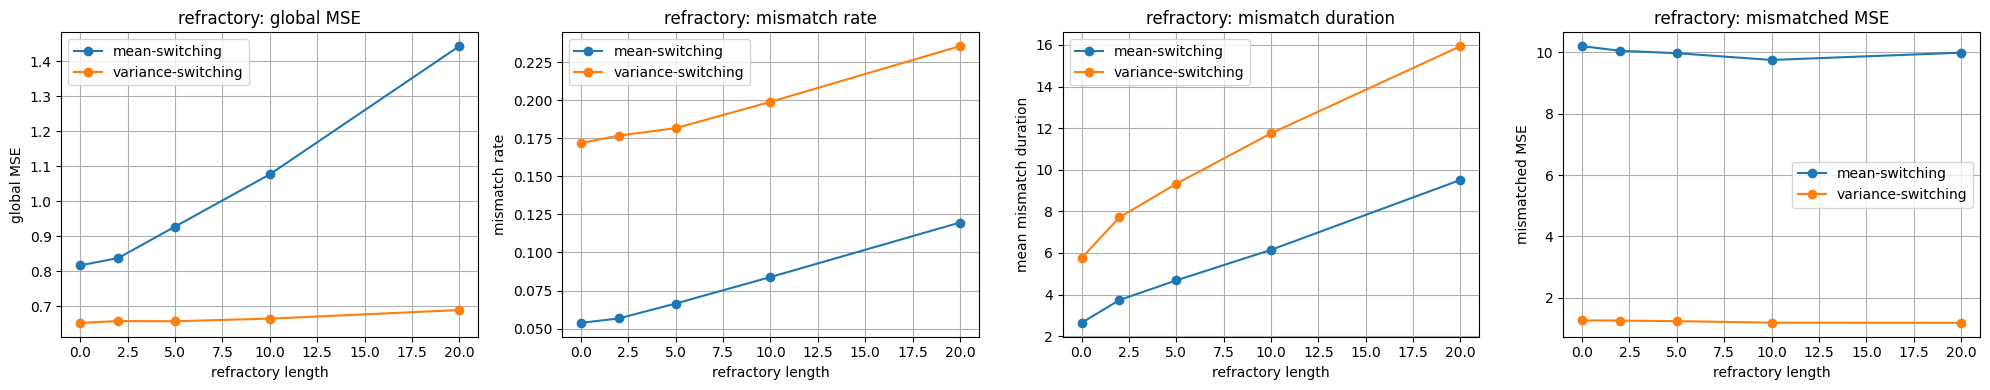

In [153]:
# ---------- refractory sweep plots ----------

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for env_name in ["mean-switching", "variance-switching"]:
    df_now = refractory_sweep_df[refractory_sweep_df["env"] == env_name]
    axes[0].plot(df_now["refractory_length"], df_now["global_mse"], marker="o", label=env_name)
    axes[1].plot(df_now["refractory_length"], df_now["mismatch_rate"], marker="o", label=env_name)
    axes[2].plot(df_now["refractory_length"], df_now["mean_mismatch_duration"], marker="o", label=env_name)
    axes[3].plot(df_now["refractory_length"], df_now["mismatched_mse"], marker="o", label=env_name)

axes[0].set_title("refractory: global MSE")
axes[0].set_xlabel("refractory length")
axes[0].set_ylabel("global MSE")
axes[0].legend()

axes[1].set_title("refractory: mismatch rate")
axes[1].set_xlabel("refractory length")
axes[1].set_ylabel("mismatch rate")
axes[1].legend()

axes[2].set_title("refractory: mismatch duration")
axes[2].set_xlabel("refractory length")
axes[2].set_ylabel("mean mismatch duration")
axes[2].legend()

axes[3].set_title("refractory: mismatched MSE")
axes[3].set_xlabel("refractory length")
axes[3].set_ylabel("mismatched MSE")
axes[3].legend()

plt.tight_layout()
plt.show()

In [154]:
# ---------- sweep combined hysteresis + refractory strength ----------

rows = []

for tau_low_now, tau_high_now, refractory_now in combined_grid:
    _, mean_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        infer_acc_params=infer_acc_params_mean,
        best_gamma_static=best_gamma_mean_static,
        best_gamma_infer_acc=best_gamma_mean_infer_acc,
        nonlocal_params=nonlocal_target_params_mean,
        best_gamma_nonlocal=best_gamma_mean_nonlocal,
        adaptation_mode="both",
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
    )

    _, var_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        infer_acc_params=infer_acc_params_var,
        best_gamma_static=best_gamma_var_static,
        best_gamma_infer_acc=best_gamma_var_infer_acc,
        nonlocal_params=nonlocal_target_params_var,
        best_gamma_nonlocal=best_gamma_var_nonlocal,
        adaptation_mode="both",
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
    )

    mean_local_row = mean_summary_now[mean_summary_now["strategy"] == "adaptive_local"].iloc[0]
    var_local_row = var_summary_now[var_summary_now["strategy"] == "adaptive_local"].iloc[0]

    label_now = f"({tau_low_now:.2f},{tau_high_now:.2f},{refractory_now})"

    rows.append({
        "env": "mean-switching",
        "setting": label_now,
        "tau_low": tau_low_now,
        "tau_high": tau_high_now,
        "refractory_length": refractory_now,
        "global_mse": mean_local_row["global_mse_mean"],
        "mismatch_rate": mean_local_row["mismatch_rate_mean"],
        "mean_mismatch_duration": mean_local_row["mean_mismatch_duration_mean"],
        "mismatched_mse": mean_local_row["mismatched_mse_mean"],
    })
    rows.append({
        "env": "variance-switching",
        "setting": label_now,
        "tau_low": tau_low_now,
        "tau_high": tau_high_now,
        "refractory_length": refractory_now,
        "global_mse": var_local_row["global_mse_mean"],
        "mismatch_rate": var_local_row["mismatch_rate_mean"],
        "mean_mismatch_duration": var_local_row["mean_mismatch_duration_mean"],
        "mismatched_mse": var_local_row["mismatched_mse_mean"],
    })

combined_sweep_df = pd.DataFrame(rows)
display(combined_sweep_df)

,env,setting,tau_low,tau_high,refractory_length,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean-switching,"(0.50,0.50,0)",0.50,0.50,0,0.816511,0.053722,2.637157,10.199162
1,variance-switching,"(0.50,0.50,0)",0.50,0.50,0,0.651979,0.171944,5.753751,1.263547
2,mean-switching,"(0.40,0.60,2)",0.40,0.60,2,0.806275,0.054556,4.161046,9.880849
3,variance-switching,"(0.40,0.60,2)",0.40,0.60,2,0.657168,0.179056,11.729979,1.281406
4,mean-switching,"(0.35,0.65,5)",0.35,0.65,5,0.854315,0.059722,4.899513,9.843549
5,variance-switching,"(0.35,0.65,5)",0.35,0.65,5,0.654334,0.176833,14.070858,1.264924
6,mean-switching,"(0.30,0.70,10)",0.30,0.70,10,0.913431,0.067056,5.894563,9.678585
7,variance-switching,"(0.30,0.70,10)",0.30,0.70,10,0.655560,0.183444,16.356110,1.216540


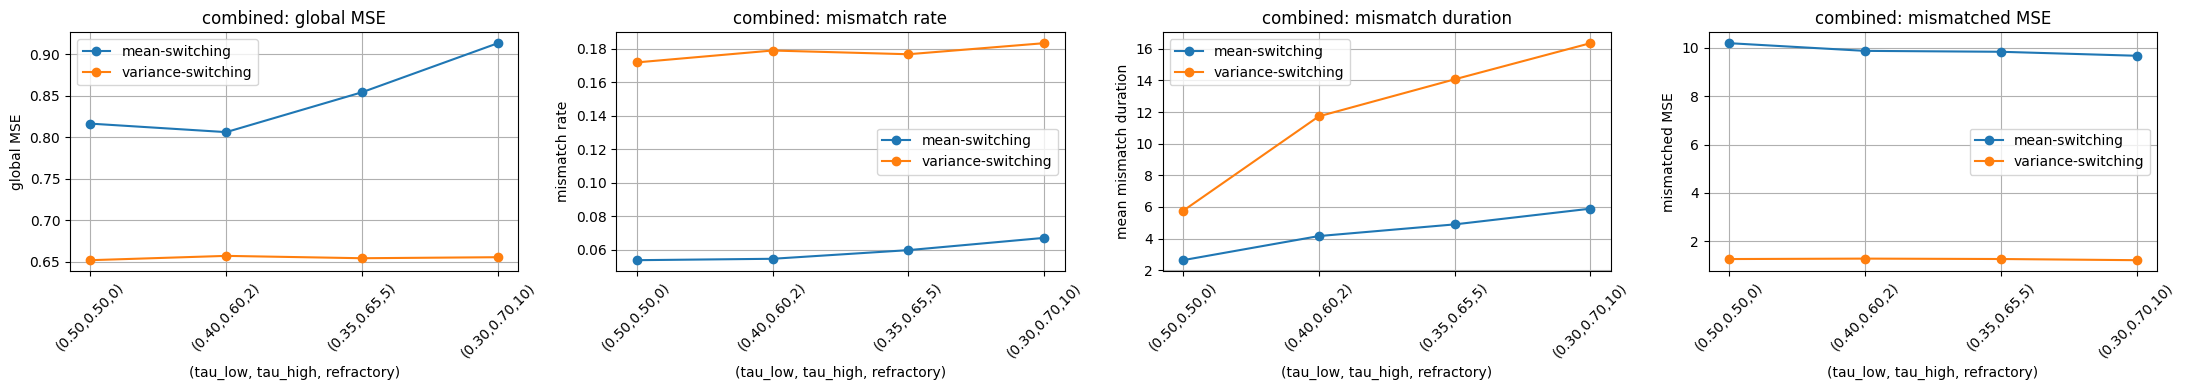

In [155]:
# ---------- combined sweep plots ----------

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for env_name in ["mean-switching", "variance-switching"]:
    df_now = combined_sweep_df[combined_sweep_df["env"] == env_name]
    x_labels = df_now["setting"].tolist()

    axes[0].plot(x_labels, df_now["global_mse"], marker="o", label=env_name)
    axes[1].plot(x_labels, df_now["mismatch_rate"], marker="o", label=env_name)
    axes[2].plot(x_labels, df_now["mean_mismatch_duration"], marker="o", label=env_name)
    axes[3].plot(x_labels, df_now["mismatched_mse"], marker="o", label=env_name)

axes[0].set_title("combined: global MSE")
axes[0].set_xlabel("(tau_low, tau_high, refractory)")
axes[0].set_ylabel("global MSE")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].set_title("combined: mismatch rate")
axes[1].set_xlabel("(tau_low, tau_high, refractory)")
axes[1].set_ylabel("mismatch rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

axes[2].set_title("combined: mismatch duration")
axes[2].set_xlabel("(tau_low, tau_high, refractory)")
axes[2].set_ylabel("mean mismatch duration")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend()

axes[3].set_title("combined: mismatched MSE")
axes[3].set_xlabel("(tau_low, tau_high, refractory)")
axes[3].set_ylabel("mismatched MSE")
axes[3].tick_params(axis="x", rotation=45)
axes[3].legend()

plt.tight_layout()
plt.show()

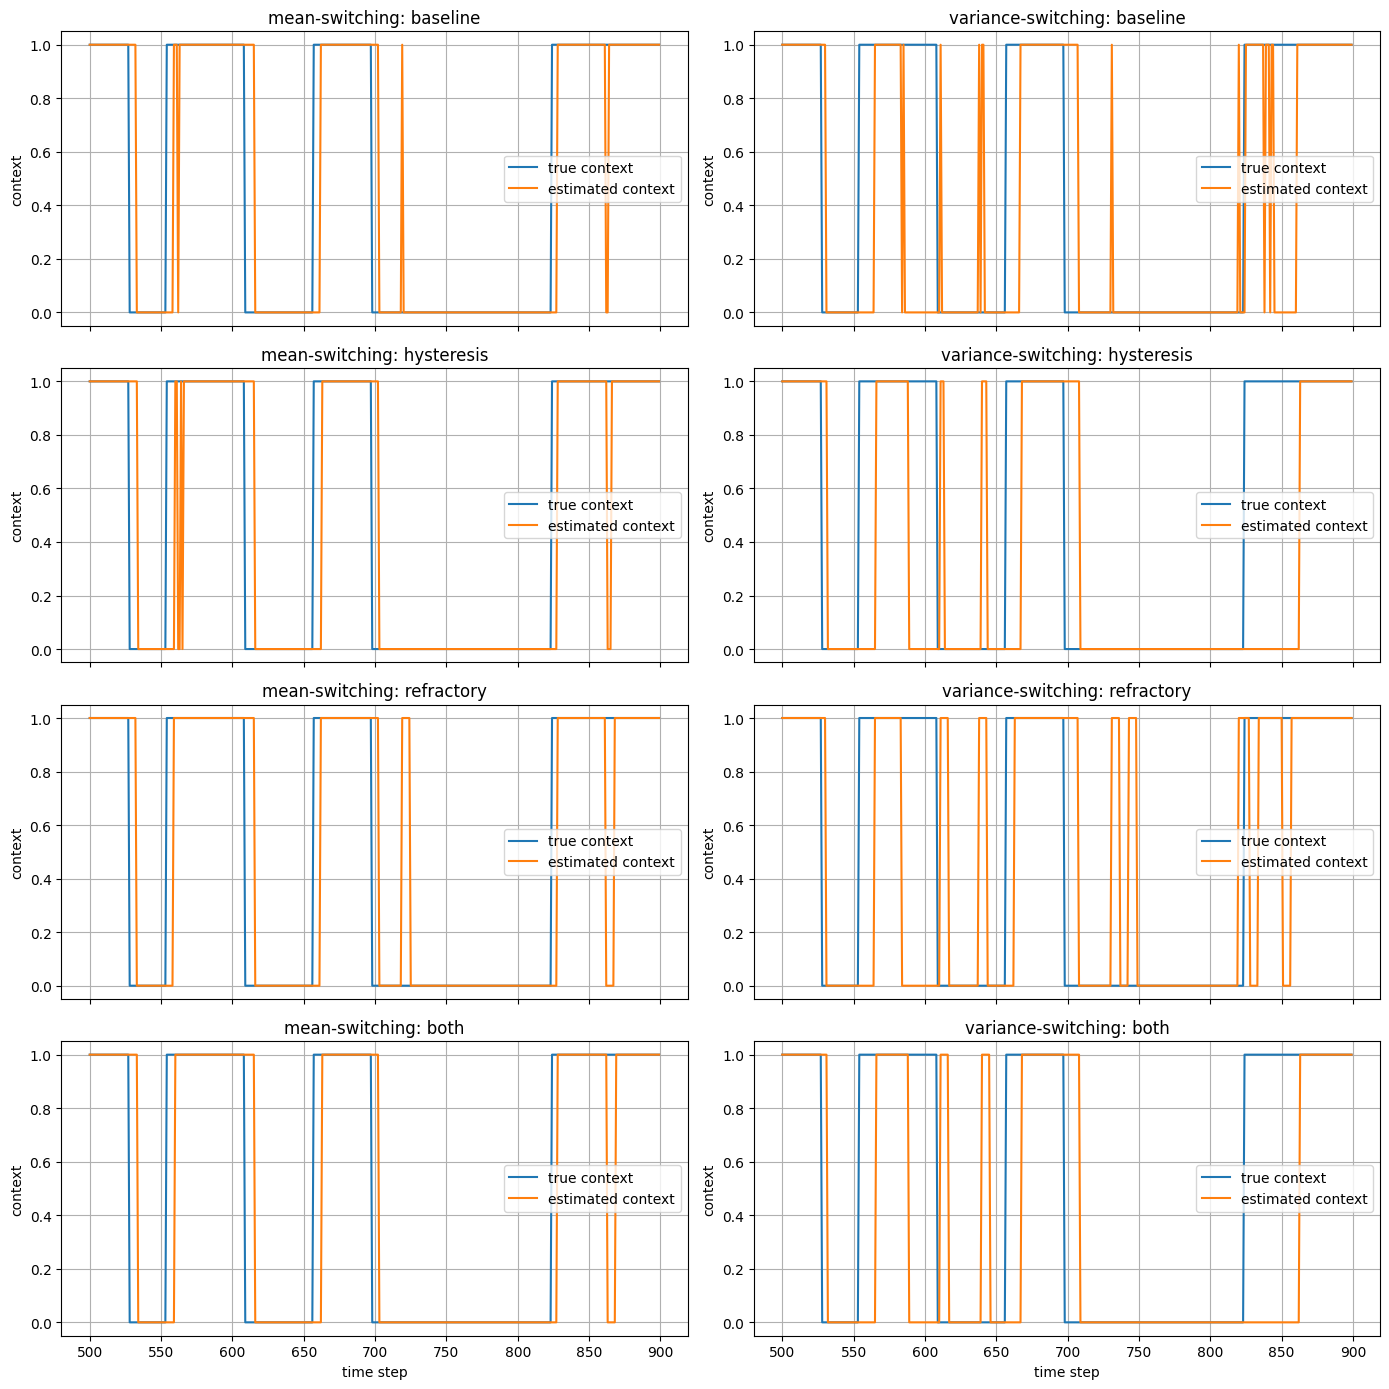

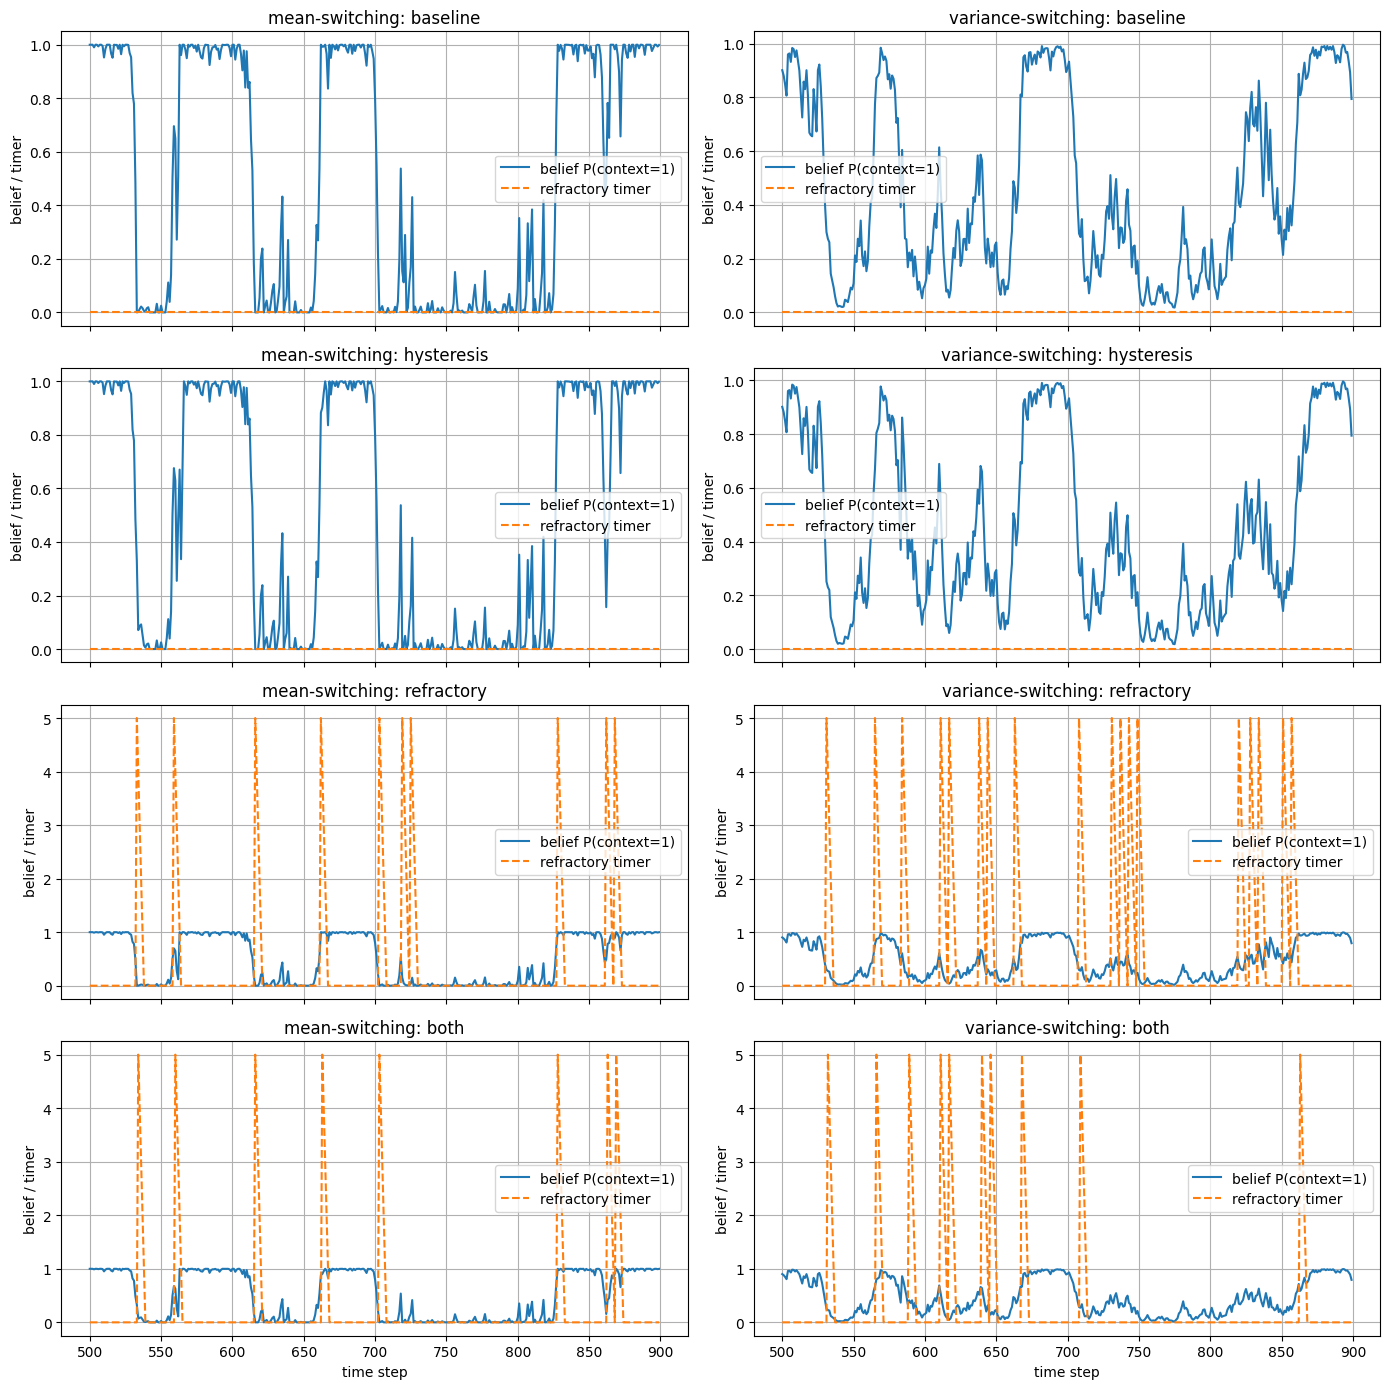

In [156]:
# ---------- optional traces for hysteresis, refractory, and both ----------

show_slice = slice(500, 900)

mean_base_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="instant",
)

mean_hyst_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="hysteresis",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
)

mean_refr_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="refractory",
    refractory_length=refractory_default,
)

mean_both_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="both",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
    refractory_length=refractory_default,
)

var_base_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="instant",
)

var_hyst_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="hysteresis",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
)

var_refr_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="refractory",
    refractory_length=refractory_default,
)

var_both_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="both",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
    refractory_length=refractory_default,
)

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)

for ax, out, title in [
    (axes[0, 0], mean_base_out, "mean-switching: baseline"),
    (axes[1, 0], mean_hyst_out, "mean-switching: hysteresis"),
    (axes[2, 0], mean_refr_out, "mean-switching: refractory"),
    (axes[3, 0], mean_both_out, "mean-switching: both"),
    (axes[0, 1], var_base_out, "variance-switching: baseline"),
    (axes[1, 1], var_hyst_out, "variance-switching: hysteresis"),
    (axes[2, 1], var_refr_out, "variance-switching: refractory"),
    (axes[3, 1], var_both_out, "variance-switching: both"),
]:
    df = out["df"].iloc[show_slice]
    ax.plot(df["t"], df["true_context"], label="true context")
    ax.plot(df["t"], df["estimated_context"], label="estimated context")
    ax.set_title(title)
    ax.set_ylabel("context")
    ax.legend()

axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)

for ax, out, title in [
    (axes[0, 0], mean_base_out, "mean-switching: baseline"),
    (axes[1, 0], mean_hyst_out, "mean-switching: hysteresis"),
    (axes[2, 0], mean_refr_out, "mean-switching: refractory"),
    (axes[3, 0], mean_both_out, "mean-switching: both"),
    (axes[0, 1], var_base_out, "variance-switching: baseline"),
    (axes[1, 1], var_hyst_out, "variance-switching: hysteresis"),
    (axes[2, 1], var_refr_out, "variance-switching: refractory"),
    (axes[3, 1], var_both_out, "variance-switching: both"),
]:
    df = out["df"].iloc[show_slice]
    ax.plot(df["t"], df["belief_context_1"], label="belief P(context=1)")
    ax.plot(df["t"], df["refractory_timer"], label="refractory timer", linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("belief / timer")
    ax.legend()

axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")

plt.tight_layout()
plt.show()

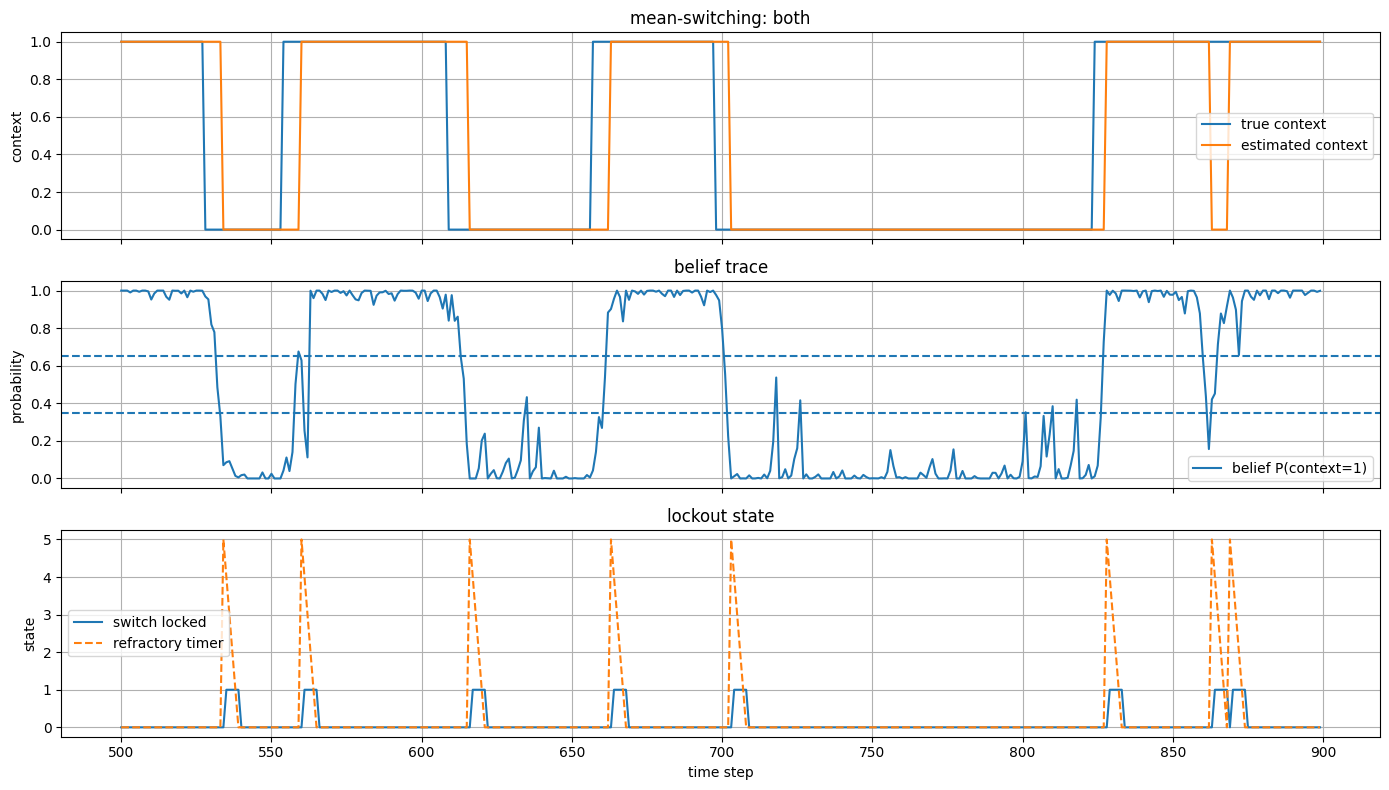

In [157]:
# ---------- optional direct lockout trace ----------

trace_df = mean_both_out["df"].iloc[show_slice].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(trace_df["t"], trace_df["true_context"], label="true context")
axes[0].plot(trace_df["t"], trace_df["estimated_context"], label="estimated context")
axes[0].set_title("mean-switching: both")
axes[0].set_ylabel("context")
axes[0].legend()

axes[1].plot(trace_df["t"], trace_df["belief_context_1"], label="belief P(context=1)")
axes[1].axhline(tau_low_default, linestyle="--")
axes[1].axhline(tau_high_default, linestyle="--")
axes[1].set_title("belief trace")
axes[1].set_ylabel("probability")
axes[1].legend()

axes[2].plot(trace_df["t"], trace_df["switch_locked"].astype(float), label="switch locked")
axes[2].plot(trace_df["t"], trace_df["refractory_timer"], linestyle="--", label="refractory timer")
axes[2].set_title("lockout state")
axes[2].set_xlabel("time step")
axes[2].set_ylabel("state")
axes[2].legend()

plt.tight_layout()
plt.show()

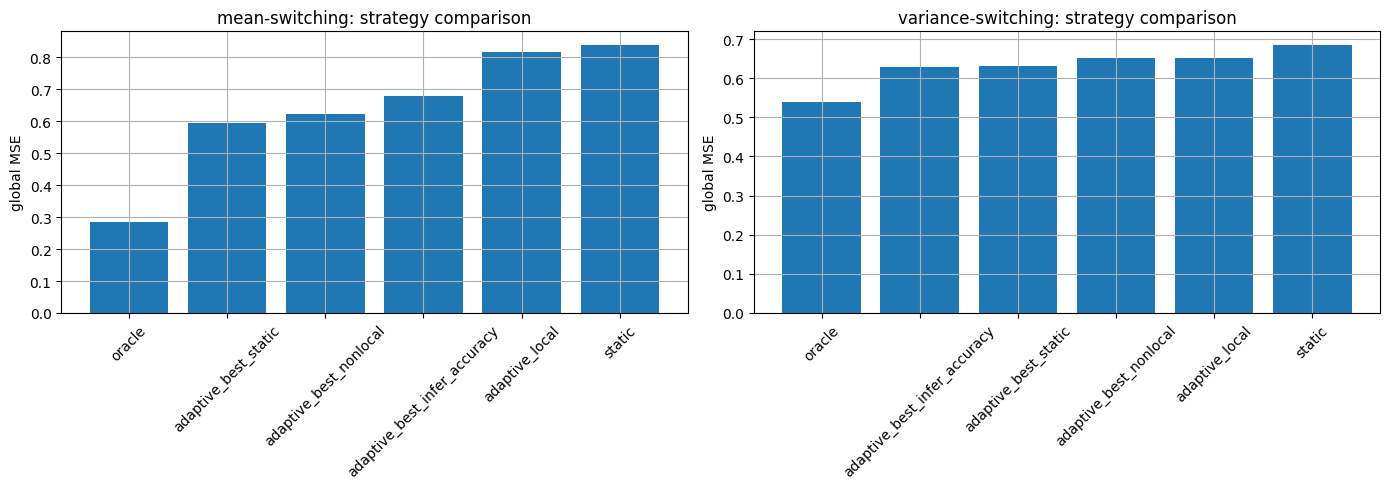

In [158]:
# ---------- main strategy comparison plots ----------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(strategy_summary_mean["strategy"], strategy_summary_mean["global_mse_mean"])
axes[0].set_title("mean-switching: strategy comparison")
axes[0].set_ylabel("global MSE")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(strategy_summary_var["strategy"], strategy_summary_var["global_mse_mean"])
axes[1].set_title("variance-switching: strategy comparison")
axes[1].set_ylabel("global MSE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

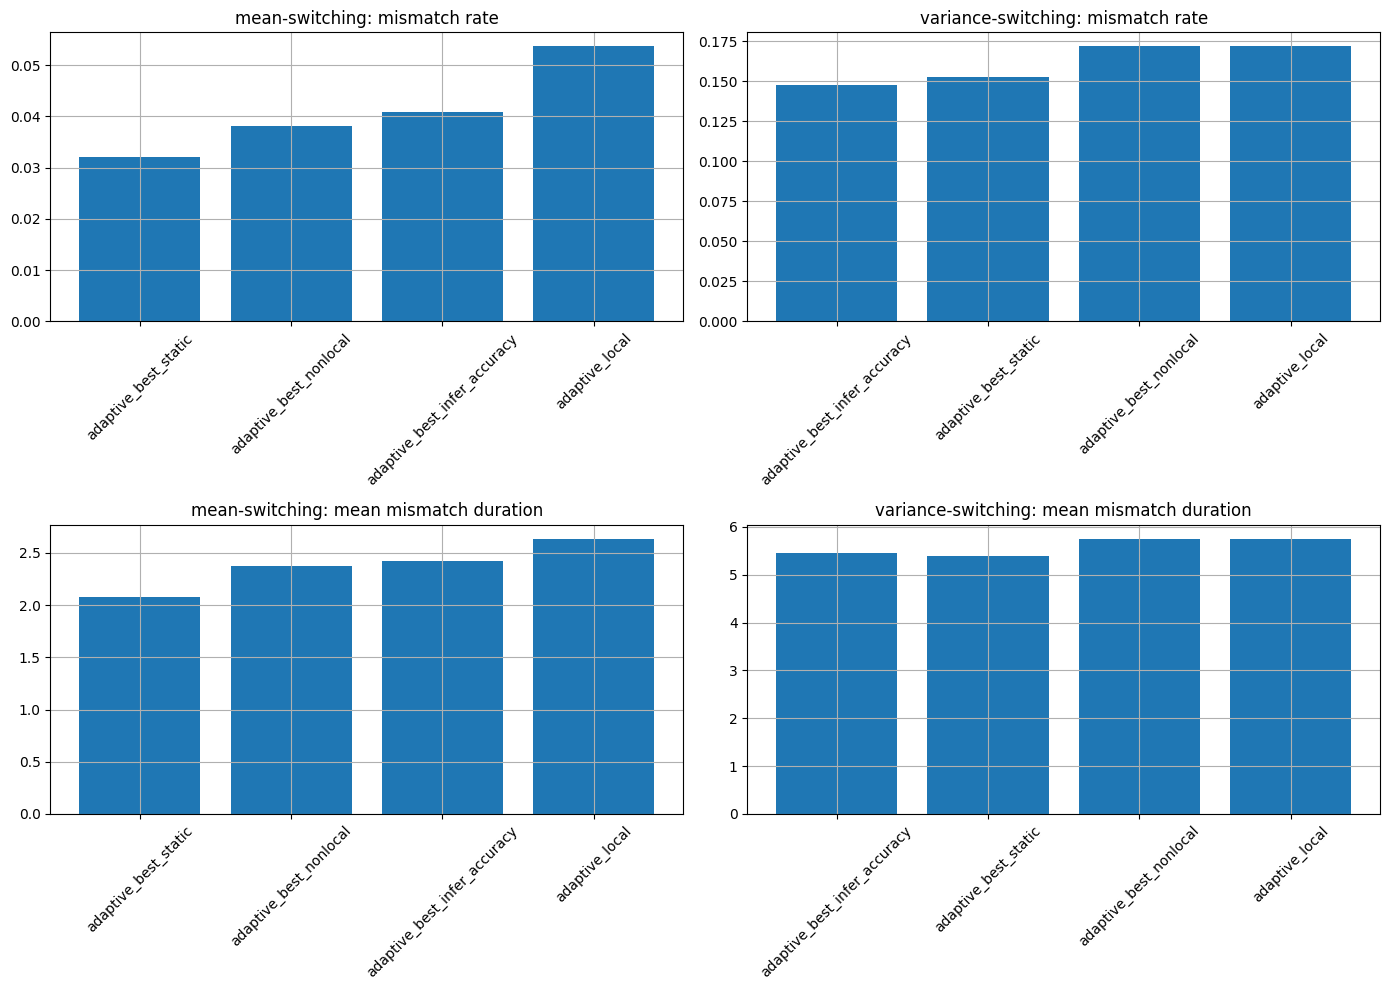

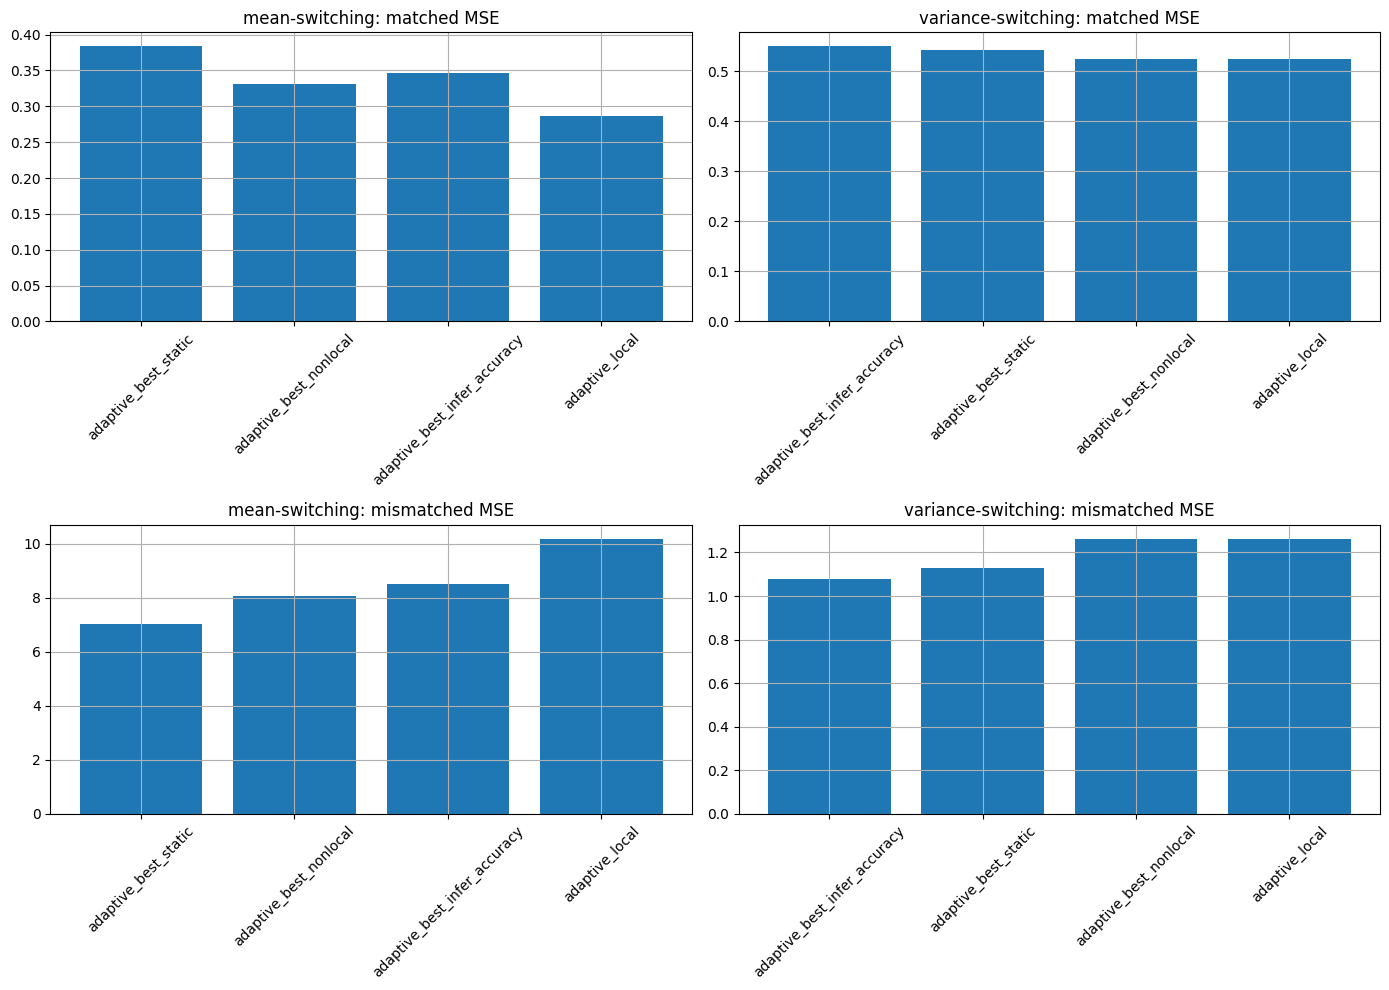

In [159]:
# ---------- mismatch decomposition plots for default environments ----------

adaptive_rows_mean = strategy_summary_mean[
    strategy_summary_mean["strategy"].str.contains("adaptive")
].copy()

adaptive_rows_var = strategy_summary_var[
    strategy_summary_var["strategy"].str.contains("adaptive")
].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(adaptive_rows_mean["strategy"], adaptive_rows_mean["mismatch_rate_mean"])
axes[0, 0].set_title("mean-switching: mismatch rate")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(adaptive_rows_var["strategy"], adaptive_rows_var["mismatch_rate_mean"])
axes[0, 1].set_title("variance-switching: mismatch rate")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(adaptive_rows_mean["strategy"], adaptive_rows_mean["mean_mismatch_duration_mean"])
axes[1, 0].set_title("mean-switching: mean mismatch duration")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].bar(adaptive_rows_var["strategy"], adaptive_rows_var["mean_mismatch_duration_mean"])
axes[1, 1].set_title("variance-switching: mean mismatch duration")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(adaptive_rows_mean["strategy"], adaptive_rows_mean["matched_mse_mean"])
axes[0, 0].set_title("mean-switching: matched MSE")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(adaptive_rows_var["strategy"], adaptive_rows_var["matched_mse_mean"])
axes[0, 1].set_title("variance-switching: matched MSE")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(adaptive_rows_mean["strategy"], adaptive_rows_mean["mismatched_mse_mean"])
axes[1, 0].set_title("mean-switching: mismatched MSE")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].bar(adaptive_rows_var["strategy"], adaptive_rows_var["mismatched_mse_mean"])
axes[1, 1].set_title("variance-switching: mismatched MSE")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [160]:
# ---------- dense separation sweep helpers ----------

def summarize_best_family(summary_static, summary_acc, summary_nonlocal):
    best_static = summary_static.sort_values("global_mse_mean").iloc[0]
    best_acc = summary_acc.sort_values("global_mse_mean").iloc[0]
    best_nonlocal = summary_nonlocal.sort_values("global_mse_mean").iloc[0]

    candidates = [
        ("toward static", best_static),
        ("toward accuracy", best_acc),
        ("toward nonlocal", best_nonlocal),
    ]
    best_label, best_row = min(candidates, key=lambda z: z[1]["global_mse_mean"])
    return best_label, best_row


def run_mean_separation_sweep(
    delta_grid,
    sigma=1.0,
    gamma_grid=gamma_grid,
    p_switch=p_switch_main,
):
    rows = []

    for delta in delta_grid:
        contexts = make_mean_contexts(delta=delta, sigma=sigma)
        fit = fit_codebook_for_contexts(contexts, seed_offset=int(100 * delta))

        summary_static = sweep_gamma_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            target_params=fit["static_params"],
            family_name="toward static",
            gamma_grid=gamma_grid,
            p_switch=p_switch,
        )[1]

        summary_acc = sweep_gamma_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            target_params=fit["infer_acc_params"],
            family_name="toward accuracy",
            gamma_grid=gamma_grid,
            p_switch=p_switch,
        )[1]

        summary_nonlocal = sweep_gamma_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            target_params=fit["nonlocal_target_params"],
            family_name="toward nonlocal",
            gamma_grid=gamma_grid,
            p_switch=p_switch,
        )[1]

        best_label, best_row = summarize_best_family(summary_static, summary_acc, summary_nonlocal)

        strategy_summary = evaluate_strategy_set_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            infer_acc_params=fit["infer_acc_params"],
            best_gamma_static=float(summary_static.sort_values("global_mse_mean").iloc[0]["gamma"]),
            best_gamma_infer_acc=float(summary_acc.sort_values("global_mse_mean").iloc[0]["gamma"]),
            nonlocal_params=fit["nonlocal_target_params"],
            best_gamma_nonlocal=float(summary_nonlocal.sort_values("global_mse_mean").iloc[0]["gamma"]),
            p_switch=p_switch,
        )[1]

        oracle_mse = strategy_summary.loc[strategy_summary["strategy"] == "oracle", "global_mse_mean"].iloc[0]
        static_mse = strategy_summary.loc[strategy_summary["strategy"] == "static", "global_mse_mean"].iloc[0]
        local_mse = strategy_summary.loc[strategy_summary["strategy"] == "adaptive_local", "global_mse_mean"].iloc[0]

        rows.append({
            "delta": delta,
            "oracle_mse": oracle_mse,
            "static_mse": static_mse,
            "adaptive_local_mse": local_mse,
            "best_family": best_label,
            "best_gamma": float(best_row["gamma"]),
            "best_global_mse": float(best_row["global_mse_mean"]),
            "best_mismatch_rate": float(best_row["mismatch_rate_mean"]),
            "best_matched_mse": float(best_row["matched_mse_mean"]),
            "best_mismatched_mse": float(best_row["mismatched_mse_mean"]),
            "best_mean_mismatch_duration": float(best_row["mean_mismatch_duration_mean"]),
            "best_static_gamma": float(summary_static.sort_values("global_mse_mean").iloc[0]["gamma"]),
            "best_acc_gamma": float(summary_acc.sort_values("global_mse_mean").iloc[0]["gamma"]),
            "best_nonlocal_gamma": float(summary_nonlocal.sort_values("global_mse_mean").iloc[0]["gamma"]),
            "best_static_mse": float(summary_static.sort_values("global_mse_mean").iloc[0]["global_mse_mean"]),
            "best_acc_mse": float(summary_acc.sort_values("global_mse_mean").iloc[0]["global_mse_mean"]),
            "best_nonlocal_mse": float(summary_nonlocal.sort_values("global_mse_mean").iloc[0]["global_mse_mean"]),
        })

    return pd.DataFrame(rows).sort_values("delta", ascending=False).reset_index(drop=True)


def run_variance_separation_sweep(
    sigma_low=0.7,
    sigma_high_grid=None,
    gamma_grid=gamma_grid,
    p_switch=p_switch_main,
):
    if sigma_high_grid is None:
        sigma_high_grid = np.linspace(0.8, 1.9, 10)

    rows = []

    for sigma_high in sigma_high_grid:
        contexts = make_variance_contexts(sigma_low=sigma_low, sigma_high=sigma_high, mu=0.0)
        fit = fit_codebook_for_contexts(contexts, seed_offset=int(1000 * sigma_high))

        summary_static = sweep_gamma_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            target_params=fit["static_params"],
            family_name="toward static",
            gamma_grid=gamma_grid,
            p_switch=p_switch,
        )[1]

        summary_acc = sweep_gamma_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            target_params=fit["infer_acc_params"],
            family_name="toward accuracy",
            gamma_grid=gamma_grid,
            p_switch=p_switch,
        )[1]

        summary_nonlocal = sweep_gamma_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            target_params=fit["nonlocal_target_params"],
            family_name="toward nonlocal",
            gamma_grid=gamma_grid,
            p_switch=p_switch,
        )[1]

        best_label, best_row = summarize_best_family(summary_static, summary_acc, summary_nonlocal)

        strategy_summary = evaluate_strategy_set_one_neuron(
            contexts=contexts,
            x_grid=fit["x_grid"],
            local_params=fit["local_params"],
            static_params=fit["static_params"],
            infer_acc_params=fit["infer_acc_params"],
            best_gamma_static=float(summary_static.sort_values("global_mse_mean").iloc[0]["gamma"]),
            best_gamma_infer_acc=float(summary_acc.sort_values("global_mse_mean").iloc[0]["gamma"]),
            nonlocal_params=fit["nonlocal_target_params"],
            best_gamma_nonlocal=float(summary_nonlocal.sort_values("global_mse_mean").iloc[0]["gamma"]),
            p_switch=p_switch,
        )[1]

        oracle_mse = strategy_summary.loc[strategy_summary["strategy"] == "oracle", "global_mse_mean"].iloc[0]
        static_mse = strategy_summary.loc[strategy_summary["strategy"] == "static", "global_mse_mean"].iloc[0]
        local_mse = strategy_summary.loc[strategy_summary["strategy"] == "adaptive_local", "global_mse_mean"].iloc[0]

        rows.append({
            "sigma_high": sigma_high,
            "sigma_diff": sigma_high - sigma_low,
            "oracle_mse": oracle_mse,
            "static_mse": static_mse,
            "adaptive_local_mse": local_mse,
            "best_family": best_label,
            "best_gamma": float(best_row["gamma"]),
            "best_global_mse": float(best_row["global_mse_mean"]),
            "best_mismatch_rate": float(best_row["mismatch_rate_mean"]),
            "best_matched_mse": float(best_row["matched_mse_mean"]),
            "best_mismatched_mse": float(best_row["mismatched_mse_mean"]),
            "best_mean_mismatch_duration": float(best_row["mean_mismatch_duration_mean"]),
            "best_static_gamma": float(summary_static.sort_values("global_mse_mean").iloc[0]["gamma"]),
            "best_acc_gamma": float(summary_acc.sort_values("global_mse_mean").iloc[0]["gamma"]),
            "best_nonlocal_gamma": float(summary_nonlocal.sort_values("global_mse_mean").iloc[0]["gamma"]),
            "best_static_mse": float(summary_static.sort_values("global_mse_mean").iloc[0]["global_mse_mean"]),
            "best_acc_mse": float(summary_acc.sort_values("global_mse_mean").iloc[0]["global_mse_mean"]),
            "best_nonlocal_mse": float(summary_nonlocal.sort_values("global_mse_mean").iloc[0]["global_mse_mean"]),
        })

    return pd.DataFrame(rows).sort_values("sigma_diff", ascending=False).reset_index(drop=True)

In [161]:
# ---------- run dense separation sweeps ----------

mean_delta_grid = np.linspace(0.5, 2.0, 10)
var_sigma_high_grid = np.linspace(0.8, 1.9, 10)

mean_sep_df = run_mean_separation_sweep(mean_delta_grid, sigma=1.0)
var_sep_df = run_variance_separation_sweep(sigma_low=0.7, sigma_high_grid=var_sigma_high_grid)

display(mean_sep_df.head())
display(var_sep_df.head())

,delta,oracle_mse,static_mse,adaptive_local_mse,best_family,best_gamma,best_global_mse,best_mismatch_rate,best_matched_mse,best_mismatched_mse,best_mean_mismatch_duration,best_static_gamma,best_acc_gamma,best_nonlocal_gamma,best_static_mse,best_acc_mse,best_nonlocal_mse
0,2.000000,0.286008,0.498817,0.399940,toward static,0.375,0.370488,0.051111,0.310995,1.490765,2.776065,0.375,0.250,0.125,0.370488,0.396682,0.374954
1,1.833333,0.286008,0.470224,0.380826,toward static,0.375,0.359027,0.056333,0.307439,1.236690,2.901163,0.375,0.000,0.125,0.359027,0.380826,0.361186
2,1.666667,0.286008,0.442520,0.368212,toward static,0.375,0.347568,0.063000,0.304400,0.999048,3.076097,0.375,0.125,0.125,0.347568,0.368208,0.350402
3,1.500000,0.286008,0.415985,0.350955,toward static,0.375,0.338688,0.069667,0.301179,0.842490,3.289737,0.375,0.000,0.125,0.338688,0.350955,0.341052
4,1.333333,0.286008,0.390941,0.340372,toward static,0.250,0.329003,0.082722,0.290488,0.760918,3.684464,0.250,0.125,0.125,0.329003,0.339646,0.329874


,sigma_high,sigma_diff,oracle_mse,static_mse,adaptive_local_mse,best_family,best_gamma,best_global_mse,best_mismatch_rate,best_matched_mse,best_mismatched_mse,best_mean_mismatch_duration,best_static_gamma,best_acc_gamma,best_nonlocal_gamma,best_static_mse,best_acc_mse,best_nonlocal_mse
0,1.900000,1.200000,0.592468,0.763293,0.722077,toward accuracy,0.750,0.693456,0.139889,0.603888,1.236637,5.243855,0.875,0.750,0.125,0.695114,0.693456,0.718804
1,1.777778,1.077778,0.527301,0.668928,0.635201,toward accuracy,0.750,0.615304,0.149056,0.539278,1.042665,5.532004,0.625,0.750,0.000,0.618042,0.615304,0.635201
2,1.655556,0.955556,0.466465,0.580962,0.560282,toward accuracy,0.750,0.541658,0.159333,0.478754,0.868255,5.837007,0.625,0.750,0.125,0.544693,0.541658,0.558843
3,1.533333,0.833333,0.409960,0.499585,0.484436,toward accuracy,0.625,0.471940,0.175944,0.415982,0.730164,5.998789,0.750,0.625,0.125,0.474503,0.471940,0.482547
4,1.411111,0.711111,0.357787,0.425020,0.414944,toward accuracy,0.625,0.408978,0.190500,0.364055,0.597085,6.268387,0.625,0.625,0.125,0.409589,0.408978,0.413271


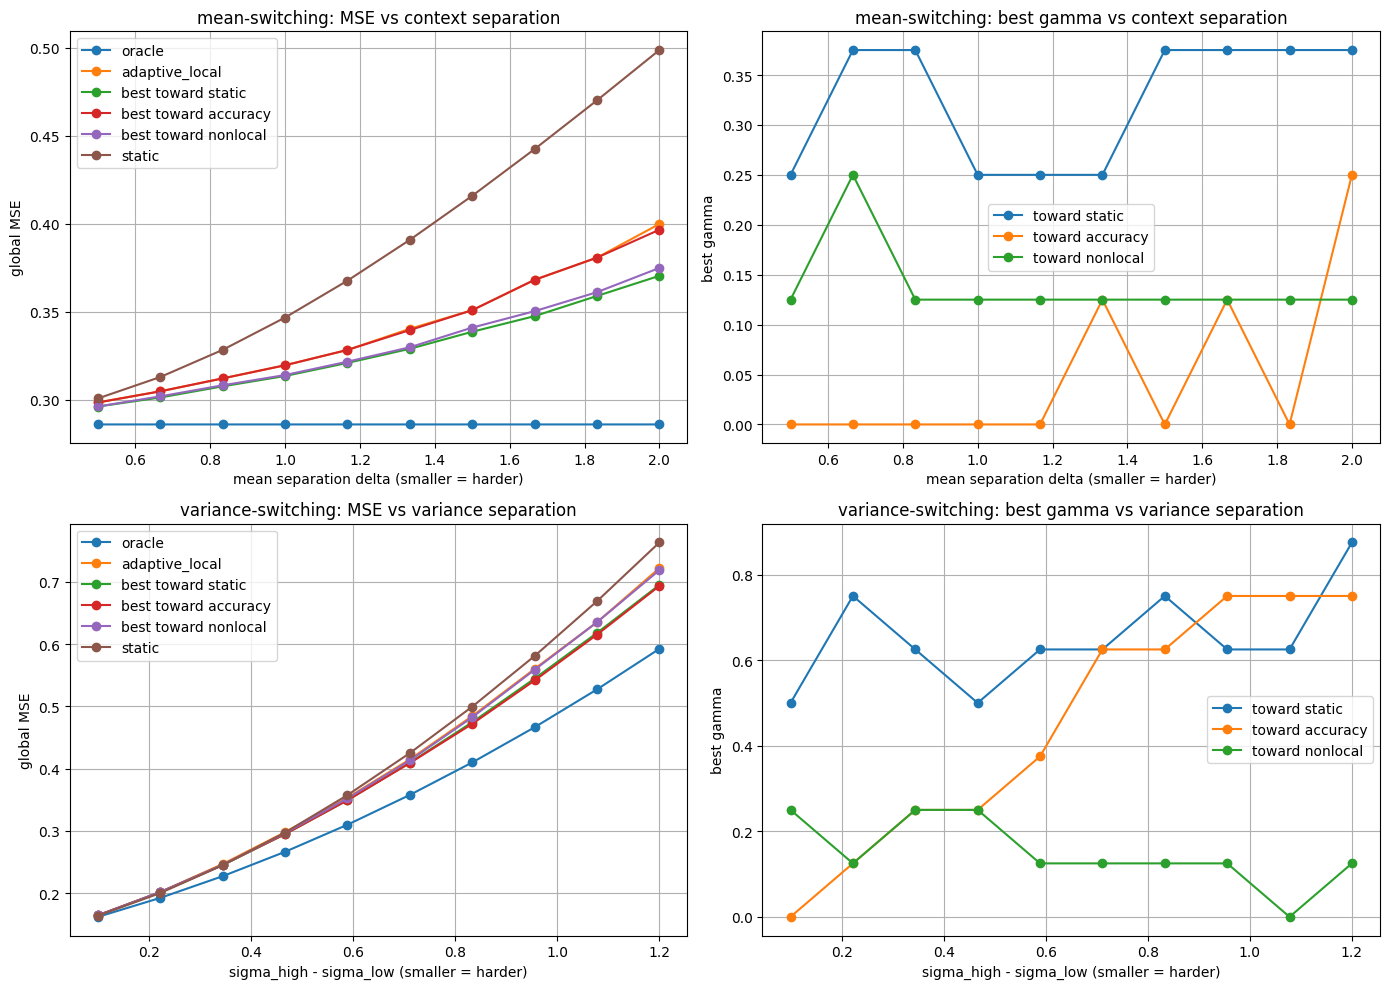

In [162]:
# ---------- separation plots: main result ----------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["oracle_mse"], marker="o", label="oracle")
axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["adaptive_local_mse"], marker="o", label="adaptive_local")
axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["best_static_mse"], marker="o", label="best toward static")
axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["best_acc_mse"], marker="o", label="best toward accuracy")
axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["best_nonlocal_mse"], marker="o", label="best toward nonlocal")
axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["static_mse"], marker="o", label="static")
axes[0, 0].set_title("mean-switching: MSE vs context separation")
axes[0, 0].set_xlabel("mean separation delta (smaller = harder)")
axes[0, 0].set_ylabel("global MSE")
axes[0, 0].legend()

axes[0, 1].plot(mean_sep_df["delta"], mean_sep_df["best_static_gamma"], marker="o", label="toward static")
axes[0, 1].plot(mean_sep_df["delta"], mean_sep_df["best_acc_gamma"], marker="o", label="toward accuracy")
axes[0, 1].plot(mean_sep_df["delta"], mean_sep_df["best_nonlocal_gamma"], marker="o", label="toward nonlocal")
axes[0, 1].set_title("mean-switching: best gamma vs context separation")
axes[0, 1].set_xlabel("mean separation delta (smaller = harder)")
axes[0, 1].set_ylabel("best gamma")
axes[0, 1].legend()

axes[1, 0].plot(var_sep_df["sigma_diff"], var_sep_df["oracle_mse"], marker="o", label="oracle")
axes[1, 0].plot(var_sep_df["sigma_diff"], var_sep_df["adaptive_local_mse"], marker="o", label="adaptive_local")
axes[1, 0].plot(var_sep_df["sigma_diff"], var_sep_df["best_static_mse"], marker="o", label="best toward static")
axes[1, 0].plot(var_sep_df["sigma_diff"], var_sep_df["best_acc_mse"], marker="o", label="best toward accuracy")
axes[1, 0].plot(var_sep_df["sigma_diff"], var_sep_df["best_nonlocal_mse"], marker="o", label="best toward nonlocal")
axes[1, 0].plot(var_sep_df["sigma_diff"], var_sep_df["static_mse"], marker="o", label="static")
axes[1, 0].set_title("variance-switching: MSE vs variance separation")
axes[1, 0].set_xlabel("sigma_high - sigma_low (smaller = harder)")
axes[1, 0].set_ylabel("global MSE")
axes[1, 0].legend()

axes[1, 1].plot(var_sep_df["sigma_diff"], var_sep_df["best_static_gamma"], marker="o", label="toward static")
axes[1, 1].plot(var_sep_df["sigma_diff"], var_sep_df["best_acc_gamma"], marker="o", label="toward accuracy")
axes[1, 1].plot(var_sep_df["sigma_diff"], var_sep_df["best_nonlocal_gamma"], marker="o", label="toward nonlocal")
axes[1, 1].set_title("variance-switching: best gamma vs variance separation")
axes[1, 1].set_xlabel("sigma_high - sigma_low (smaller = harder)")
axes[1, 1].set_ylabel("best gamma")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

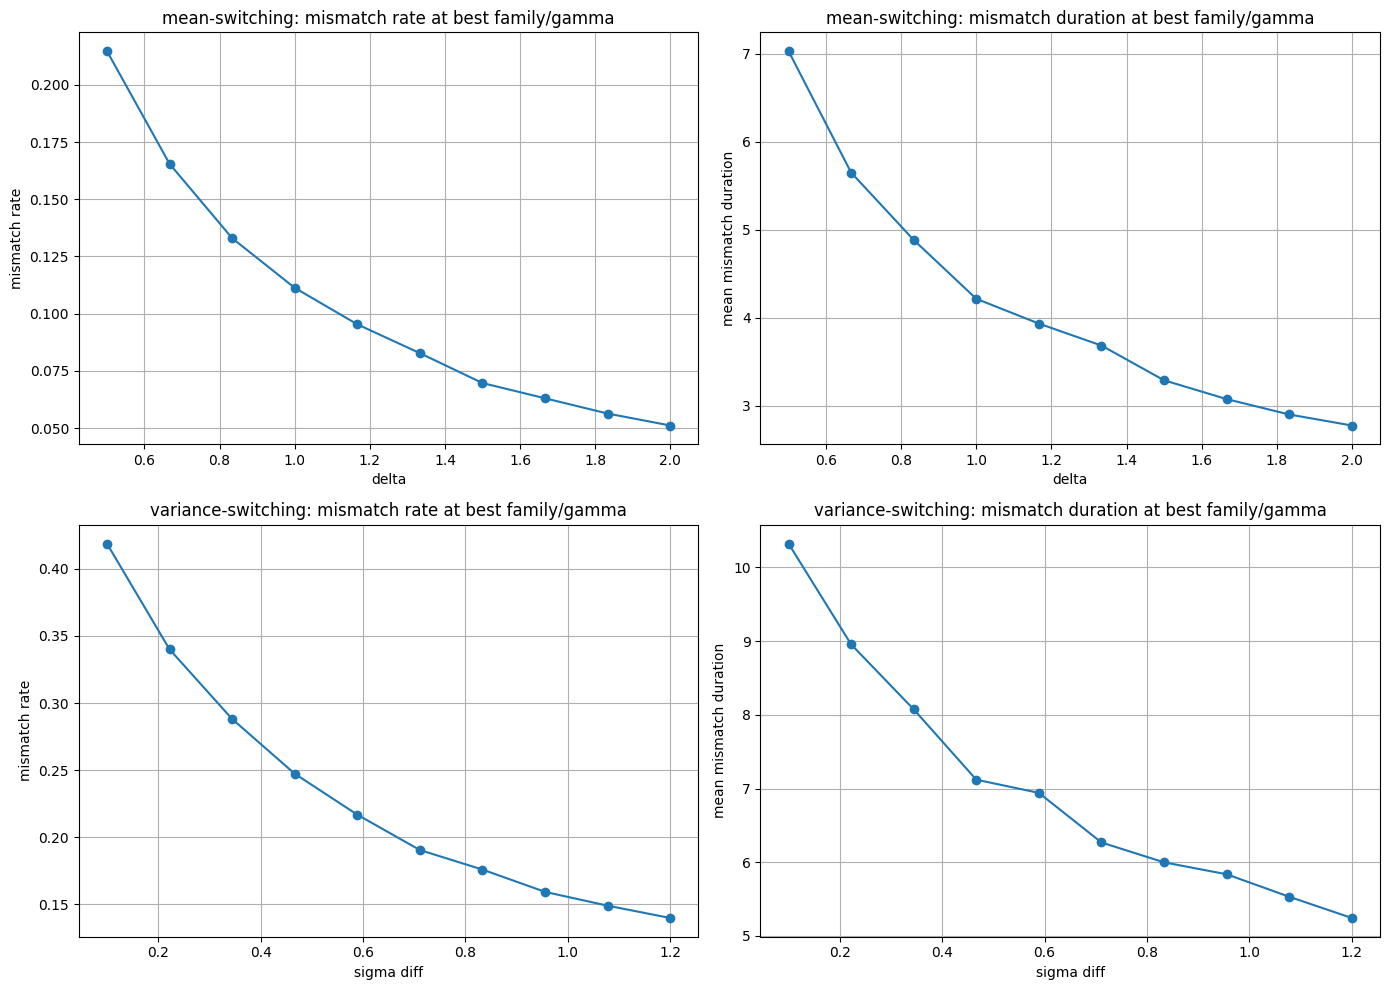

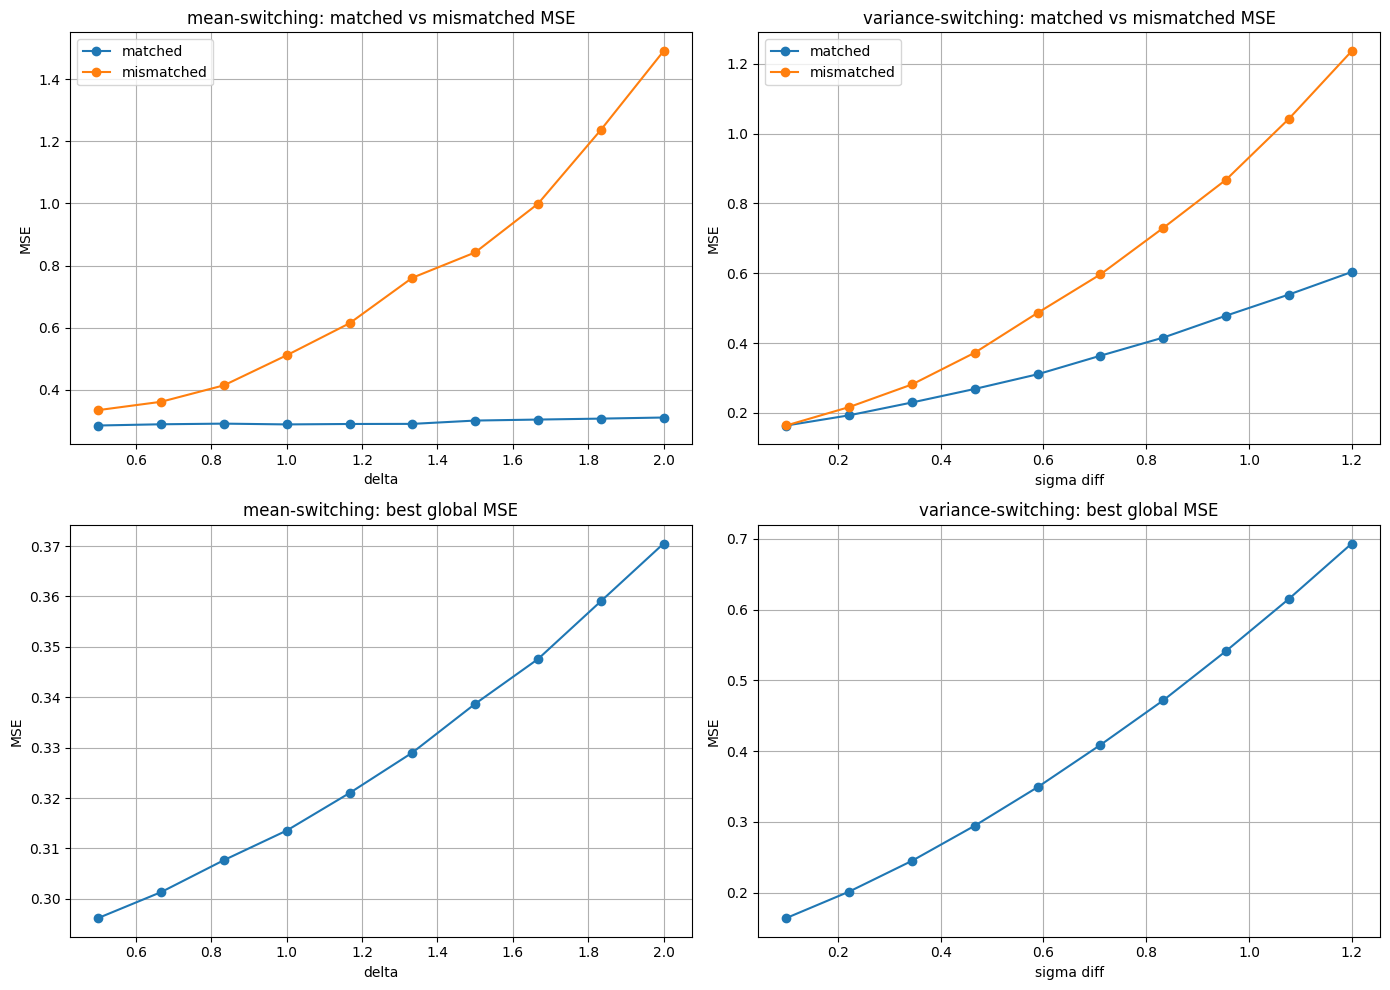

In [163]:
# ---------- separation plots: mechanism ----------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["best_mismatch_rate"], marker="o")
axes[0, 0].set_title("mean-switching: mismatch rate at best family/gamma")
axes[0, 0].set_xlabel("delta")
axes[0, 0].set_ylabel("mismatch rate")

axes[0, 1].plot(mean_sep_df["delta"], mean_sep_df["best_mean_mismatch_duration"], marker="o")
axes[0, 1].set_title("mean-switching: mismatch duration at best family/gamma")
axes[0, 1].set_xlabel("delta")
axes[0, 1].set_ylabel("mean mismatch duration")

axes[1, 0].plot(var_sep_df["sigma_diff"], var_sep_df["best_mismatch_rate"], marker="o")
axes[1, 0].set_title("variance-switching: mismatch rate at best family/gamma")
axes[1, 0].set_xlabel("sigma diff")
axes[1, 0].set_ylabel("mismatch rate")

axes[1, 1].plot(var_sep_df["sigma_diff"], var_sep_df["best_mean_mismatch_duration"], marker="o")
axes[1, 1].set_title("variance-switching: mismatch duration at best family/gamma")
axes[1, 1].set_xlabel("sigma diff")
axes[1, 1].set_ylabel("mean mismatch duration")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["best_matched_mse"], marker="o", label="matched")
axes[0, 0].plot(mean_sep_df["delta"], mean_sep_df["best_mismatched_mse"], marker="o", label="mismatched")
axes[0, 0].set_title("mean-switching: matched vs mismatched MSE")
axes[0, 0].set_xlabel("delta")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend()

axes[0, 1].plot(var_sep_df["sigma_diff"], var_sep_df["best_matched_mse"], marker="o", label="matched")
axes[0, 1].plot(var_sep_df["sigma_diff"], var_sep_df["best_mismatched_mse"], marker="o", label="mismatched")
axes[0, 1].set_title("variance-switching: matched vs mismatched MSE")
axes[0, 1].set_xlabel("sigma diff")
axes[0, 1].set_ylabel("MSE")
axes[0, 1].legend()

axes[1, 0].plot(mean_sep_df["delta"], mean_sep_df["best_global_mse"], marker="o")
axes[1, 0].set_title("mean-switching: best global MSE")
axes[1, 0].set_xlabel("delta")
axes[1, 0].set_ylabel("MSE")

axes[1, 1].plot(var_sep_df["sigma_diff"], var_sep_df["best_global_mse"], marker="o")
axes[1, 1].set_title("variance-switching: best global MSE")
axes[1, 1].set_xlabel("sigma diff")
axes[1, 1].set_ylabel("MSE")

plt.tight_layout()
plt.show()

In [164]:
# ---------- volatility sweeps using default environments ----------

p_switch_grid = np.array([0.0025, 0.005, 0.01, 0.02, 0.04, 0.08])

_, switch_summary_mean = sweep_switch_prob_one_neuron(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    infer_acc_params=infer_acc_params_mean,
    best_gamma_static=best_gamma_mean_static,
    best_gamma_infer_acc=best_gamma_mean_infer_acc,
    nonlocal_params=nonlocal_target_params_mean,
    best_gamma_nonlocal=best_gamma_mean_nonlocal,
    p_switch_grid=p_switch_grid,
)

_, switch_summary_var = sweep_switch_prob_one_neuron(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    infer_acc_params=infer_acc_params_var,
    best_gamma_static=best_gamma_var_static,
    best_gamma_infer_acc=best_gamma_var_infer_acc,
    nonlocal_params=nonlocal_target_params_var,
    best_gamma_nonlocal=best_gamma_var_nonlocal,
    p_switch_grid=p_switch_grid,
)

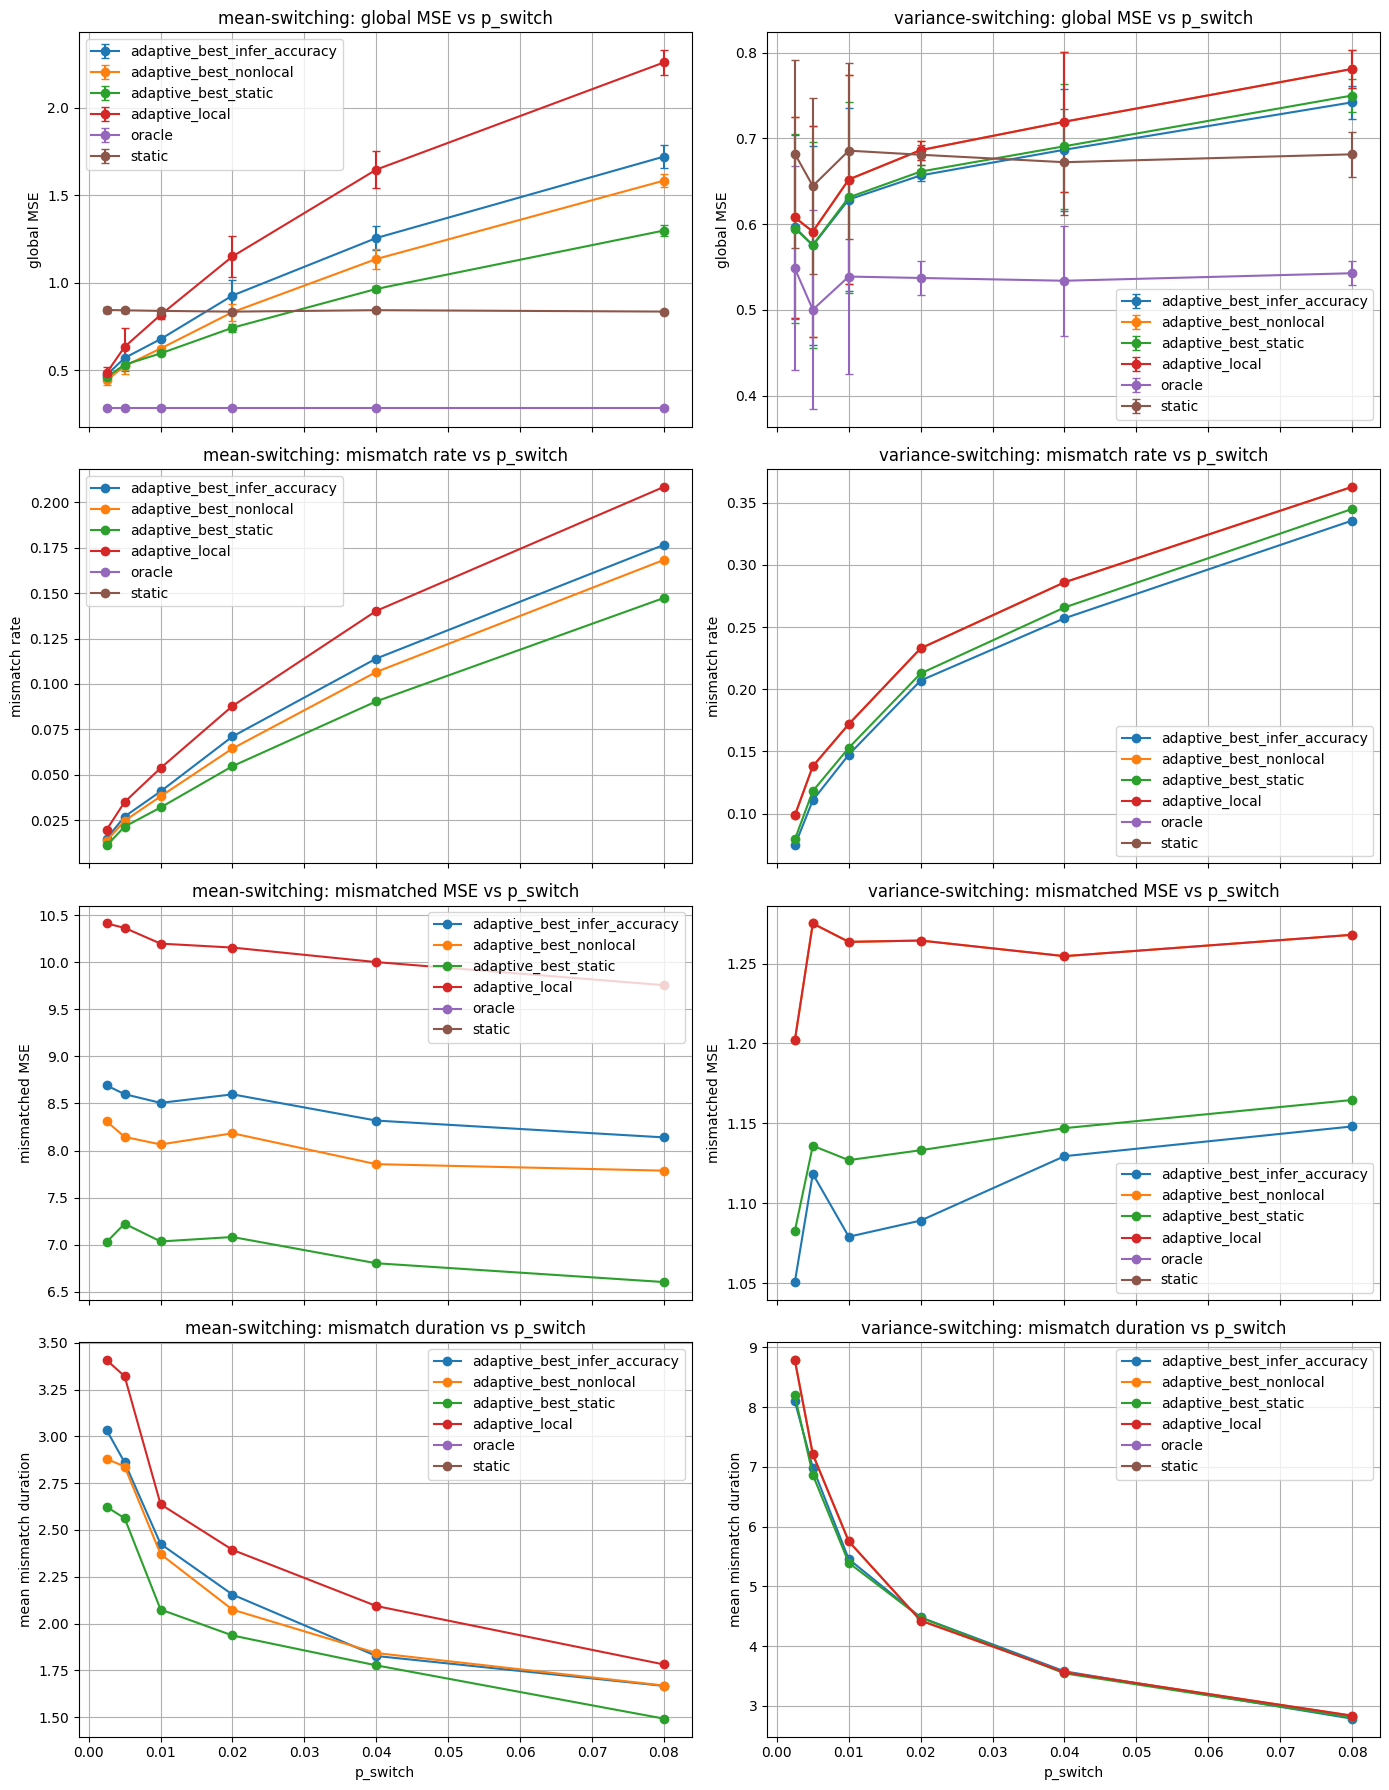

In [165]:
# ---------- volatility sweep plots ----------

fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True)

for strategy in switch_summary_mean["strategy"].unique():
    df_now = switch_summary_mean[switch_summary_mean["strategy"] == strategy]

    axes[0, 0].errorbar(
        df_now["p_switch"],
        df_now["global_mse_mean"],
        yerr=df_now["global_mse_std"],
        marker="o",
        capsize=3,
        label=strategy,
    )
    axes[1, 0].plot(df_now["p_switch"], df_now["mismatch_rate_mean"], marker="o", label=strategy)
    axes[2, 0].plot(df_now["p_switch"], df_now["mismatched_mse_mean"], marker="o", label=strategy)
    axes[3, 0].plot(df_now["p_switch"], df_now["mean_mismatch_duration_mean"], marker="o", label=strategy)

axes[0, 0].set_title("mean-switching: global MSE vs p_switch")
axes[0, 0].set_ylabel("global MSE")
axes[0, 0].legend()

axes[1, 0].set_title("mean-switching: mismatch rate vs p_switch")
axes[1, 0].set_ylabel("mismatch rate")
axes[1, 0].legend()

axes[2, 0].set_title("mean-switching: mismatched MSE vs p_switch")
axes[2, 0].set_ylabel("mismatched MSE")
axes[2, 0].legend()

axes[3, 0].set_title("mean-switching: mismatch duration vs p_switch")
axes[3, 0].set_xlabel("p_switch")
axes[3, 0].set_ylabel("mean mismatch duration")
axes[3, 0].legend()

for strategy in switch_summary_var["strategy"].unique():
    df_now = switch_summary_var[switch_summary_var["strategy"] == strategy]

    axes[0, 1].errorbar(
        df_now["p_switch"],
        df_now["global_mse_mean"],
        yerr=df_now["global_mse_std"],
        marker="o",
        capsize=3,
        label=strategy,
    )
    axes[1, 1].plot(df_now["p_switch"], df_now["mismatch_rate_mean"], marker="o", label=strategy)
    axes[2, 1].plot(df_now["p_switch"], df_now["mismatched_mse_mean"], marker="o", label=strategy)
    axes[3, 1].plot(df_now["p_switch"], df_now["mean_mismatch_duration_mean"], marker="o", label=strategy)

axes[0, 1].set_title("variance-switching: global MSE vs p_switch")
axes[0, 1].set_ylabel("global MSE")
axes[0, 1].legend()

axes[1, 1].set_title("variance-switching: mismatch rate vs p_switch")
axes[1, 1].set_ylabel("mismatch rate")
axes[1, 1].legend()

axes[2, 1].set_title("variance-switching: mismatched MSE vs p_switch")
axes[2, 1].set_ylabel("mismatched MSE")
axes[2, 1].legend()

axes[3, 1].set_title("variance-switching: mismatch duration vs p_switch")
axes[3, 1].set_xlabel("p_switch")
axes[3, 1].set_ylabel("mean mismatch duration")
axes[3, 1].legend()

plt.tight_layout()
plt.show()

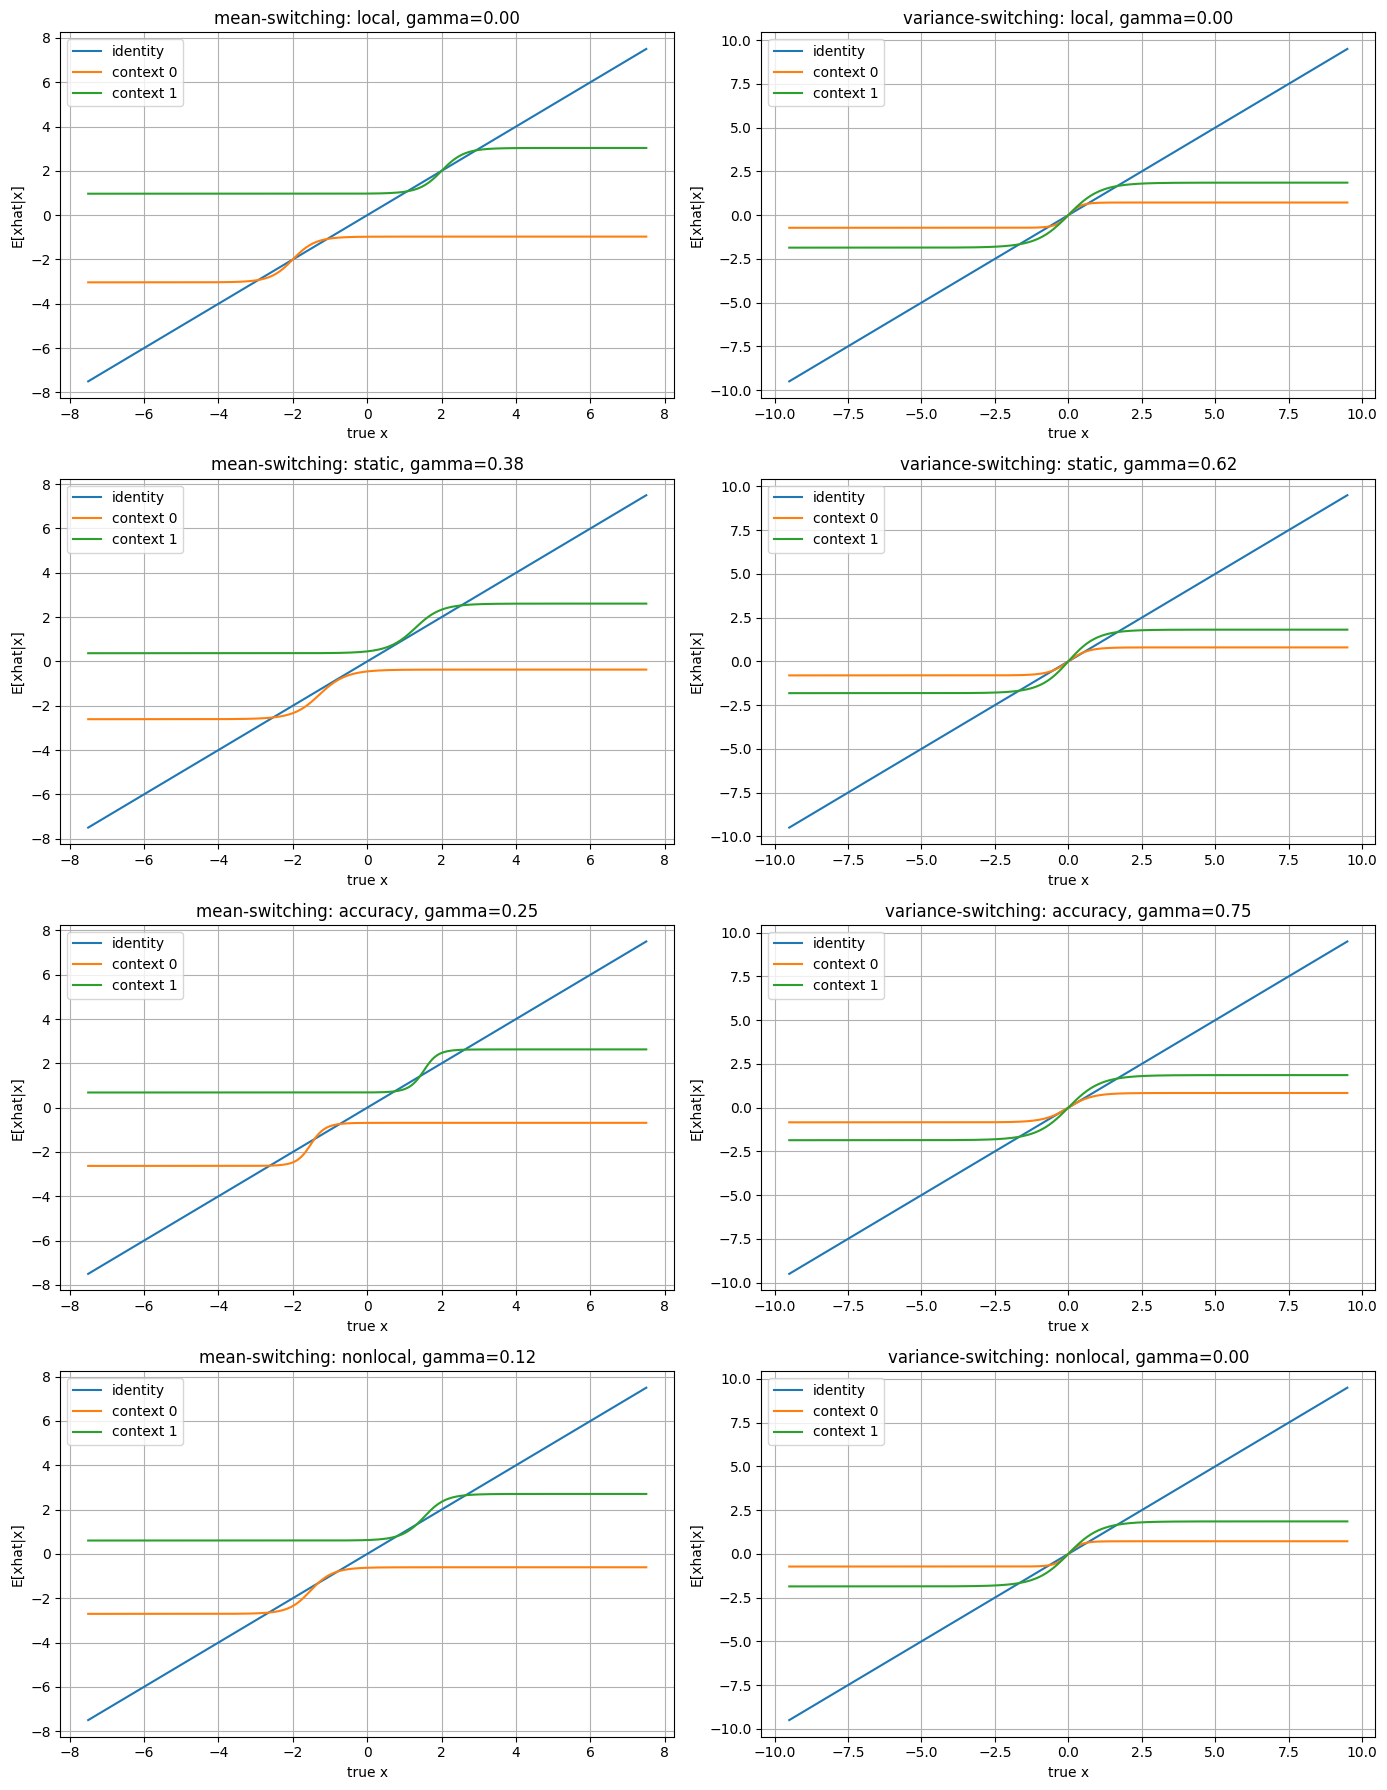

In [166]:
# ---------- optional distortion plots ----------

def decoded_curve_set(contexts, x_grid, local_params, target_params, gamma_now):
    family_params = make_family_params(local_params, target_params, gamma_now)
    out = {}
    for k in contexts:
        stats = posterior_stats_one_neuron(
            context=contexts[k],
            a=family_params[k][0],
            b=family_params[k][1],
            x_grid=x_grid,
        )
        out[k] = decoded_mean_given_x_from_stats(stats)
    return out


mean_target_specs = [
    ("local", static_params_mean, 0.0),
    ("static", static_params_mean, best_gamma_mean_static),
    ("accuracy", infer_acc_params_mean, best_gamma_mean_infer_acc),
    ("nonlocal", nonlocal_target_params_mean, best_gamma_mean_nonlocal),
]

var_target_specs = [
    ("local", static_params_var, 0.0),
    ("static", static_params_var, best_gamma_var_static),
    ("accuracy", infer_acc_params_var, best_gamma_var_infer_acc),
    ("nonlocal", nonlocal_target_params_var, best_gamma_var_nonlocal),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for row_idx, (label, target_params, gamma_now) in enumerate(mean_target_specs):
    dec = decoded_curve_set(contexts_mean_default, x_grid_mean, local_params_mean, target_params, gamma_now)
    axes[row_idx, 0].plot(dec[0]["x_grid"], dec[0]["x_grid"], label="identity")
    axes[row_idx, 0].plot(dec[0]["x_grid"], dec[0]["decoded_mean_given_x"], label="context 0")
    axes[row_idx, 0].plot(dec[1]["x_grid"], dec[1]["decoded_mean_given_x"], label="context 1")
    axes[row_idx, 0].set_title(f"mean-switching: {label}, gamma={gamma_now:.2f}")
    axes[row_idx, 0].set_xlabel("true x")
    axes[row_idx, 0].set_ylabel("E[xhat|x]")
    axes[row_idx, 0].legend()

for row_idx, (label, target_params, gamma_now) in enumerate(var_target_specs):
    dec = decoded_curve_set(contexts_var_default, x_grid_var, local_params_var, target_params, gamma_now)
    axes[row_idx, 1].plot(dec[0]["x_grid"], dec[0]["x_grid"], label="identity")
    axes[row_idx, 1].plot(dec[0]["x_grid"], dec[0]["decoded_mean_given_x"], label="context 0")
    axes[row_idx, 1].plot(dec[1]["x_grid"], dec[1]["decoded_mean_given_x"], label="context 1")
    axes[row_idx, 1].set_title(f"variance-switching: {label}, gamma={gamma_now:.2f}")
    axes[row_idx, 1].set_xlabel("true x")
    axes[row_idx, 1].set_ylabel("E[xhat|x]")
    axes[row_idx, 1].legend()

plt.tight_layout()
plt.show()

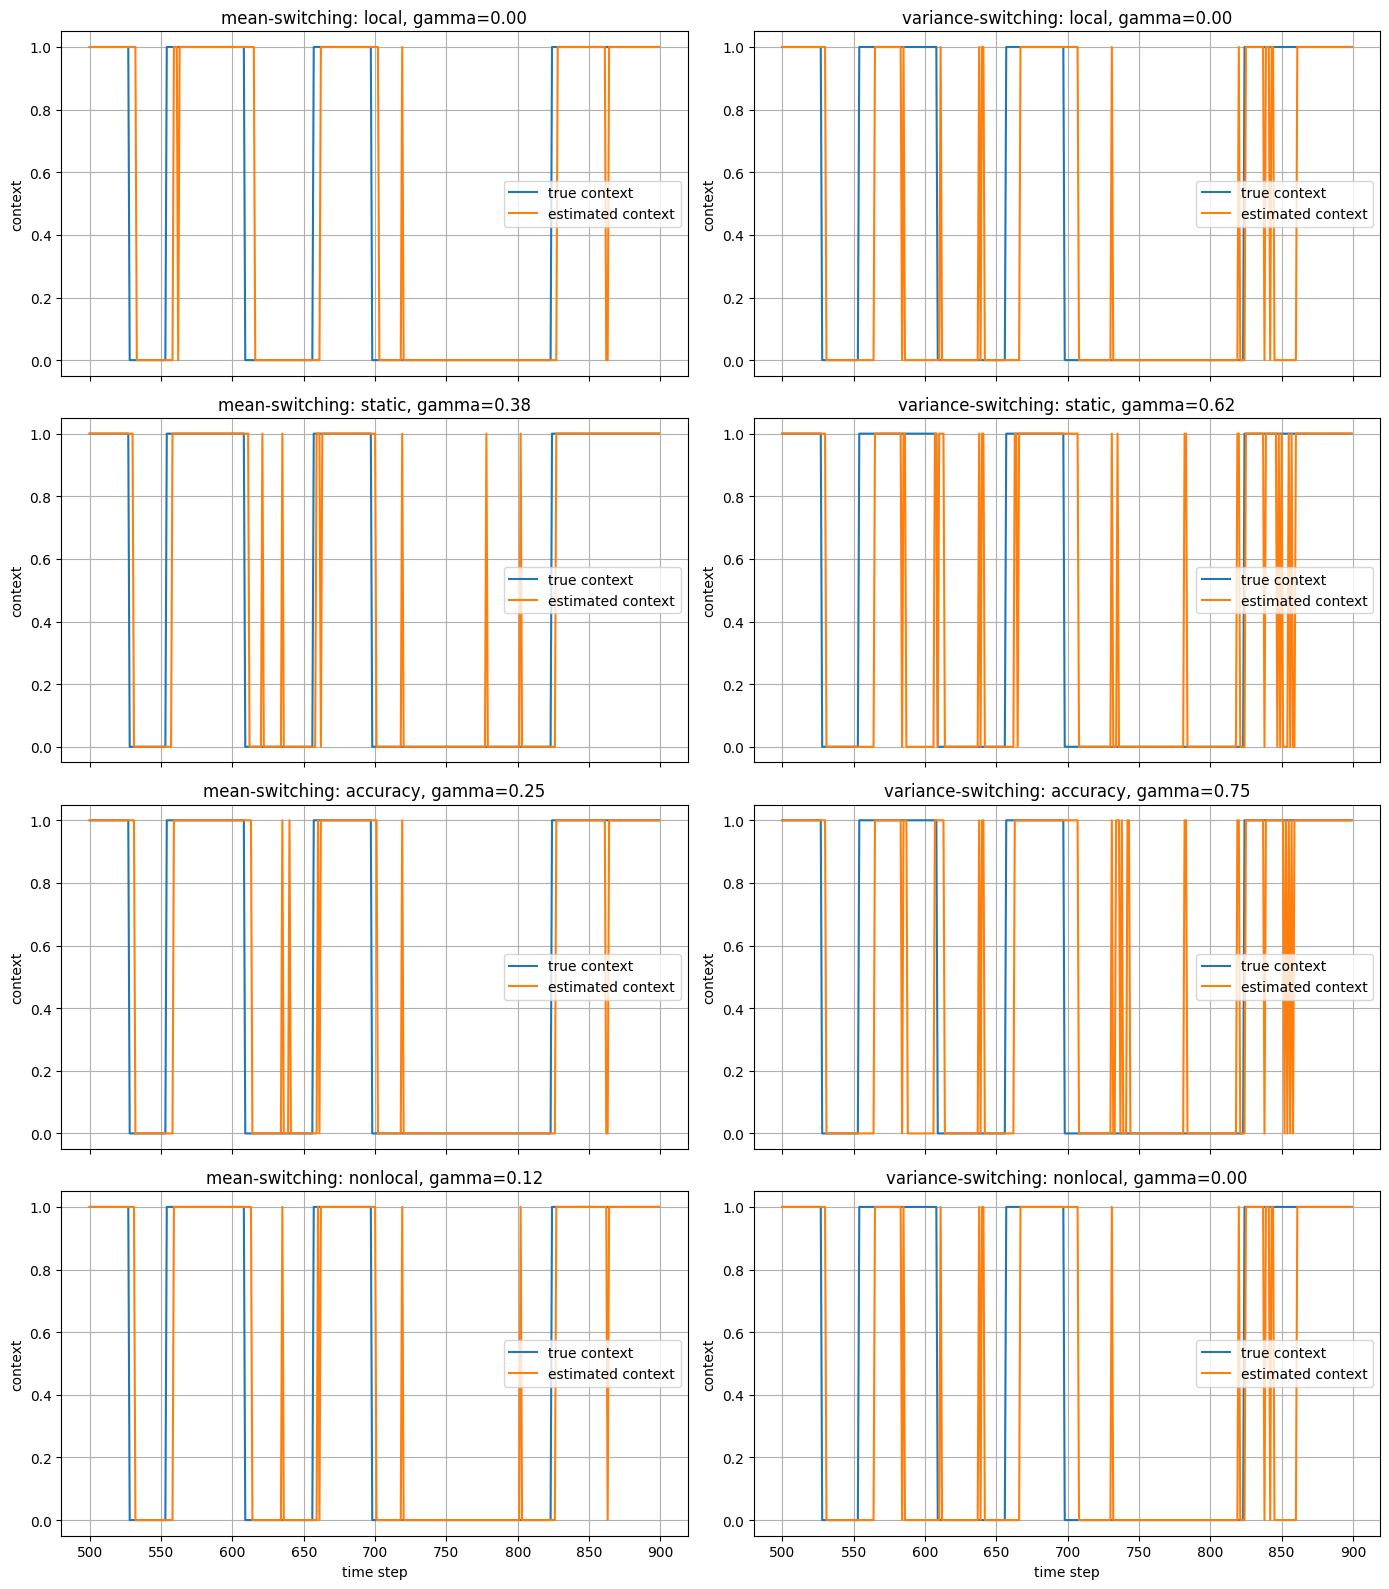

In [167]:
# ---------- optional adaptive traces ----------

trace_specs_mean = [
    ("local", static_params_mean, 0.0),
    ("static", static_params_mean, best_gamma_mean_static),
    ("accuracy", infer_acc_params_mean, best_gamma_mean_infer_acc),
    ("nonlocal", nonlocal_target_params_mean, best_gamma_mean_nonlocal),
]

trace_specs_var = [
    ("local", static_params_var, 0.0),
    ("static", static_params_var, best_gamma_var_static),
    ("accuracy", infer_acc_params_var, best_gamma_var_infer_acc),
    ("nonlocal", nonlocal_target_params_var, best_gamma_var_nonlocal),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
show_slice = slice(500, 900)

for row_idx, (label, target_params, gamma_now) in enumerate(trace_specs_mean):
    out = run_strategy_one_neuron(
        strategy_name="adaptive",
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        target_params=target_params,
        gamma=gamma_now,
        p_switch=p_switch_main,
        seed=123,
    )
    df = out["df"].iloc[show_slice]
    axes[row_idx, 0].plot(df["t"], df["true_context"], label="true context")
    axes[row_idx, 0].plot(df["t"], df["estimated_context"], label="estimated context")
    axes[row_idx, 0].set_title(f"mean-switching: {label}, gamma={gamma_now:.2f}")
    axes[row_idx, 0].set_ylabel("context")
    axes[row_idx, 0].legend()

for row_idx, (label, target_params, gamma_now) in enumerate(trace_specs_var):
    out = run_strategy_one_neuron(
        strategy_name="adaptive",
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        target_params=target_params,
        gamma=gamma_now,
        p_switch=p_switch_main,
        seed=123,
    )
    df = out["df"].iloc[show_slice]
    axes[row_idx, 1].plot(df["t"], df["true_context"], label="true context")
    axes[row_idx, 1].plot(df["t"], df["estimated_context"], label="estimated context")
    axes[row_idx, 1].set_title(f"variance-switching: {label}, gamma={gamma_now:.2f}")
    axes[row_idx, 1].set_ylabel("context")
    axes[row_idx, 1].legend()

axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")

plt.tight_layout()
plt.show()

In [168]:
# ---------- final summary helper: retune best family/gamma by switching mode ----------

def tune_families_for_mode(
    contexts,
    x_grid,
    local_params,
    static_params,
    infer_acc_params,
    nonlocal_params,
    gamma_grid=gamma_grid,
    p_switch=p_switch_main,
    seeds=seed_list,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
    adaptation_mode="instant",
    tau_low=0.35,
    tau_high=0.65,
    refractory_length=0,
):
    _, summary_static = sweep_gamma_one_neuron(
        contexts=contexts,
        x_grid=x_grid,
        local_params=local_params,
        static_params=static_params,
        target_params=static_params,
        family_name="toward static",
        gamma_grid=gamma_grid,
        p_switch=p_switch,
        seeds=seeds,
        n_steps=n_steps,
        burn_in=burn_in,
        response_sd=response_sd,
        adaptation_mode=adaptation_mode,
        tau_low=tau_low,
        tau_high=tau_high,
        refractory_length=refractory_length,
    )

    _, summary_acc = sweep_gamma_one_neuron(
        contexts=contexts,
        x_grid=x_grid,
        local_params=local_params,
        static_params=static_params,
        target_params=infer_acc_params,
        family_name="toward accuracy",
        gamma_grid=gamma_grid,
        p_switch=p_switch,
        seeds=seeds,
        n_steps=n_steps,
        burn_in=burn_in,
        response_sd=response_sd,
        adaptation_mode=adaptation_mode,
        tau_low=tau_low,
        tau_high=tau_high,
        refractory_length=refractory_length,
    )

    _, summary_nonlocal = sweep_gamma_one_neuron(
        contexts=contexts,
        x_grid=x_grid,
        local_params=local_params,
        static_params=static_params,
        target_params=nonlocal_params,
        family_name="toward nonlocal",
        gamma_grid=gamma_grid,
        p_switch=p_switch,
        seeds=seeds,
        n_steps=n_steps,
        burn_in=burn_in,
        response_sd=response_sd,
        adaptation_mode=adaptation_mode,
        tau_low=tau_low,
        tau_high=tau_high,
        refractory_length=refractory_length,
    )

    best_static_gamma, best_static_mse = best_gamma_from_summary(summary_static)
    best_acc_gamma, best_acc_mse = best_gamma_from_summary(summary_acc)
    best_nonlocal_gamma, best_nonlocal_mse = best_gamma_from_summary(summary_nonlocal)

    candidates = [
        ("toward static", best_static_gamma, best_static_mse, static_params),
        ("toward accuracy", best_acc_gamma, best_acc_mse, infer_acc_params),
        ("toward nonlocal", best_nonlocal_gamma, best_nonlocal_mse, nonlocal_params),
    ]
    best_family, best_gamma, best_family_mse, best_target_params = min(candidates, key=lambda z: z[2])

    family_params_best = make_family_params(local_params, best_target_params, best_gamma)

    return {
        "summary_static": summary_static,
        "summary_acc": summary_acc,
        "summary_nonlocal": summary_nonlocal,
        "best_static_gamma": best_static_gamma,
        "best_static_mse": best_static_mse,
        "best_acc_gamma": best_acc_gamma,
        "best_acc_mse": best_acc_mse,
        "best_nonlocal_gamma": best_nonlocal_gamma,
        "best_nonlocal_mse": best_nonlocal_mse,
        "best_family": best_family,
        "best_gamma": best_gamma,
        "best_family_mse": best_family_mse,
        "best_target_params": best_target_params,
        "best_family_params": family_params_best,
    }

In [170]:
# ---------- final summary tables by switching mode ----------

mode_specs = [
    ("baseline", "instant", tau_low_default, tau_high_default, 0),
    ("hysteresis", "hysteresis", tau_low_default, tau_high_default, 0),
    ("refractory", "refractory", tau_low_default, tau_high_default, refractory_default),
    ("both", "both", tau_low_default, tau_high_default, refractory_default),
]

final_mode_results_mean = {}
final_mode_results_var = {}

rows_mean = []
rows_var = []

for mode_label, adaptation_mode_now, tau_low_now, tau_high_now, refractory_now in mode_specs:
    tune_mean = tune_families_for_mode(
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        infer_acc_params=infer_acc_params_mean,
        nonlocal_params=nonlocal_target_params_mean,
        adaptation_mode=adaptation_mode_now,
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
    )
    final_mode_results_mean[mode_label] = tune_mean

    rows_mean.append({
        "mode": mode_label,
        "best_family": tune_mean["best_family"],
        "best_gamma": tune_mean["best_gamma"],
        "best_global_mse": tune_mean["best_family_mse"],
        "best_static_gamma": tune_mean["best_static_gamma"],
        "best_acc_gamma": tune_mean["best_acc_gamma"],
        "best_nonlocal_gamma": tune_mean["best_nonlocal_gamma"],
        "best_static_mse": tune_mean["best_static_mse"],
        "best_acc_mse": tune_mean["best_acc_mse"],
        "best_nonlocal_mse": tune_mean["best_nonlocal_mse"],
        "a_context0": tune_mean["best_family_params"][0][0],
        "b_context0": tune_mean["best_family_params"][0][1],
        "a_context1": tune_mean["best_family_params"][1][0],
        "b_context1": tune_mean["best_family_params"][1][1],
    })

    tune_var = tune_families_for_mode(
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        infer_acc_params=infer_acc_params_var,
        nonlocal_params=nonlocal_target_params_var,
        adaptation_mode=adaptation_mode_now,
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
    )
    final_mode_results_var[mode_label] = tune_var

    rows_var.append({
        "mode": mode_label,
        "best_family": tune_var["best_family"],
        "best_gamma": tune_var["best_gamma"],
        "best_global_mse": tune_var["best_family_mse"],
        "best_static_gamma": tune_var["best_static_gamma"],
        "best_acc_gamma": tune_var["best_acc_gamma"],
        "best_nonlocal_gamma": tune_var["best_nonlocal_gamma"],
        "best_static_mse": tune_var["best_static_mse"],
        "best_acc_mse": tune_var["best_acc_mse"],
        "best_nonlocal_mse": tune_var["best_nonlocal_mse"],
        "a_context0": tune_var["best_family_params"][0][0],
        "b_context0": tune_var["best_family_params"][0][1],
        "a_context1": tune_var["best_family_params"][1][0],
        "b_context1": tune_var["best_family_params"][1][1],
    })

final_mode_summary_mean = pd.DataFrame(rows_mean)
final_mode_summary_var = pd.DataFrame(rows_var)

display(final_mode_summary_mean)
display(final_mode_summary_var)

,mode,best_family,best_gamma,best_global_mse,best_static_gamma,best_acc_gamma,best_nonlocal_gamma,best_static_mse,best_acc_mse,best_nonlocal_mse,a_context0,b_context0,a_context1,b_context1
0,baseline,toward static,0.375,0.596021,0.375,0.250,0.125,0.596021,0.677768,0.623817,2.320701,-1.249990,2.320721,1.25
1,hysteresis,toward static,0.375,0.602572,0.375,0.250,0.125,0.602572,0.672248,0.628417,2.320701,-1.249990,2.320721,1.25
2,refractory,toward static,0.500,0.704517,0.500,0.375,0.125,0.704517,0.797377,0.727987,2.162716,-0.999992,2.162731,1.00
3,both,toward static,0.250,0.663045,0.250,0.250,0.125,0.663045,0.724712,0.675280,2.478687,-1.499988,2.478710,1.50


,mode,best_family,best_gamma,best_global_mse,best_static_gamma,best_acc_gamma,best_nonlocal_gamma,best_static_mse,best_acc_mse,best_nonlocal_mse,a_context0,b_context0,a_context1,b_context1
0,baseline,toward accuracy,0.750,0.628668,0.625,0.750,0.000,0.631120,0.628668,0.651979,2.152807,1.842976e-14,1.542850,2.775647e-15
1,hysteresis,toward accuracy,0.750,0.630875,0.750,0.750,0.125,0.632352,0.630875,0.654555,2.152807,1.842976e-14,1.542850,2.775647e-15
2,refractory,toward accuracy,0.625,0.637604,0.625,0.625,0.000,0.641208,0.637604,0.656676,2.459413,2.586828e-14,1.544479,2.387117e-15
3,both,toward accuracy,0.750,0.631012,0.750,0.750,0.000,0.633074,0.631012,0.654334,2.152807,1.842976e-14,1.542850,2.775647e-15


,env,mode,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean-switching,baseline,0.053722,2.637157,10.199162
1,variance-switching,baseline,0.171944,5.753751,1.263547
2,mean-switching,hysteresis,0.053833,4.149864,9.989200
3,variance-switching,hysteresis,0.174944,13.678285,1.286346
4,mean-switching,refractory,0.066444,4.680088,9.969866
5,variance-switching,refractory,0.181722,9.324535,1.240511
6,mean-switching,both,0.059722,4.899513,9.843549
7,variance-switching,both,0.176833,14.070858,1.264924


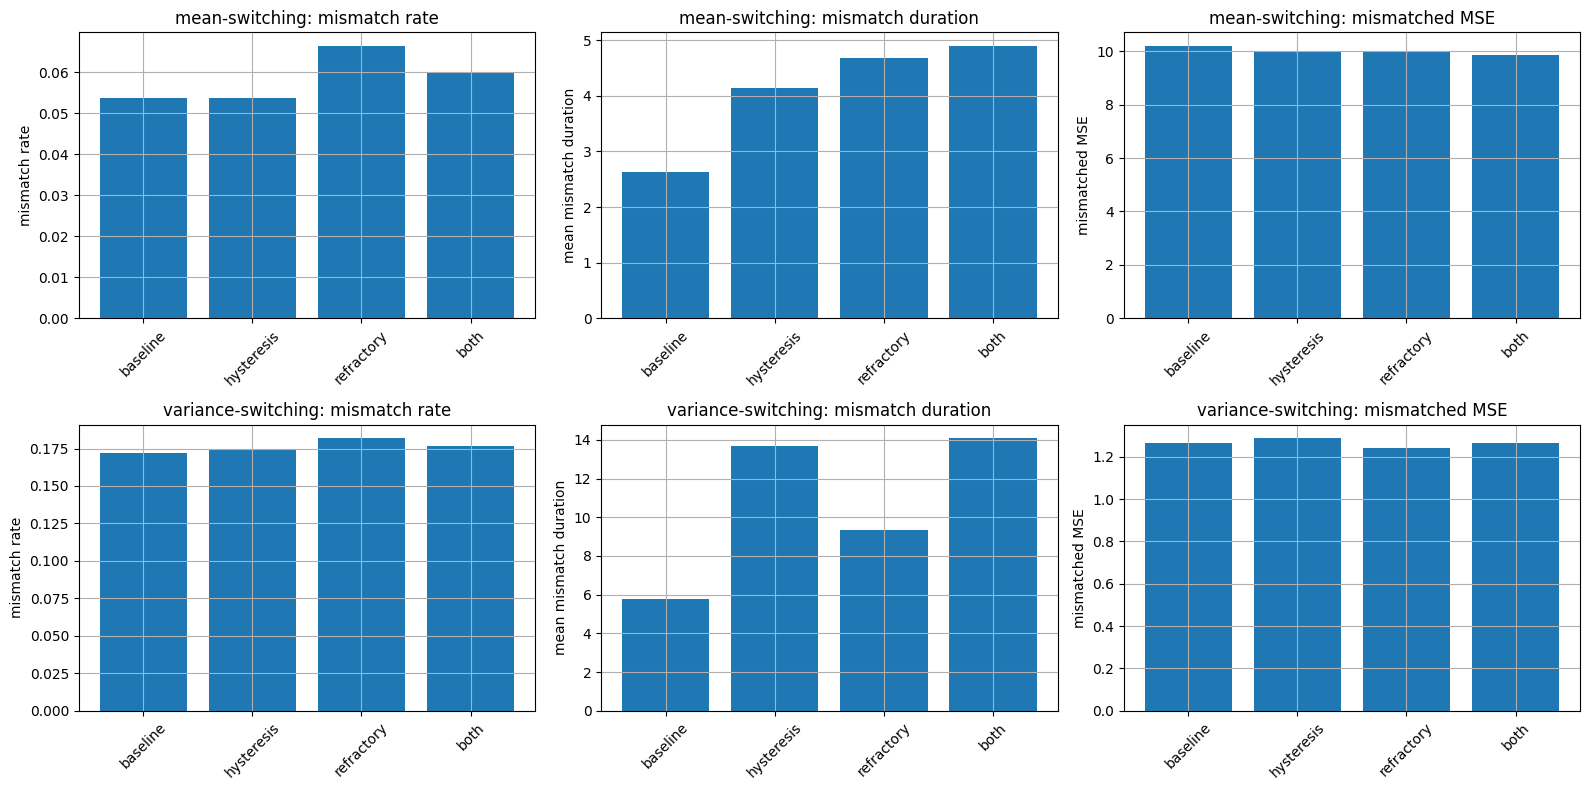

In [171]:
# ---------- final figure block 1: constraint fingerprints ----------

def extract_local_row(summary_df):
    return summary_df[summary_df["strategy"] == "adaptive_local"].iloc[0]

constraint_rows = []

for mode_label, adaptation_mode_now, tau_low_now, tau_high_now, refractory_now in mode_specs:
    _, mean_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        infer_acc_params=infer_acc_params_mean,
        best_gamma_static=best_gamma_mean_static,
        best_gamma_infer_acc=best_gamma_mean_infer_acc,
        nonlocal_params=nonlocal_target_params_mean,
        best_gamma_nonlocal=best_gamma_mean_nonlocal,
        adaptation_mode=adaptation_mode_now,
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
    )

    _, var_summary_now = evaluate_strategy_set_one_neuron(
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        infer_acc_params=infer_acc_params_var,
        best_gamma_static=best_gamma_var_static,
        best_gamma_infer_acc=best_gamma_var_infer_acc,
        nonlocal_params=nonlocal_target_params_var,
        best_gamma_nonlocal=best_gamma_var_nonlocal,
        adaptation_mode=adaptation_mode_now,
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
    )

    mean_local = extract_local_row(mean_summary_now)
    var_local = extract_local_row(var_summary_now)

    constraint_rows.append({
        "env": "mean-switching",
        "mode": mode_label,
        "mismatch_rate": mean_local["mismatch_rate_mean"],
        "mean_mismatch_duration": mean_local["mean_mismatch_duration_mean"],
        "mismatched_mse": mean_local["mismatched_mse_mean"],
    })
    constraint_rows.append({
        "env": "variance-switching",
        "mode": mode_label,
        "mismatch_rate": var_local["mismatch_rate_mean"],
        "mean_mismatch_duration": var_local["mean_mismatch_duration_mean"],
        "mismatched_mse": var_local["mismatched_mse_mean"],
    })

constraint_fingerprint_df = pd.DataFrame(constraint_rows)
display(constraint_fingerprint_df)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, env_name in enumerate(["mean-switching", "variance-switching"]):
    df_now = constraint_fingerprint_df[constraint_fingerprint_df["env"] == env_name]

    axes[row_idx, 0].bar(df_now["mode"], df_now["mismatch_rate"])
    axes[row_idx, 0].set_title(f"{env_name}: mismatch rate")
    axes[row_idx, 0].set_ylabel("mismatch rate")
    axes[row_idx, 0].tick_params(axis="x", rotation=45)

    axes[row_idx, 1].bar(df_now["mode"], df_now["mean_mismatch_duration"])
    axes[row_idx, 1].set_title(f"{env_name}: mismatch duration")
    axes[row_idx, 1].set_ylabel("mean mismatch duration")
    axes[row_idx, 1].tick_params(axis="x", rotation=45)

    axes[row_idx, 2].bar(df_now["mode"], df_now["mismatched_mse"])
    axes[row_idx, 2].set_title(f"{env_name}: mismatched MSE")
    axes[row_idx, 2].set_ylabel("mismatched MSE")
    axes[row_idx, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

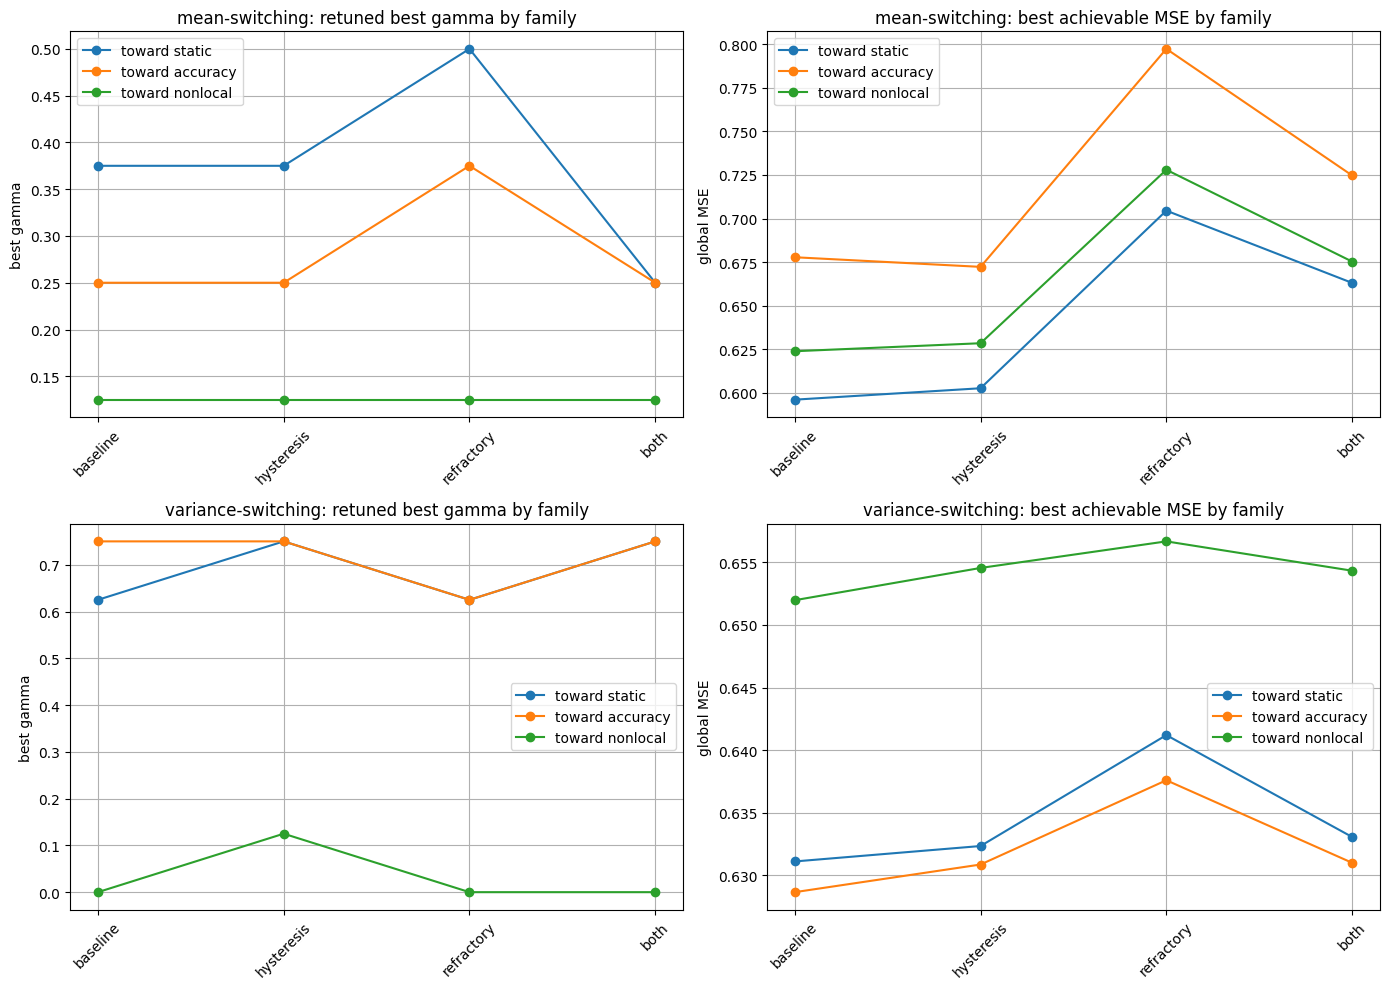

Winning family by mode — mean-switching


,mode,best_family,best_gamma,best_global_mse
0,baseline,toward static,0.375,0.596021
1,hysteresis,toward static,0.375,0.602572
2,refractory,toward static,0.500,0.704517
3,both,toward static,0.250,0.663045


Winning family by mode — variance-switching


,mode,best_family,best_gamma,best_global_mse
0,baseline,toward accuracy,0.750,0.628668
1,hysteresis,toward accuracy,0.750,0.630875
2,refractory,toward accuracy,0.625,0.637604
3,both,toward accuracy,0.750,0.631012


In [172]:
# ---------- final figure block 2: optimal bias shifts under switching constraints ----------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# mean-switching
axes[0, 0].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["best_static_gamma"], marker="o", label="toward static")
axes[0, 0].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["best_acc_gamma"], marker="o", label="toward accuracy")
axes[0, 0].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["best_nonlocal_gamma"], marker="o", label="toward nonlocal")
axes[0, 0].set_title("mean-switching: retuned best gamma by family")
axes[0, 0].set_ylabel("best gamma")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()

axes[0, 1].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["best_static_mse"], marker="o", label="toward static")
axes[0, 1].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["best_acc_mse"], marker="o", label="toward accuracy")
axes[0, 1].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["best_nonlocal_mse"], marker="o", label="toward nonlocal")
axes[0, 1].set_title("mean-switching: best achievable MSE by family")
axes[0, 1].set_ylabel("global MSE")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend()

# variance-switching
axes[1, 0].plot(final_mode_summary_var["mode"], final_mode_summary_var["best_static_gamma"], marker="o", label="toward static")
axes[1, 0].plot(final_mode_summary_var["mode"], final_mode_summary_var["best_acc_gamma"], marker="o", label="toward accuracy")
axes[1, 0].plot(final_mode_summary_var["mode"], final_mode_summary_var["best_nonlocal_gamma"], marker="o", label="toward nonlocal")
axes[1, 0].set_title("variance-switching: retuned best gamma by family")
axes[1, 0].set_ylabel("best gamma")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend()

axes[1, 1].plot(final_mode_summary_var["mode"], final_mode_summary_var["best_static_mse"], marker="o", label="toward static")
axes[1, 1].plot(final_mode_summary_var["mode"], final_mode_summary_var["best_acc_mse"], marker="o", label="toward accuracy")
axes[1, 1].plot(final_mode_summary_var["mode"], final_mode_summary_var["best_nonlocal_mse"], marker="o", label="toward nonlocal")
axes[1, 1].set_title("variance-switching: best achievable MSE by family")
axes[1, 1].set_ylabel("global MSE")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Winning family by mode — mean-switching")
display(final_mode_summary_mean[["mode", "best_family", "best_gamma", "best_global_mse"]])

print("Winning family by mode — variance-switching")
display(final_mode_summary_var[["mode", "best_family", "best_gamma", "best_global_mse"]])

,env,mode,matched_mse,mismatched_mse,mismatch_rate,mean_mismatch_duration
0,mean-switching,baseline,0.373779,6.165957,0.024889,2.074074
1,variance-switching,baseline,0.606567,1.073483,0.107111,4.342342
2,mean-switching,hysteresis,0.372655,6.460359,0.024667,2.581395
3,variance-switching,hysteresis,0.612054,0.968212,0.104000,9.176471
4,mean-switching,refractory,0.443032,5.241797,0.038889,3.723404
5,variance-switching,refractory,0.601804,1.116758,0.127556,7.972222
6,mean-switching,both,0.318164,7.555528,0.040222,4.209302
7,variance-switching,both,0.612137,0.966298,0.105556,9.693878


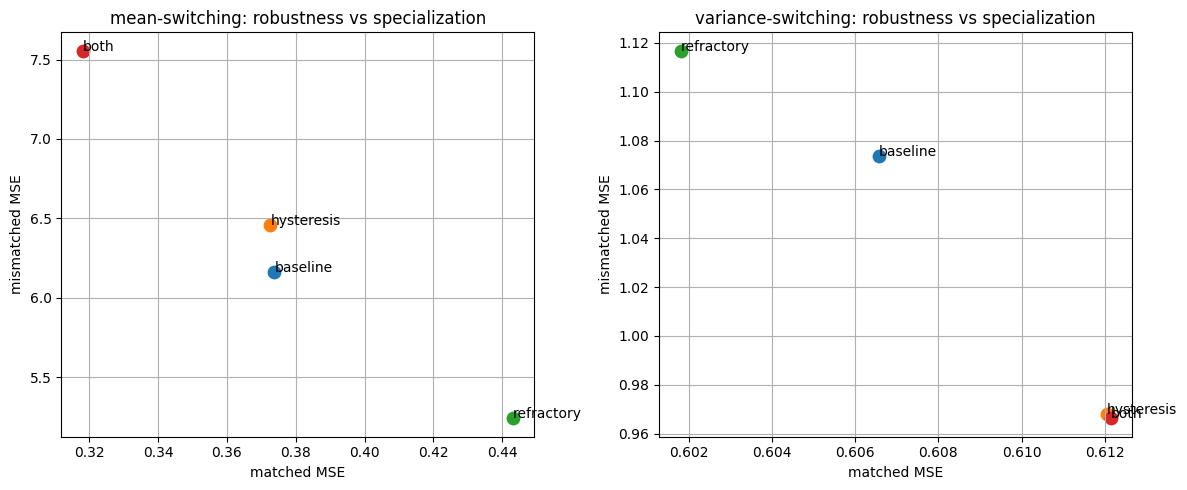

In [173]:
# ---------- final figure block 3: robustness vs specialization tradeoff ----------

tradeoff_rows = []

for mode_label, adaptation_mode_now, tau_low_now, tau_high_now, refractory_now in mode_specs:
    tune_mean = final_mode_results_mean[mode_label]
    tune_var = final_mode_results_var[mode_label]

    mean_out = run_strategy_one_neuron(
        strategy_name="adaptive",
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        target_params=tune_mean["best_target_params"],
        gamma=tune_mean["best_gamma"],
        p_switch=p_switch_main,
        adaptation_mode=adaptation_mode_now,
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
        seed=123,
    )

    var_out = run_strategy_one_neuron(
        strategy_name="adaptive",
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        target_params=tune_var["best_target_params"],
        gamma=tune_var["best_gamma"],
        p_switch=p_switch_main,
        adaptation_mode=adaptation_mode_now,
        tau_low=tau_low_now,
        tau_high=tau_high_now,
        refractory_length=refractory_now,
        seed=123,
    )

    tradeoff_rows.append({
        "env": "mean-switching",
        "mode": mode_label,
        "matched_mse": mean_out["matched_mse"],
        "mismatched_mse": mean_out["mismatched_mse"],
        "mismatch_rate": mean_out["mismatch_rate"],
        "mean_mismatch_duration": mean_out["mean_mismatch_duration"],
    })
    tradeoff_rows.append({
        "env": "variance-switching",
        "mode": mode_label,
        "matched_mse": var_out["matched_mse"],
        "mismatched_mse": var_out["mismatched_mse"],
        "mismatch_rate": var_out["mismatch_rate"],
        "mean_mismatch_duration": var_out["mean_mismatch_duration"],
    })

tradeoff_df = pd.DataFrame(tradeoff_rows)
display(tradeoff_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, env_name in zip(axes, ["mean-switching", "variance-switching"]):
    df_now = tradeoff_df[tradeoff_df["env"] == env_name]

    for _, row in df_now.iterrows():
        ax.scatter(row["matched_mse"], row["mismatched_mse"], s=80)
        ax.text(row["matched_mse"], row["mismatched_mse"], row["mode"])

    ax.set_title(f"{env_name}: robustness vs specialization")
    ax.set_xlabel("matched MSE")
    ax.set_ylabel("mismatched MSE")

plt.tight_layout()
plt.show()

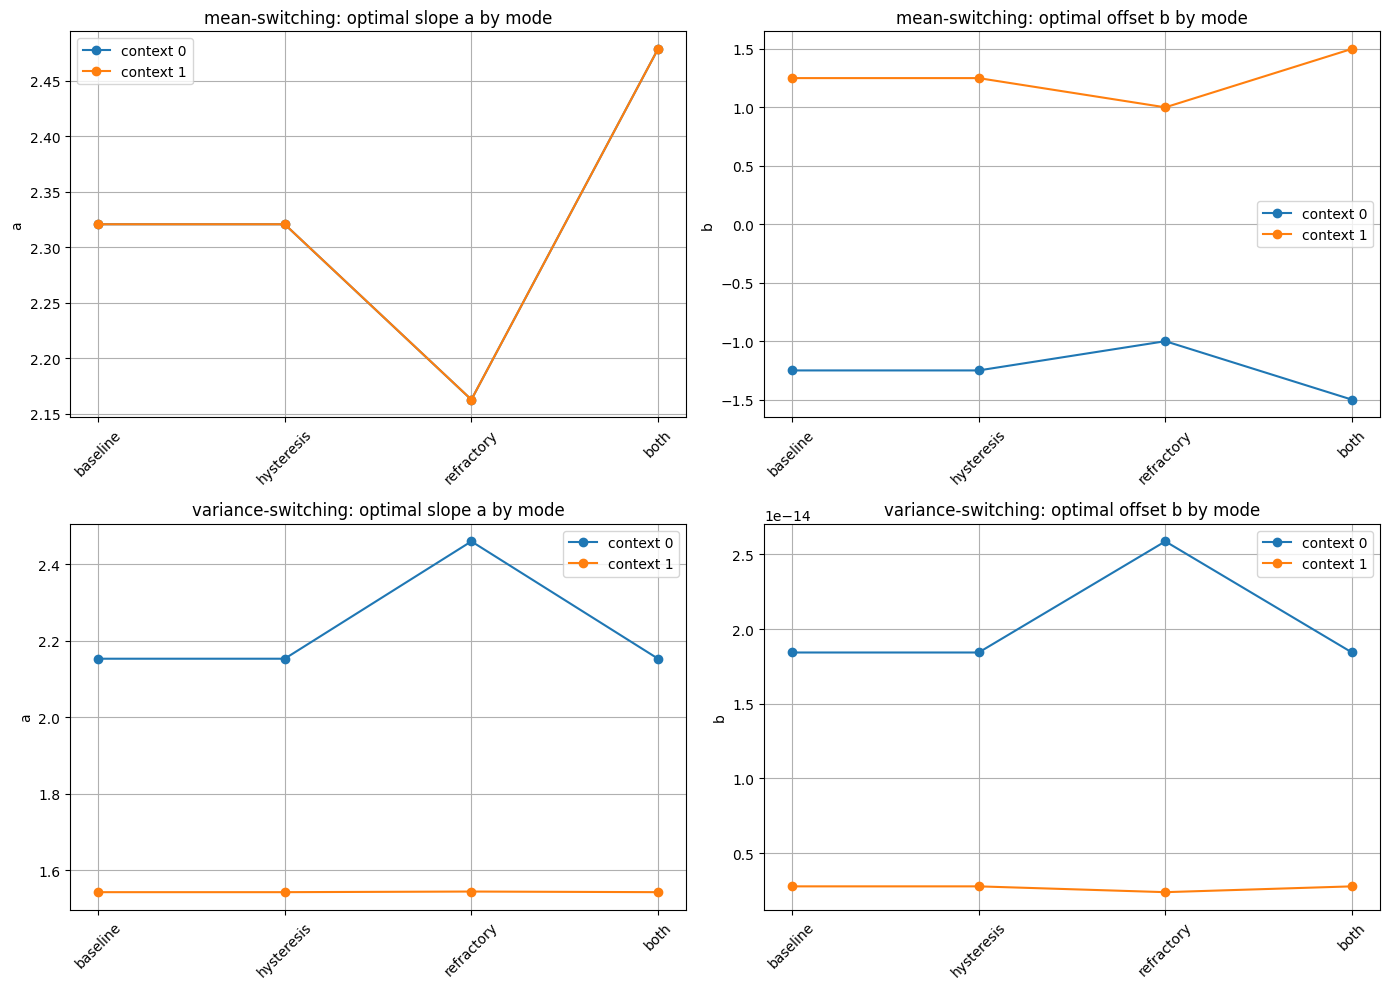

In [174]:
# ---------- optional final figure: optimal parameter shifts by mode ----------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# mean-switching
axes[0, 0].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["a_context0"], marker="o", label="context 0")
axes[0, 0].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["a_context1"], marker="o", label="context 1")
axes[0, 0].set_title("mean-switching: optimal slope a by mode")
axes[0, 0].set_ylabel("a")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()

axes[0, 1].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["b_context0"], marker="o", label="context 0")
axes[0, 1].plot(final_mode_summary_mean["mode"], final_mode_summary_mean["b_context1"], marker="o", label="context 1")
axes[0, 1].set_title("mean-switching: optimal offset b by mode")
axes[0, 1].set_ylabel("b")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend()

# variance-switching
axes[1, 0].plot(final_mode_summary_var["mode"], final_mode_summary_var["a_context0"], marker="o", label="context 0")
axes[1, 0].plot(final_mode_summary_var["mode"], final_mode_summary_var["a_context1"], marker="o", label="context 1")
axes[1, 0].set_title("variance-switching: optimal slope a by mode")
axes[1, 0].set_ylabel("a")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend()

axes[1, 1].plot(final_mode_summary_var["mode"], final_mode_summary_var["b_context0"], marker="o", label="context 0")
axes[1, 1].plot(final_mode_summary_var["mode"], final_mode_summary_var["b_context1"], marker="o", label="context 1")
axes[1, 1].set_title("variance-switching: optimal offset b by mode")
axes[1, 1].set_ylabel("b")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [175]:
# ---------- mixed sweep setup ----------

mixed_env_configs = {
    "mean": {
        "weak": {
            "contexts": make_mean_contexts(delta=0.75, sigma=1.0),
            "label": "mean-switching",
        },
        "strong": {
            "contexts": make_mean_contexts(delta=2.0, sigma=1.0),
            "label": "mean-switching",
        },
    },
    "variance": {
        "weak": {
            "contexts": make_variance_contexts(sigma_low=0.9, sigma_high=1.4),
            "label": "variance-switching",
        },
        "strong": {
            "contexts": make_variance_contexts(sigma_low=0.7, sigma_high=1.8),
            "label": "variance-switching",
        },
    },
}

mixed_mode_configs = {
    "instant": {
        "adaptation_mode": "instant",
        "tau_low": 0.35,
        "tau_high": 0.65,
        "refractory_length": 0,
    },
    "hysteresis": {
        "adaptation_mode": "hysteresis",
        "tau_low": 0.35,
        "tau_high": 0.65,
        "refractory_length": 0,
    },
    "refractory": {
        "adaptation_mode": "refractory",
        "tau_low": 0.35,
        "tau_high": 0.65,
        "refractory_length": 20,
    },
}

In [176]:
# ---------- run mixed sweep ----------

rows = []

for env_type, separation_dict in mixed_env_configs.items():
    for separation, env_cfg in separation_dict.items():
        contexts_now = env_cfg["contexts"]

        fit_now = fit_codebook_for_contexts(contexts_now)
        x_grid_now = fit_now["x_grid"]
        local_params_now = fit_now["local_params"]
        static_params_now = fit_now["static_params"]

        for mode, mode_cfg in mixed_mode_configs.items():
            seed_rows = []

            for seed_now in seed_list:
                out = run_strategy_one_neuron(
                    strategy_name="adaptive",
                    contexts=contexts_now,
                    x_grid=x_grid_now,
                    local_params=local_params_now,
                    static_params=static_params_now,
                    target_params=static_params_now,
                    gamma=0.0,
                    p_switch=p_switch_main,
                    n_steps=n_steps_main,
                    burn_in=burn_in_main,
                    response_sd=response_sd_default,
                    seed=seed_now,
                    adaptation_mode=mode_cfg["adaptation_mode"],
                    tau_low=mode_cfg["tau_low"],
                    tau_high=mode_cfg["tau_high"],
                    refractory_length=mode_cfg["refractory_length"],
                )

                seed_rows.append({
                    "global_mse": out["global_mse"],
                    "mismatch_rate": out["mismatch_rate"],
                    "mean_mismatch_duration": out["mean_mismatch_duration"],
                    "mismatched_mse": out["mismatched_mse"],
                })

            seed_df = pd.DataFrame(seed_rows)

            rows.append({
                "env_type": env_type,
                "separation": separation,
                "mode": mode,
                "global_mse": seed_df["global_mse"].mean(),
                "mismatch_rate": seed_df["mismatch_rate"].mean(),
                "mean_mismatch_duration": seed_df["mean_mismatch_duration"].mean(),
                "mismatched_mse": seed_df["mismatched_mse"].mean(),
            })

mixed_sweep_df = pd.DataFrame(rows)
mixed_sweep_df["mode"] = pd.Categorical(
    mixed_sweep_df["mode"],
    categories=["instant", "hysteresis", "refractory"],
    ordered=True,
)

display(mixed_sweep_df)

,env_type,separation,mode,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean,weak,instant,0.308685,0.153889,5.359288,0.431259
1,mean,weak,hysteresis,0.308830,0.155722,11.481170,0.432581
2,mean,weak,refractory,0.318473,0.215611,15.100784,0.445366
3,mean,strong,instant,0.399940,0.066056,2.904561,2.029937
4,mean,strong,hysteresis,0.395658,0.066667,4.887883,1.968785
5,mean,strong,refractory,0.516779,0.139444,10.574504,1.960502
6,variance,weak,instant,0.436798,0.275500,7.352447,0.534432
7,variance,weak,hysteresis,0.438757,0.284778,27.503071,0.540450
8,variance,weak,refractory,0.440138,0.308778,19.958531,0.525850
9,variance,strong,instant,0.651979,0.171944,5.753751,1.263547


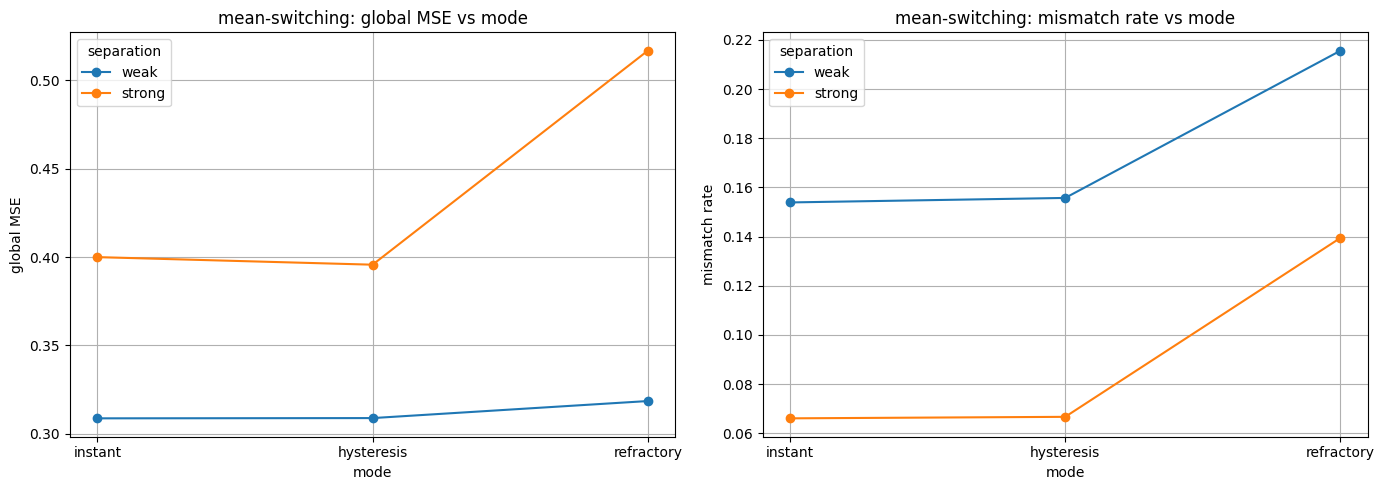

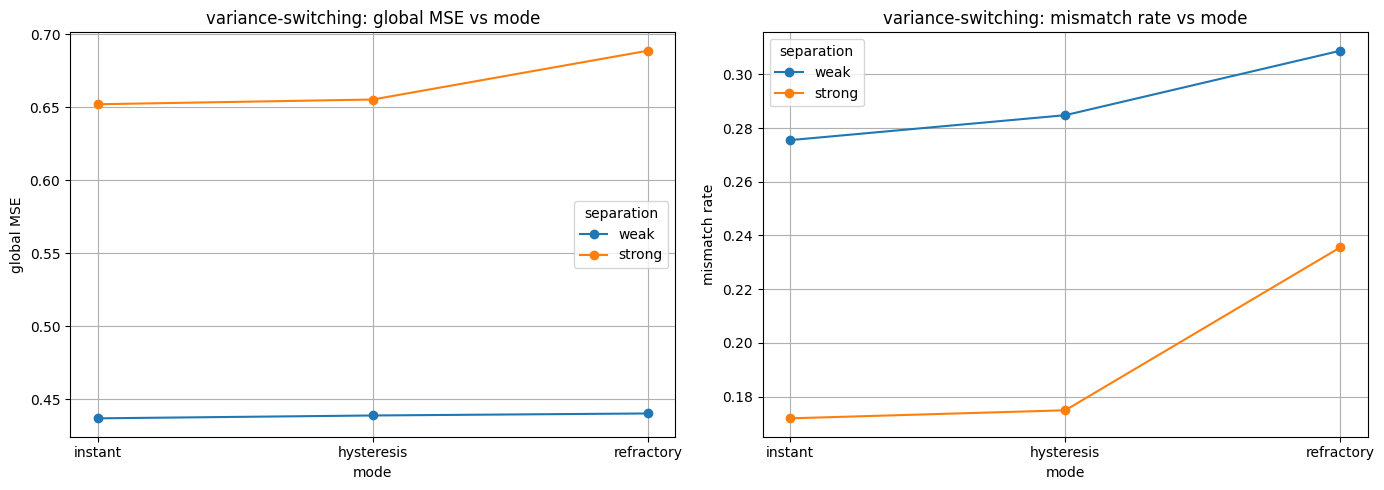

In [177]:
# ---------- plot mixed sweep results ----------

for env_type in ["mean", "variance"]:
    df_env = mixed_sweep_df[mixed_sweep_df["env_type"] == env_type].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for separation in ["weak", "strong"]:
        df_sep = (
            df_env[df_env["separation"] == separation]
            .sort_values("mode")
        )

        axes[0].plot(
            df_sep["mode"],
            df_sep["global_mse"],
            marker="o",
            label=separation,
        )

        axes[1].plot(
            df_sep["mode"],
            df_sep["mismatch_rate"],
            marker="o",
            label=separation,
        )

    axes[0].set_title(f"{env_type}-switching: global MSE vs mode")
    axes[0].set_xlabel("mode")
    axes[0].set_ylabel("global MSE")
    axes[0].legend(title="separation")

    axes[1].set_title(f"{env_type}-switching: mismatch rate vs mode")
    axes[1].set_xlabel("mode")
    axes[1].set_ylabel("mismatch rate")
    axes[1].legend(title="separation")

    plt.tight_layout()
    plt.show()

In [179]:
# ---------- final optional summary: retuned family/gamma by switching mode ----------

mode_rows = []

mode_specs_small = [
    ("instant", "instant", tau_low_default, tau_high_default, 0),
    ("hysteresis", "hysteresis", tau_low_default, tau_high_default, 0),
    ("refractory", "refractory", tau_low_default, tau_high_default, refractory_default),
]

env_specs_small = [
    (
        "mean-switching",
        contexts_mean_default,
        x_grid_mean,
        local_params_mean,
        static_params_mean,
        infer_acc_params_mean,
        nonlocal_target_params_mean,
    ),
    (
        "variance-switching",
        contexts_var_default,
        x_grid_var,
        local_params_var,
        static_params_var,
        infer_acc_params_var,
        nonlocal_target_params_var,
    ),
]

for (
    env_name,
    contexts_now,
    x_grid_now,
    local_params_now,
    static_params_now,
    infer_acc_params_now,
    nonlocal_params_now,
) in env_specs_small:
    for mode_label, adaptation_mode_now, tau_low_now, tau_high_now, refractory_now in mode_specs_small:
        bests = tune_families_for_mode(
            contexts=contexts_now,
            x_grid=x_grid_now,
            local_params=local_params_now,
            static_params=static_params_now,
            infer_acc_params=infer_acc_params_now,
            nonlocal_params=nonlocal_params_now,
            adaptation_mode=adaptation_mode_now,
            tau_low=tau_low_now,
            tau_high=tau_high_now,
            refractory_length=refractory_now,
        )

        mode_rows.append({
            "env": env_name,
            "mode": mode_label,
            "best_family": bests["best_family"],
            "best_gamma": bests["best_gamma"],
            "best_global_mse": bests["best_family_mse"],
            "best_static_gamma": bests["best_static_gamma"],
            "best_acc_gamma": bests["best_acc_gamma"],
            "best_nonlocal_gamma": bests["best_nonlocal_gamma"],
            "best_static_mse": bests["best_static_mse"],
            "best_acc_mse": bests["best_acc_mse"],
            "best_nonlocal_mse": bests["best_nonlocal_mse"],
        })

mode_gamma_df = pd.DataFrame(mode_rows)
display(mode_gamma_df)

,env,mode,best_family,best_gamma,best_global_mse,best_static_gamma,best_acc_gamma,best_nonlocal_gamma,best_static_mse,best_acc_mse,best_nonlocal_mse
0,mean-switching,instant,toward static,0.375,0.596021,0.375,0.250,0.125,0.596021,0.677768,0.623817
1,mean-switching,hysteresis,toward static,0.375,0.602572,0.375,0.250,0.125,0.602572,0.672248,0.628417
2,mean-switching,refractory,toward static,0.500,0.704517,0.500,0.375,0.125,0.704517,0.797377,0.727987
3,variance-switching,instant,toward accuracy,0.750,0.628668,0.625,0.750,0.000,0.631120,0.628668,0.651979
4,variance-switching,hysteresis,toward accuracy,0.750,0.630875,0.750,0.750,0.125,0.632352,0.630875,0.654555
5,variance-switching,refractory,toward accuracy,0.625,0.637604,0.625,0.625,0.000,0.641208,0.637604,0.656676


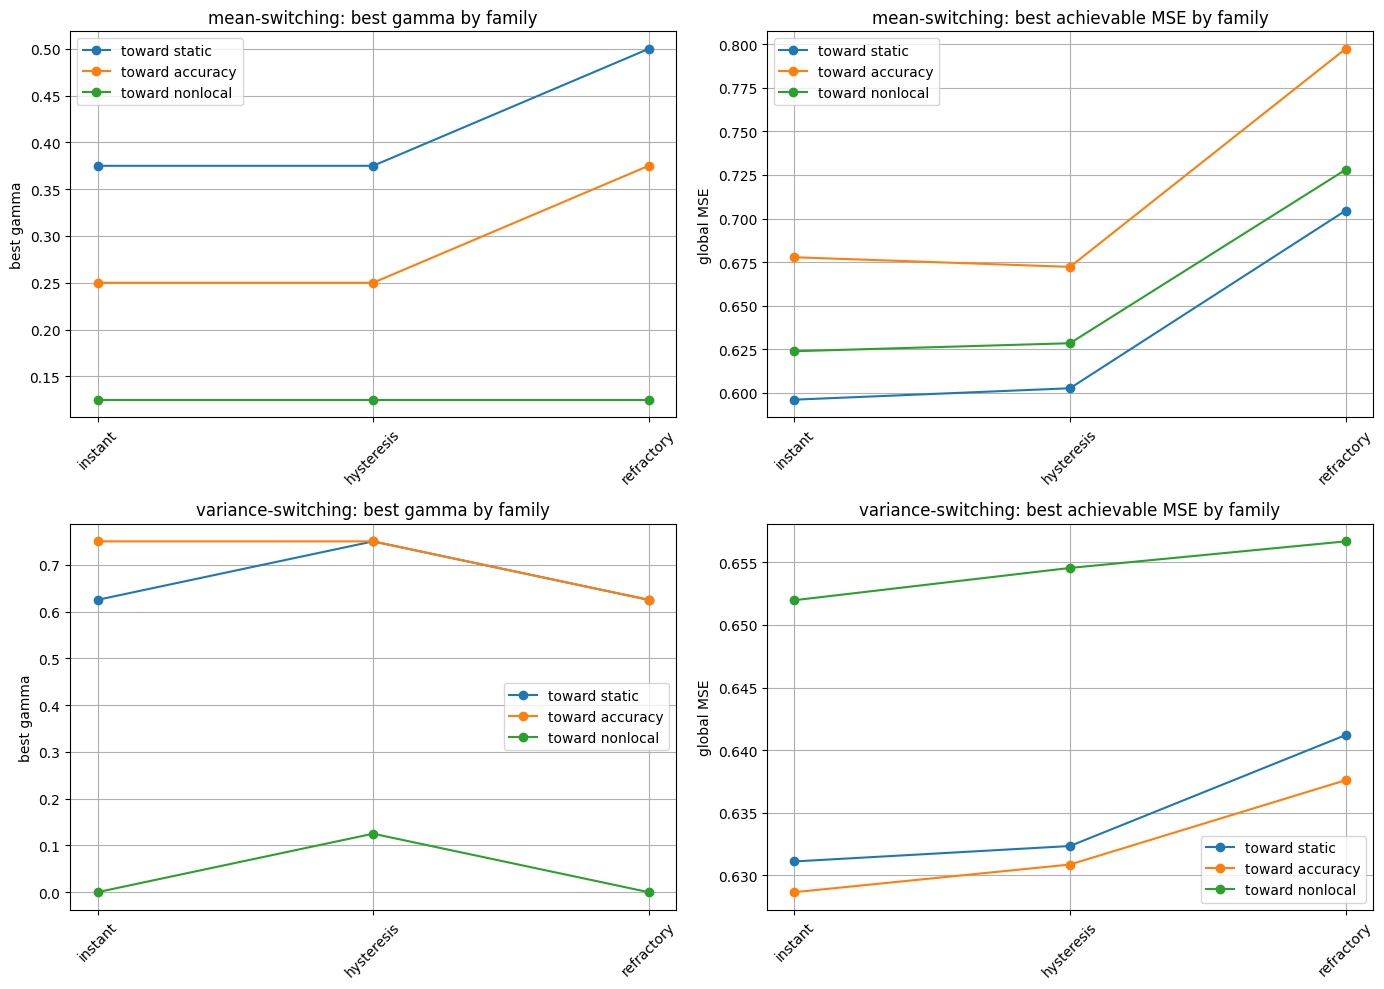

winning family by mode — mean-switching


,mode,best_family,best_gamma,best_global_mse
0,instant,toward static,0.375,0.596021
1,hysteresis,toward static,0.375,0.602572
2,refractory,toward static,0.500,0.704517


winning family by mode — variance-switching


,mode,best_family,best_gamma,best_global_mse
3,instant,toward accuracy,0.750,0.628668
4,hysteresis,toward accuracy,0.750,0.630875
5,refractory,toward accuracy,0.625,0.637604


In [180]:
# ---------- final optional plots: retuned gamma/family by switching mode ----------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, env_name in enumerate(["mean-switching", "variance-switching"]):
    df_now = mode_gamma_df[mode_gamma_df["env"] == env_name].copy()

    axes[row_idx, 0].plot(df_now["mode"], df_now["best_static_gamma"], marker="o", label="toward static")
    axes[row_idx, 0].plot(df_now["mode"], df_now["best_acc_gamma"], marker="o", label="toward accuracy")
    axes[row_idx, 0].plot(df_now["mode"], df_now["best_nonlocal_gamma"], marker="o", label="toward nonlocal")
    axes[row_idx, 0].set_title(f"{env_name}: best gamma by family")
    axes[row_idx, 0].set_ylabel("best gamma")
    axes[row_idx, 0].tick_params(axis="x", rotation=45)
    axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(df_now["mode"], df_now["best_static_mse"], marker="o", label="toward static")
    axes[row_idx, 1].plot(df_now["mode"], df_now["best_acc_mse"], marker="o", label="toward accuracy")
    axes[row_idx, 1].plot(df_now["mode"], df_now["best_nonlocal_mse"], marker="o", label="toward nonlocal")
    axes[row_idx, 1].set_title(f"{env_name}: best achievable MSE by family")
    axes[row_idx, 1].set_ylabel("global MSE")
    axes[row_idx, 1].tick_params(axis="x", rotation=45)
    axes[row_idx, 1].legend()

plt.tight_layout()
plt.show()

print("winning family by mode — mean-switching")
display(
    mode_gamma_df[mode_gamma_df["env"] == "mean-switching"][
        ["mode", "best_family", "best_gamma", "best_global_mse"]
    ]
)

print("winning family by mode — variance-switching")
display(
    mode_gamma_df[mode_gamma_df["env"] == "variance-switching"][
        ["mode", "best_family", "best_gamma", "best_global_mse"]
    ]
)